(mmm_case_study3)=
# MMM Case Study III: Multiplicative Funnel Model, Channel Synergies, and Prior Sensitivity

This notebook is the third iteration of the {ref}`mmm_case_study` and {ref}`mmm_case_study2` notebooks. The second iteration delivered a funnel-aware model of the SEM channel, calibrated the return on ad spend (ROAS) of two channels with experiments, validated the specification on four quarterly folds, and planned the next quarter's budget. Among its next steps it named a multiplicative specification, to let the data speak to channel interactions, the synergy the funnel cannot express. This iteration takes that step, and adds one diagnostic the second iteration did not have: how much of each ROAS number rests on the priors rather than on the data.

What changes is one argument of the model, `link="log"`, and one table of priors. Sales become `LogNormal`, every component of the model becomes a factor on sales, and channels interact by construction. What stays is everything else: the funnel, the two experiments, the fold design, and the planning window. Why would a marketing team want this? Three reasons: sales are strictly positive and their week-to-week noise is often assumed to scale with the level; media effects that multiply a seasonal baseline are a common assumption for consumer brands; and cross-channel synergies are a question stakeholders ask that an additive model cannot answer.

The analysis proceeds in eight steps (model specification and diagnostics sit between them):

1. ROAS Calibration Under the Log Link
2. Final Model and the Reference Model
3. Posterior Predictive Checks
4. Media Deep Dive
   - Contribution Shares
   - Lift Curves
   - Channel Synergies: funnel and interaction
   - Return on Ad Spend (ROAS)
5. Time-Slice Cross-Validation
6. Prior Sensitivity of the ROAS
7. Budget Optimization
8. Conclusion and Next Steps

The order differs from the second iteration: the results come first, and the two robustness checks follow them, over the training window (cross-validation) and over the priors (power-scaling sensitivity). Every section closes with a short comparison against the second iteration, computed on a refit of its specification rather than quoted. We keep the prose short and the funnel in the background, as the second iteration covers it in depth.

```{note}
For the link function and the counterfactual decomposition it implies see {ref}`mmm_multiplicative`, and for the power-scaling sensitivity diagnostic see {ref}`mmm_prior_sensitivity`. As in the second iteration, every interval we report is a $94\%$ highest density interval (HDI), set once through the ArviZ defaults below; the one exception is the experiment input of the calibration section, which is a reported $95\%$ range.
```

## The Model

The model is the second iteration's funnel model with a log link on the sales likelihood:

$$\text{sales}_t \sim \text{LogNormal}(\mu_t, \sigma), \qquad \mu_t = \beta_0 + \sum_{c} m_{t,c} + \gamma^\top h_t + s_t + f_t,$$

where $m_{t,c} = \text{sat}_c(\text{adstock}_c(x_{t,c}))$ is the term of channel $c$, $h_t$ holds the holiday dummies, $s_t$ is the yearly seasonality, and $f_t = \text{sat}^{lf}(\text{adstock}^{lf}(M^{*}_t))$ is the SEM path of the second iteration: the demand pool $D_t$ (ambient demand plus what `TV`, `Radio`, and `Newspaper` add to it), the mediator $M^{*}_t = D_t + \lambda \, \text{SEM spend}_t / s_{\text{spd}}$, and the SEM impressions likelihood are unchanged. On the sales scale, with $s$ the target scale,

$$\text{median}(\text{sales}_t) = s \, e^{\beta_0} \prod_c e^{m_{t,c}} \; e^{\gamma^\top h_t} \, e^{s_t} \, e^{f_t}.$$

Three consequences follow from the second line:

1. **Every term is a factor.** A channel's `saturation_beta` is a log-lift, and $e^{\beta_c} - 1$ is the lift of channel $c$ at saturation. Priors have to be re-expressed on this scale.
2. **Channels interact.** The cross derivative of sales with respect to two direct terms is positive: each channel makes every other channel more productive, in both directions, by the functional form alone. This is the interaction synergy we measure below. Pairs that share the demand pool (`TV`, `Radio`, `Newspaper`, and `sem_spend`) add the pool's concave term to it.
3. **Contributions are counterfactuals.** A channel's contribution to sales is what sales would lose without its term, $s \, (e^{\mu_t} - e^{\mu_t - m_{t,c}})$. Such counterfactuals overlap, so they do not add up to the prediction. See {ref}`mmm_multiplicative` for the details.

One convention on scales for the whole notebook. Every *level* of the log model (the response, the contribution shares, the interaction dollars, the budget objective) is on the **median** scale, $s \, e^{\mu_t}$, the scale of every original-scale variable the library registers under this link. The one exception is the **ROAS**, the quantity we set against an experiment and against the additive model: an experiment measures the expected lift, so the ROAS is on the **mean** scale, higher by the factor $e^{\sigma^2 / 2}$, which the diagnostics print (it is about $1.04$ here). Shares, rankings, and the budget split do not depend on the choice.

```{note}
The log link is experimental in the library (the constructor says so). The ROAS calibration and the cross-validation summaries support it ([#3134](https://github.com/pymc-labs/pymc-marketing/pull/3134), [#3133](https://github.com/pymc-labs/pymc-marketing/pull/3133)); the one notebook-level workaround left is the funnel data plumbing of the second iteration, tracked in [#2945](https://github.com/pymc-labs/pymc-marketing/issues/2945).
```

## Prepare Notebook

We load the libraries and set the configuration. The last two warning filters silence the two messages the model raises by design: the log link is experimental, and the funnel effect becomes a multiplicative factor under it.

In [1]:
import itertools
import logging
import warnings

import arviz as az
import arviz_plots as azp
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import pymc as pm
import pymc.dims as pmd
import seaborn as sns
import xarray as xr
from pydantic import InstanceOf
from pymc_extras.prior import Prior
from pytensor.compile.mode import Mode
from pytensor.graph.traversal import ancestors

from pymc_marketing.metrics import crps
from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.additive_effect import DataVarMuEffect, IncrementalitySpec
from pymc_marketing.mmm.budget_optimizer import BudgetOptimizer
from pymc_marketing.mmm.constraints import Constraint, build_default_sum_constraint
from pymc_marketing.mmm.data_conversion import to_mmm_dataset
from pymc_marketing.mmm.link import LinkFunction
from pymc_marketing.mmm.media_transformation import MediaTransformation
from pymc_marketing.mmm.mmm import MMM
from pymc_marketing.mmm.time_slice_cross_validation import TimeSliceCrossValidator
from pymc_marketing.paths import data_dir

warnings.filterwarnings("ignore", category=FutureWarning)
# pytensor falls back to object mode for the truncated normal sampler: correct, only slower.
warnings.filterwarnings("ignore", message="Numba will use object mode")
# pytensor formats a diagnostic message with a 0 / 0 relative error on all-zero tensors.
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide",
    module="pytensor.tensor.type",
)
# Both are explained in the model section above.
warnings.filterwarnings("ignore", message="The 'log' link is experimental")
warnings.filterwarnings("ignore", message="With link='log', MuEffect components")
# Eighty counterfactual passes would each log a "Sampling: [...]" line, and the
# power-scaling summaries log a pointer to their interpretation guide for every
# flagged cell; we read the flags from the tables instead.
logging.getLogger("pymc").setLevel(logging.WARNING)
logging.getLogger("arviz_stats.psense").setLevel(logging.ERROR)

az.style.use("arviz-darkgrid")
HDI_PROB = 0.94
az.rcParams["stats.ci_kind"] = "hdi"
az.rcParams["stats.ci_prob"] = HDI_PROB
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100

%config InlineBackend.figure_format = "retina"

In [2]:
seed: int = sum(map(ord, "mmm_case_study3"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

## Load Data

We use the data of the second iteration with the same cleaning and names: seven channels, the two SEM columns, and the holiday dummies over $209$ weeks. The one requirement the log link adds is that sales are strictly positive, which we check. See {ref}`mmm_case_study2` for the exploratory analysis.

In [3]:
data_path = data_dir / "case_study_data.csv"
raw_df = pd.read_csv(data_path)

date_column = "date"
target_column = "sales"

channel_mapping = {
    "mdsp_dm": "Direct Mail",
    "mdsp_inst": "Insert",
    "mdsp_nsp": "Newspaper",
    "mdsp_audtr": "Radio",
    "mdsp_vidtr": "TV",
    "mdsp_so": "Social Media",
    "mdsp_on": "Online Display",
}
channel_columns = sorted(channel_mapping.values())
funnel_mapping = {"mdsp_sem": "sem_spend", "mdip_sem": "sem_impressions"}
funnel_vars = list(funnel_mapping.values())
upper_channels = ["Newspaper", "Radio", "TV"]
control_columns = [col for col in raw_df.columns if "hldy_" in col]

data_df = raw_df[
    ["wk_strt_dt", target_column, *channel_mapping, *funnel_mapping, *control_columns]
].rename(columns=channel_mapping | funnel_mapping | {"wk_strt_dt": date_column})
data_df[date_column] = pd.to_datetime(data_df[date_column])

X = data_df.drop(columns=target_column)
y = data_df[target_column]
dates = X[date_column]

print(
    f"{len(X)} weeks, sales from {y.min() / 1e6:.0f}M to {y.max() / 1e6:.0f}M, "
    f"all positive: {bool((y > 0).all())}, peak over mean sales: {y.max() / y.mean():.2f}"
)

209 weeks, sales from 45M to 352M, all positive: True, peak over mean sales: 3.25


## Model Specification

The direct part of the model is the second iteration's: geometric adstock, logistic saturation, holiday controls, yearly seasonality, and spend-share priors on the saturation betas. What changes is the scale the priors live on. Under the identity link a prior is a statement about *scaled sales* (sales divided by the peak week); under the log link it is a statement about *log sales*, and every term is a factor. The table maps each prior across:

| prior | second iteration (scaled sales) | this iteration (log sales) | reading on the sales scale |
|---|---|---|---|
| `intercept` | `Normal(0.2, 0.05)` | `Normal(log 0.2, 0.25)` | baseline between $12\%$ and $33\%$ of peak sales |
| `saturation_beta` | `HalfNormal(share)` | `HalfNormal(share * y.max() / y.mean())` | a log-lift at saturation; the factor keeps the dollar scale |
| `gamma_control` | `Normal(0, 1)` | `Normal(0, 0.5)` | a holiday multiplies sales by $0.37$ to $2.7$ at two sigma |
| `gamma_fourier` | `Laplace(0, 1)` | `Laplace(0, 0.2)` | each Fourier coefficient a log-factor with scale $0.2$ |
| `likelihood` | `TruncatedNormal(sigma=HalfNormal(1))` | `LogNormal(sigma=HalfNormal(0.5))` | noise proportional to the level |

The `saturation_beta` row deserves a word, because it is the one row where the same number looks like the same prior. Under the identity link `beta_c` is a share of *peak* sales (the target is scaled by its maximum), while under the log link it is a log-lift on *each week's* sales, and an average week is $3.25$ times smaller than the peak (`y.max() / y.mean()`, printed above). Keeping `HalfNormal(share)` would make the log prior about three times tighter in dollars. The factor restores the second iteration's dollar scale; the ROAS section fits the narrow version too and shows what the factor does, and the prior sensitivity section measures what the prior still does. The `comparable_priors` switch below exists for that one comparison.

In [4]:
def make_model_config(
    X: pd.DataFrame, y: pd.Series, link: str, comparable_priors: bool = True
) -> dict:
    """Prior configuration for a link, with spend-share widths computed from X."""
    share = X[channel_columns].sum() / X[channel_columns].sum().sum()
    if link == "identity":  # the second iteration, unchanged
        return {
            "intercept": Prior("Normal", mu=0.2, sigma=0.05),
            "saturation_beta": Prior(
                "HalfNormal",
                sigma=xr.DataArray(share.to_numpy(), dims="channel"),
                dims="channel",
            ),
            "gamma_control": Prior("Normal", mu=0, sigma=1, dims="control"),
            "gamma_fourier": Prior("Laplace", mu=0, b=1, dims="fourier_mode"),
            "likelihood": Prior(
                "TruncatedNormal", lower=0, sigma=Prior("HalfNormal", sigma=1)
            ),
        }
    # beta is a log-lift on each week's sales: rescale the share by peak over mean sales
    beta_scale = float(y.max() / y.mean()) if comparable_priors else 1.0
    beta_sigma = share.to_numpy() * beta_scale
    return {
        "intercept": Prior("Normal", mu=np.log(0.2), sigma=0.25),
        "saturation_beta": Prior(
            "HalfNormal",
            sigma=xr.DataArray(beta_sigma, dims="channel"),
            dims="channel",
        ),
        "gamma_control": Prior("Normal", mu=0, sigma=0.5, dims="control"),
        "gamma_fourier": Prior("Laplace", mu=0, b=0.2, dims="fourier_mode"),
        "likelihood": Prior(
            "LogNormal", sigma=Prior("HalfNormal", sigma=0.5), dims="date"
        ),
    }

### The Funnel Effect and the Data Plumbing

The funnel is the second iteration's `FunnelEffect`, unchanged: it adds the SEM path $f_t$ to the linear predictor, which the log link turns into the factor $e^{f_t}$ on sales, and it declares its own impressions likelihood, which is linear in the mediator and does not see the link. The `FunnelMMM` subclass carries the funnel columns through every prediction call (see the Data Plumbing section of {ref}`mmm_case_study2` and [#2945](https://github.com/pymc-labs/pymc-marketing/issues/2945)). The two cells below are copied verbatim and collapsed.

In [5]:
upper_dim = "channel_upper"


class FunnelEffect(DataVarMuEffect):
    """Upper funnel spend -> latent demand -> SEM-harvested mediator -> sales.

    The measurement coefficient on the mediator is fixed at one (times the
    impressions scale). This anchors the mediator scale and removes the
    likelihood-invariant ridge a free coefficient would create.
    """

    upper_channels: list[str]
    sem_scale: float
    impressions_scale: float
    upper_transform: InstanceOf[MediaTransformation]
    demand_transform: InstanceOf[MediaTransformation]

    model_config = {"arbitrary_types_allowed": True}

    def to_dict(self) -> dict:
        """Serialize the effect."""
        return {
            "data_vars": self.data_vars,
            "prefix": self.prefix,
            "upper_channels": self.upper_channels,
            "sem_scale": self.sem_scale,
            "impressions_scale": self.impressions_scale,
            "upper_transform": self.upper_transform.to_dict(),
            "demand_transform": self.demand_transform.to_dict(),
        }

    def incrementality_spec(self) -> IncrementalitySpec:
        """Opt in to incrementality, declaring the second adstock's reach."""
        return IncrementalitySpec(
            additional_carryover_lags=self.demand_transform.adstock.l_max
        )

    def create_data(self, mmm) -> None:
        """Register the funnel data variables and the upper channel coordinate."""
        mmm.model.add_coord(upper_dim, self.upper_channels)
        super().create_data(mmm)

    def create_effect(self, mmm):
        """Build the mediator equation and the term it adds to the sales mean."""
        model = mmm.model
        channel_index = [mmm.channel_columns.index(c) for c in self.upper_channels]
        upper = mmm.channel_data_scaled.isel(channel=channel_index).rename(
            {"channel": upper_dim}
        )
        upper_on_demand = self.upper_transform(upper, dim="date").sum(dim=upper_dim)
        baseline = pmd.HalfNormal(f"{self.prefix}_baseline", sigma=1.0)
        demand = pmd.Deterministic(f"{self.prefix}_demand", baseline + upper_on_demand)
        lam = pmd.HalfNormal(f"{self.prefix}_lambda", sigma=0.5)
        mediator = pmd.Deterministic(
            f"{self.prefix}_mediator",
            demand + lam * model["sem_spend"] / self.sem_scale,
        )
        pmd.TruncatedNormal(
            f"{self.prefix}_sem_impressions_likelihood",
            mu=self.impressions_scale * mediator,
            sigma=pmd.HalfNormal(
                f"{self.prefix}_sigma_s", sigma=0.2 * self.impressions_scale
            ),
            lower=0.0,
            observed=model["sem_impressions"],
        )
        return pmd.Deterministic(
            f"{self.prefix}_effect_contribution",
            self.demand_transform(mediator, dim="date"),
        )


l_max = 6  # direct path adstock, as in the first two iterations
l_max_lf = 6  # mediator adstock, a modeling declaration (see the second iteration)


def make_funnel_effect(sem_scale: float, impressions_scale: float) -> FunnelEffect:
    """Build the funnel effect with its two media transformations."""
    return FunnelEffect(
        data_vars=funnel_vars,
        prefix="funnel",
        upper_channels=upper_channels,
        sem_scale=sem_scale,
        impressions_scale=impressions_scale,
        upper_transform=MediaTransformation(
            adstock=GeometricAdstock(
                l_max=l_max,
                prefix="adstock_uf",
                priors={"alpha": Prior("Beta", alpha=2, beta=3, dims=upper_dim)},
            ),
            saturation=LogisticSaturation(
                prefix="sat_uf",
                priors={
                    "lam": Prior("Gamma", mu=2.0, sigma=1.0, dims=upper_dim),
                    "beta": Prior("HalfNormal", sigma=1.0, dims=upper_dim),
                },
            ),
            adstock_first=True,
            dims=(upper_dim,),
        ),
        demand_transform=MediaTransformation(
            adstock=GeometricAdstock(
                l_max=l_max_lf,
                prefix="adstock_lf",
                priors={"alpha": Prior("Beta", alpha=2, beta=3)},
            ),
            saturation=LogisticSaturation(
                prefix="sat_lf",
                priors={
                    "lam": Prior("Gamma", mu=1.5, sigma=0.5),
                    "beta": Prior("HalfNormal", sigma=1.0),
                },
            ),
            adstock_first=True,
            dims=(),
        ),
    )

In [6]:
class FunnelMMM(MMM):
    """MMM that carries the funnel data variables through DataFrame conversion."""

    def _posterior_predictive_data_transformation(
        self, X, y=None, include_last_observations: bool = False
    ):
        if isinstance(X, pd.DataFrame):
            missing = [var for var in funnel_vars if var not in X.columns]
            if missing:
                raise ValueError(
                    f"funnel columns missing from prediction frame: {missing}"
                )
            X = to_mmm_dataset(
                X,
                y,
                date_column=self.date_column,
                dims=self.dims,
                channel_columns=self.channel_columns,
                control_columns=self.control_columns,
                target_column=self.target_column,
                extra_vars=funnel_vars,
            )
            y = None
        return super()._posterior_predictive_data_transformation(
            X, y=y, include_last_observations=include_last_observations
        )


def make_funnel_dataset(X: pd.DataFrame, y: pd.Series | None = None) -> xr.Dataset:
    """Convert the flat frame to the Dataset the funnel model builds from."""
    return to_mmm_dataset(
        X,
        y,
        date_column=date_column,
        channel_columns=channel_columns,
        control_columns=[col for col in X.columns if "hldy_" in col],
        target_column=target_column,
        extra_vars=funnel_vars,
    )

The model factory takes the link as an argument, so the same function builds this iteration's model and the second iteration's reference.

In [7]:
def make_mmm(
    X: pd.DataFrame, y: pd.Series, link: str = "log", comparable_priors: bool = True
) -> FunnelMMM:
    """Build the funnel MMM for a link, with scales and prior widths computed from X and y."""
    mmm = FunnelMMM(
        model_config=make_model_config(
            X, y, link=link, comparable_priors=comparable_priors
        ),
        target_column=target_column,
        date_column=date_column,
        adstock=GeometricAdstock(l_max=l_max),
        saturation=LogisticSaturation(),
        channel_columns=channel_columns,
        control_columns=[col for col in X.columns if "hldy_" in col],
        yearly_seasonality=5,
        link=link,
    )
    mmm.add_mu_effect(
        make_funnel_effect(
            sem_scale=float(X["sem_spend"].max()),
            impressions_scale=float(X["sem_impressions"].max()),
        )
    )
    return mmm

## ROAS Calibration Under the Log Link

We keep the two experiments of the second iteration: a conversion lift study on `Online Display` (ROAS between $20$ and $36$) and a regional holdout on `Direct Mail` (ROAS between $2$ and $8$), each a reported $95\%$ range converted to the value and standard deviation the calibration expects.

In [8]:
def roas_range_to_calibration(lower: float, upper: float) -> dict[str, float]:
    """Convert a reported 95% ROAS interval to a Normal(value, sigma) target."""
    return {"roas": (lower + upper) / 2, "sigma": (upper - lower) / (2 * 1.96)}


roas_experiments = {
    "Online Display": roas_range_to_calibration(20.0, 36.0),
    "Direct Mail": roas_range_to_calibration(2.0, 8.0),
}
calibrated_channels = list(roas_experiments)

roas_calibration_df = pd.DataFrame(
    [{"channel": channel, **target} for channel, target in roas_experiments.items()]
)
roas_calibration_df

,channel,roas,sigma
0,Online Display,28.0,4.081633
1,Direct Mail,5.0,1.530612


{meth}`~pymc_marketing.mmm.mmm.MMM.add_cost_per_target_calibration` constrains, for each calibrated channel, the level change in sales from removing the channel's term, divided by its spend. Under the identity link that change is $s \, m_{t,c}$, the second iteration's `channel_contribution_original_scale`. Under the log link that variable is the factor $s \, e^{m_{t,c}}$, not a level change, so the method constrains the per-channel spend counterfactual on the response scale instead, the same quantity the incrementality module and the counterfactual decomposition use, and registers it as `channel_incremental_contribution`:

$$\Delta_{t,c} = s \left( e^{\mu_t} - e^{\mu_t - m_{t,c}} \right), \qquad \text{ROAS}_c = e^{\sigma^2 / 2} \, \frac{\sum_t \Delta_{t,c}}{\sum_t x_{t,c}}.$$

The factor is the scale convention: $\Delta$ is on the median scale, and the calibration's default `central_tendency="mean"` multiplies it by $e^{\sigma^2 / 2}$ inside the ratio, because an experiment measures the expected lift. Without it the calibration would pin the median-scale ratio to a number measured on the mean scale, and the model's expected lift would sit $e^{\sigma^2 / 2}$ above the experiment (the diagnostics print the factor). Three properties an experiment must share with the calibrated ratio:

- **Full window.** The ratio runs over all $209$ weeks, as in the second iteration. Under the log link it is level-weighted (a dollar in a strong week moves more sales), so a test run in a peak quarter measures a larger number than the full-window ratio.
- **One channel at a time.** Per-channel increments do not add up to the total media contribution, which removes every channel at once, so per-channel figures split from a total-media number must not be calibrated.
- **Direct path.** The ratio is the channel's direct path. For a direct-only channel removing the term is exactly zeroing the spend (the adstock and the saturation of zero are zero) and nothing of its effect travels through the funnel, so for `Online Display` and `Direct Mail` the calibrated ratio is exactly the ROAS the incrementality module reports, draw by draw. An upper funnel experiment measures the direct plus the mediated effect, and its target would have to be the whole-model spend counterfactual; as in the second iteration, we calibrate direct-only channels.

After the fit we check both the draw-by-draw equality and the factor between the two scales. See the Practical Guidance of {ref}`mmm_roas_calibration` for the same points on a simpler model.

One builder serves both links, since the method dispatches on the link itself. Under the identity link it also registers `channel_contribution_original_scale` when it is missing, so the second iteration's explicit call to `add_original_scale_contribution_variable` before the calibration is no longer needed.

In [9]:
def build_calibrated(mmm: FunnelMMM, X: pd.DataFrame, y: pd.Series) -> FunnelMMM:
    """Build from the funnel Dataset and add the ROAS calibration, for either link."""
    mmm.build_model(X=make_funnel_dataset(X, y))
    mmm.add_cost_per_target_calibration(
        data=X,
        calibration_data=roas_calibration_df,
        name_prefix="roas_calibration",
        target_column="roas",
        target_per_cost=True,
    )
    return mmm

## Final Model and the Reference Model

We build the model on all $209$ weeks. As in the second iteration it fits three data sources at once: the sales likelihood, the SEM impressions likelihood inside the funnel effect, and the two experiment observations. The graph is the second iteration's with the sales likelihood swapped, so we print the three observed variables instead of drawing it.

In [10]:
mmm = build_calibrated(make_mmm(X, y, link="log"), X, y)

print("observed variables:", [rv.name for rv in mmm.model.observed_RVs])

observed variables: ['funnel_sem_impressions_likelihood', 'y', 'roas_calibration']


### Prior Predictive Check

Before fitting, we confirm the priors put sales in a plausible range. We draw the full prior predictive, noise included, as the second iteration did.

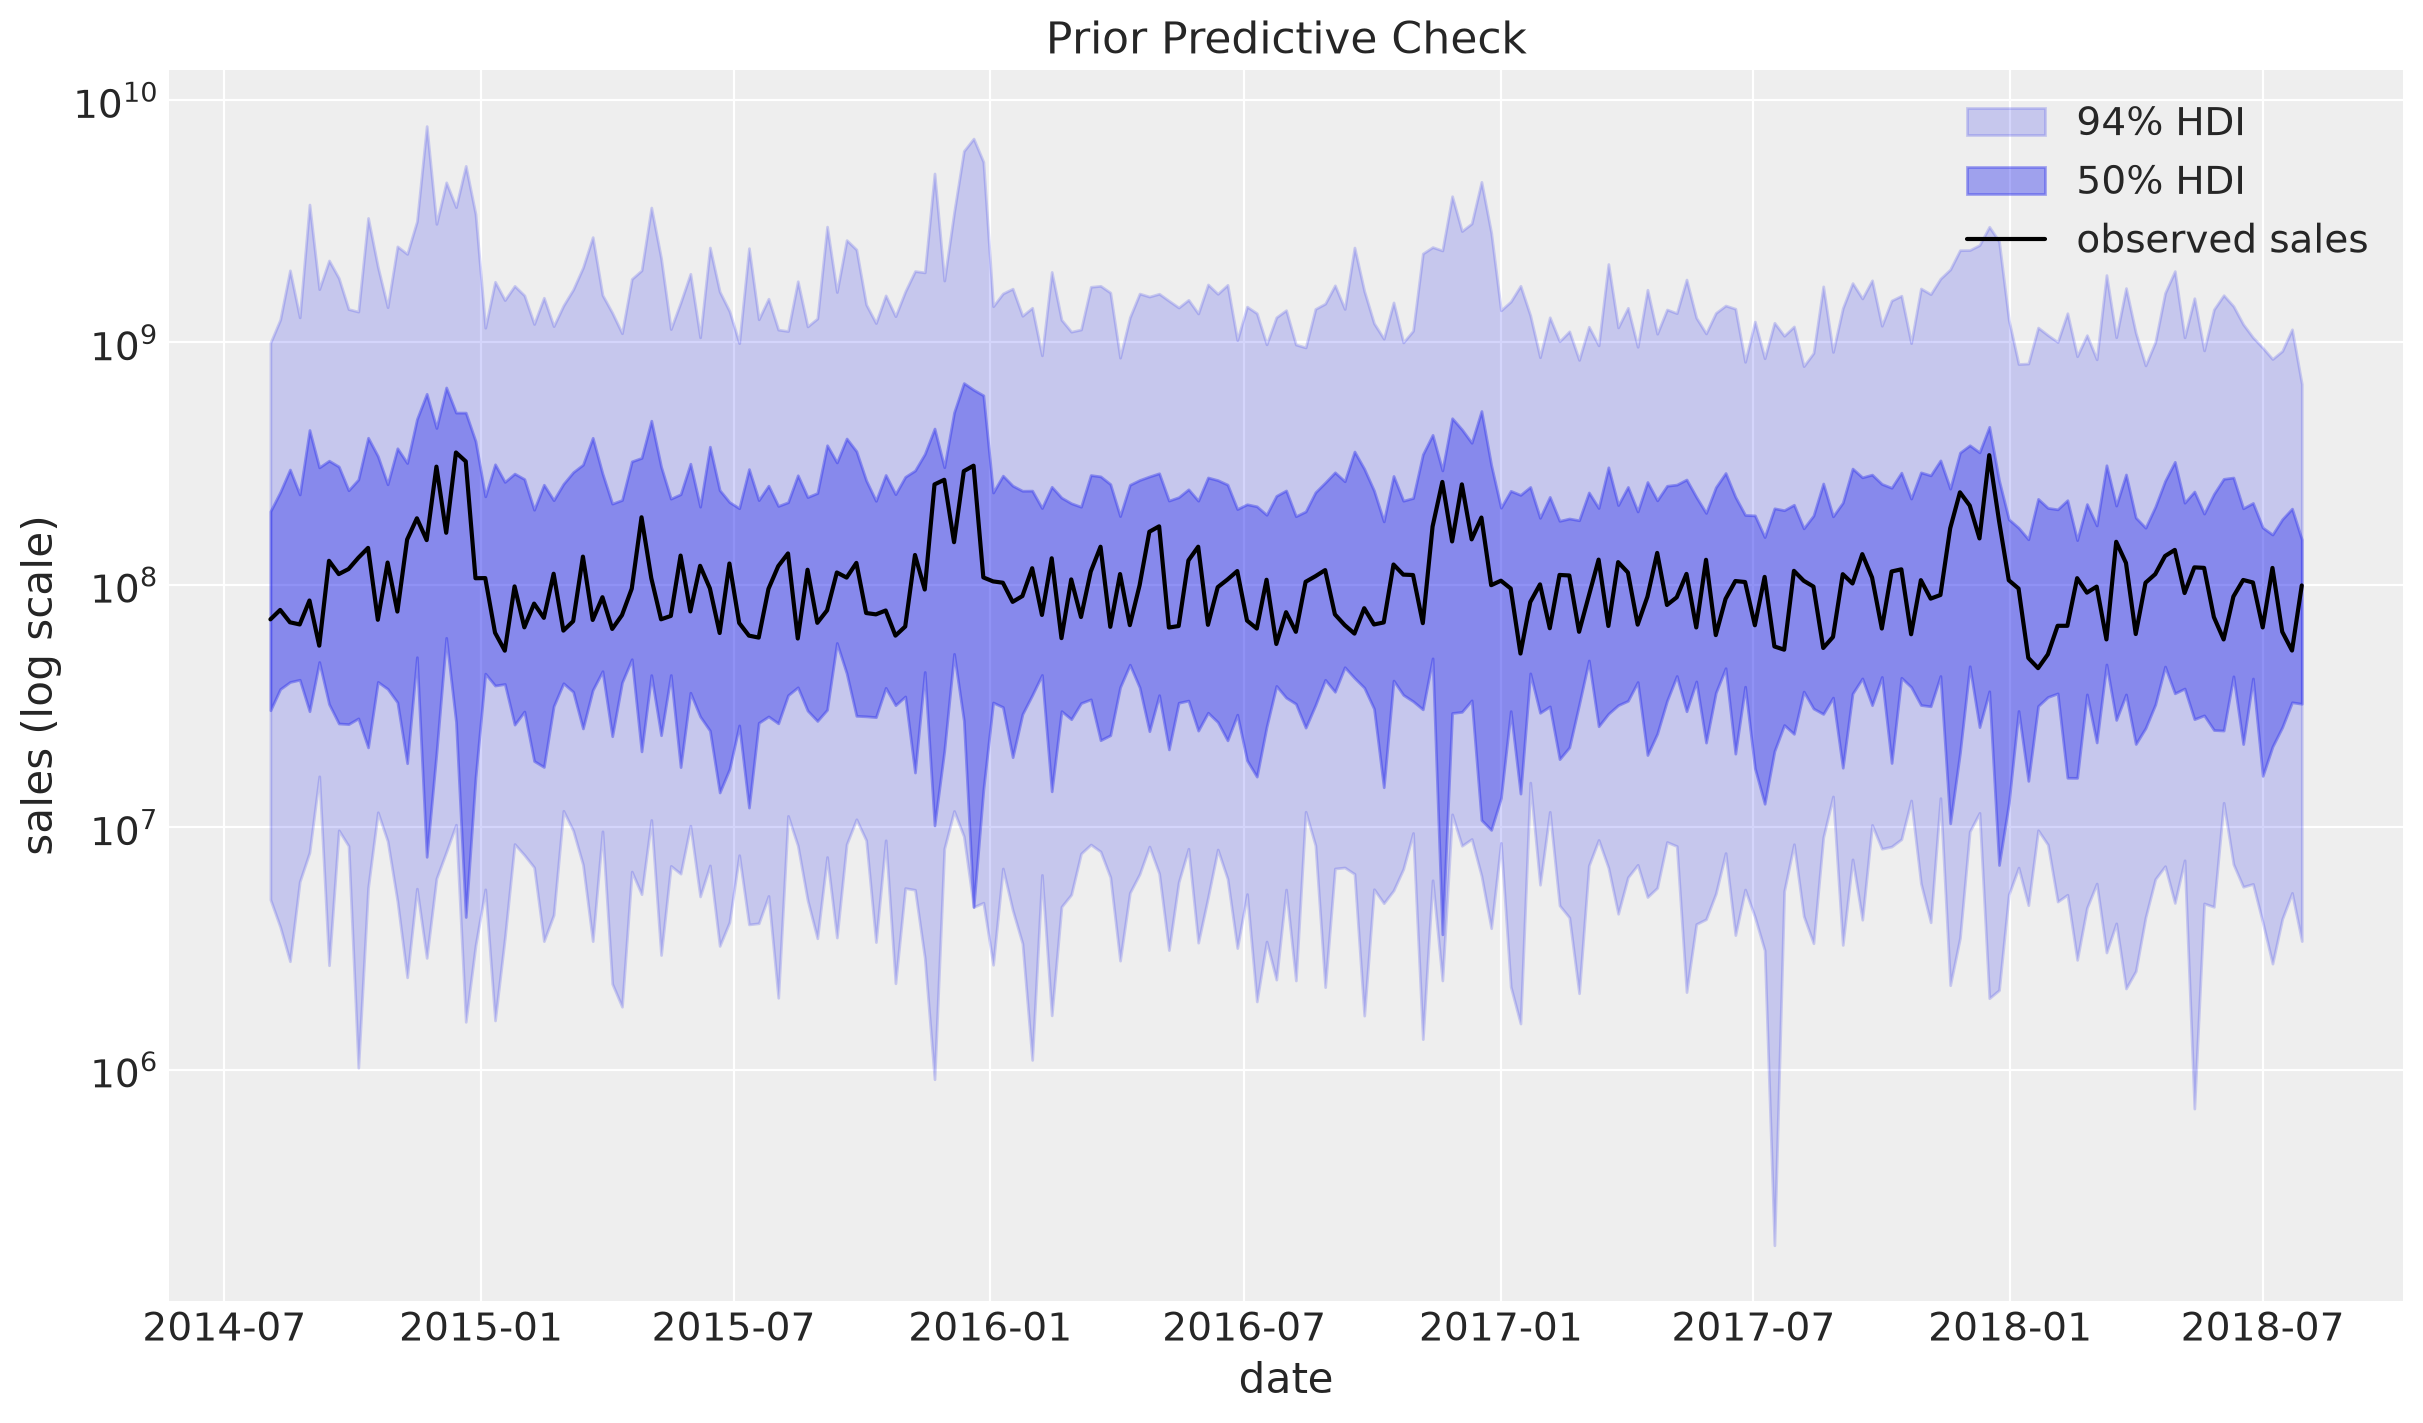

In [11]:
mmm.sample_prior_predictive(X, y, samples=2_000, random_seed=seed)
target_scale = float(mmm.idata["constant_data"]["target_scale"])

fig, ax = plt.subplots()
prior_y = mmm.idata["prior_predictive"]["y"] * target_scale
for prob, alpha in [(HDI_PROB, 0.2), (0.5, 0.4)]:
    hdi = az.hdi(prior_y, prob=prob)
    ax.fill_between(
        dates,
        hdi.sel(ci_bound="lower"),
        hdi.sel(ci_bound="upper"),
        color="C0",
        alpha=alpha,
        label=f"{prob:.0%} HDI",
    )
ax.plot(dates, y, color="black", label="observed sales")
ax.set_yscale("log")
ax.legend(loc="upper right")
ax.set(title="Prior Predictive Check", xlabel="date", ylabel="sales (log scale)");

The band spans more than an order of magnitude on each side of the observed series, which sits well inside it. The priors are weakly informative, as we want.

### Model Fitting

We fit with the second iteration's sampler settings.

In [12]:
mmm.fit(
    X=X,
    y=y,
    target_accept=0.95,
    chains=4,
    cores=4,
    draws=2_000,
    tune=2_000,
    nuts_sampler="nutpie",
    random_seed=rng,
)

mmm.sample_posterior_predictive(X, random_seed=rng)
mmm.plot_suite = "new"

Output()

Output()

Output()

### The Reference Model

Every comparison with the second iteration below is computed, not quoted. We refit its exact specification (the identity link, its priors, its calibration) on the same data with the same sampler settings, so that the two posteriors differ by the link and by the prior table it requires. From here on the two models are labelled `identity` and `log`.

In [13]:
mmm_ii = build_calibrated(make_mmm(X, y, link="identity"), X, y)
mmm_ii.fit(
    X=X,
    y=y,
    target_accept=0.95,
    chains=4,
    cores=4,
    draws=2_000,
    tune=2_000,
    nuts_sampler="nutpie",
    random_seed=rng,
)
mmm_ii.sample_posterior_predictive(X, random_seed=rng)
mmm_ii.plot_suite = "new"

models = {"identity": mmm_ii, "log": mmm}

diagnostic_var_names = [
    "intercept_contribution",
    "y_sigma",
    "saturation_beta",
    "saturation_lam",
    "adstock_alpha",
    "gamma_control",
    "gamma_fourier",
    "funnel_baseline",
    "funnel_lambda",
    "funnel_sigma_s",
    "adstock_uf_alpha",
    "sat_uf_lam",
    "sat_uf_beta",
    "adstock_lf_alpha",
    "sat_lf_lam",
    "sat_lf_beta",
]


def max_r_hat(model: FunnelMMM) -> float:
    """Largest unrounded r_hat over the model's free parameters."""
    r_hat = az.rhat(model.idata, var_names=diagnostic_var_names)
    return max(float(values.max()) for values in r_hat.data_vars.values())


for name, model in models.items():
    n_divergences = int(model.idata["sample_stats"]["diverging"].sum().item())
    print(f"{name}: {n_divergences} divergences, max r_hat {max_r_hat(model):.4f}")
    if n_divergences != 0:
        warnings.warn(f"{name}: {n_divergences} divergences", stacklevel=1)

Output()

Output()

Output()

identity: 0 divergences, max r_hat 1.0038
log: 0 divergences, max r_hat 1.0065


## Model Diagnostics

We hold the model to the second iteration's bar: zero divergences, all $\hat{R}$ below $1.01$, and clean traces. {func}`arviz.diagnose` runs the standard checks in one call.

In [14]:
sampler_ok = not az.diagnose(mmm.idata, var_names=diagnostic_var_names)
print(f"sampler checks passed: {sampler_ok}")

Divergences
No divergent transitions found.

E-BFMI
E-BFMI satisfactory for all chains.

ESS
Effective sample size satisfactory for all parameters.

R-hat
R-hat values satisfactory for all parameters.

Processing complete, no problems detected.
sampler checks passed: True


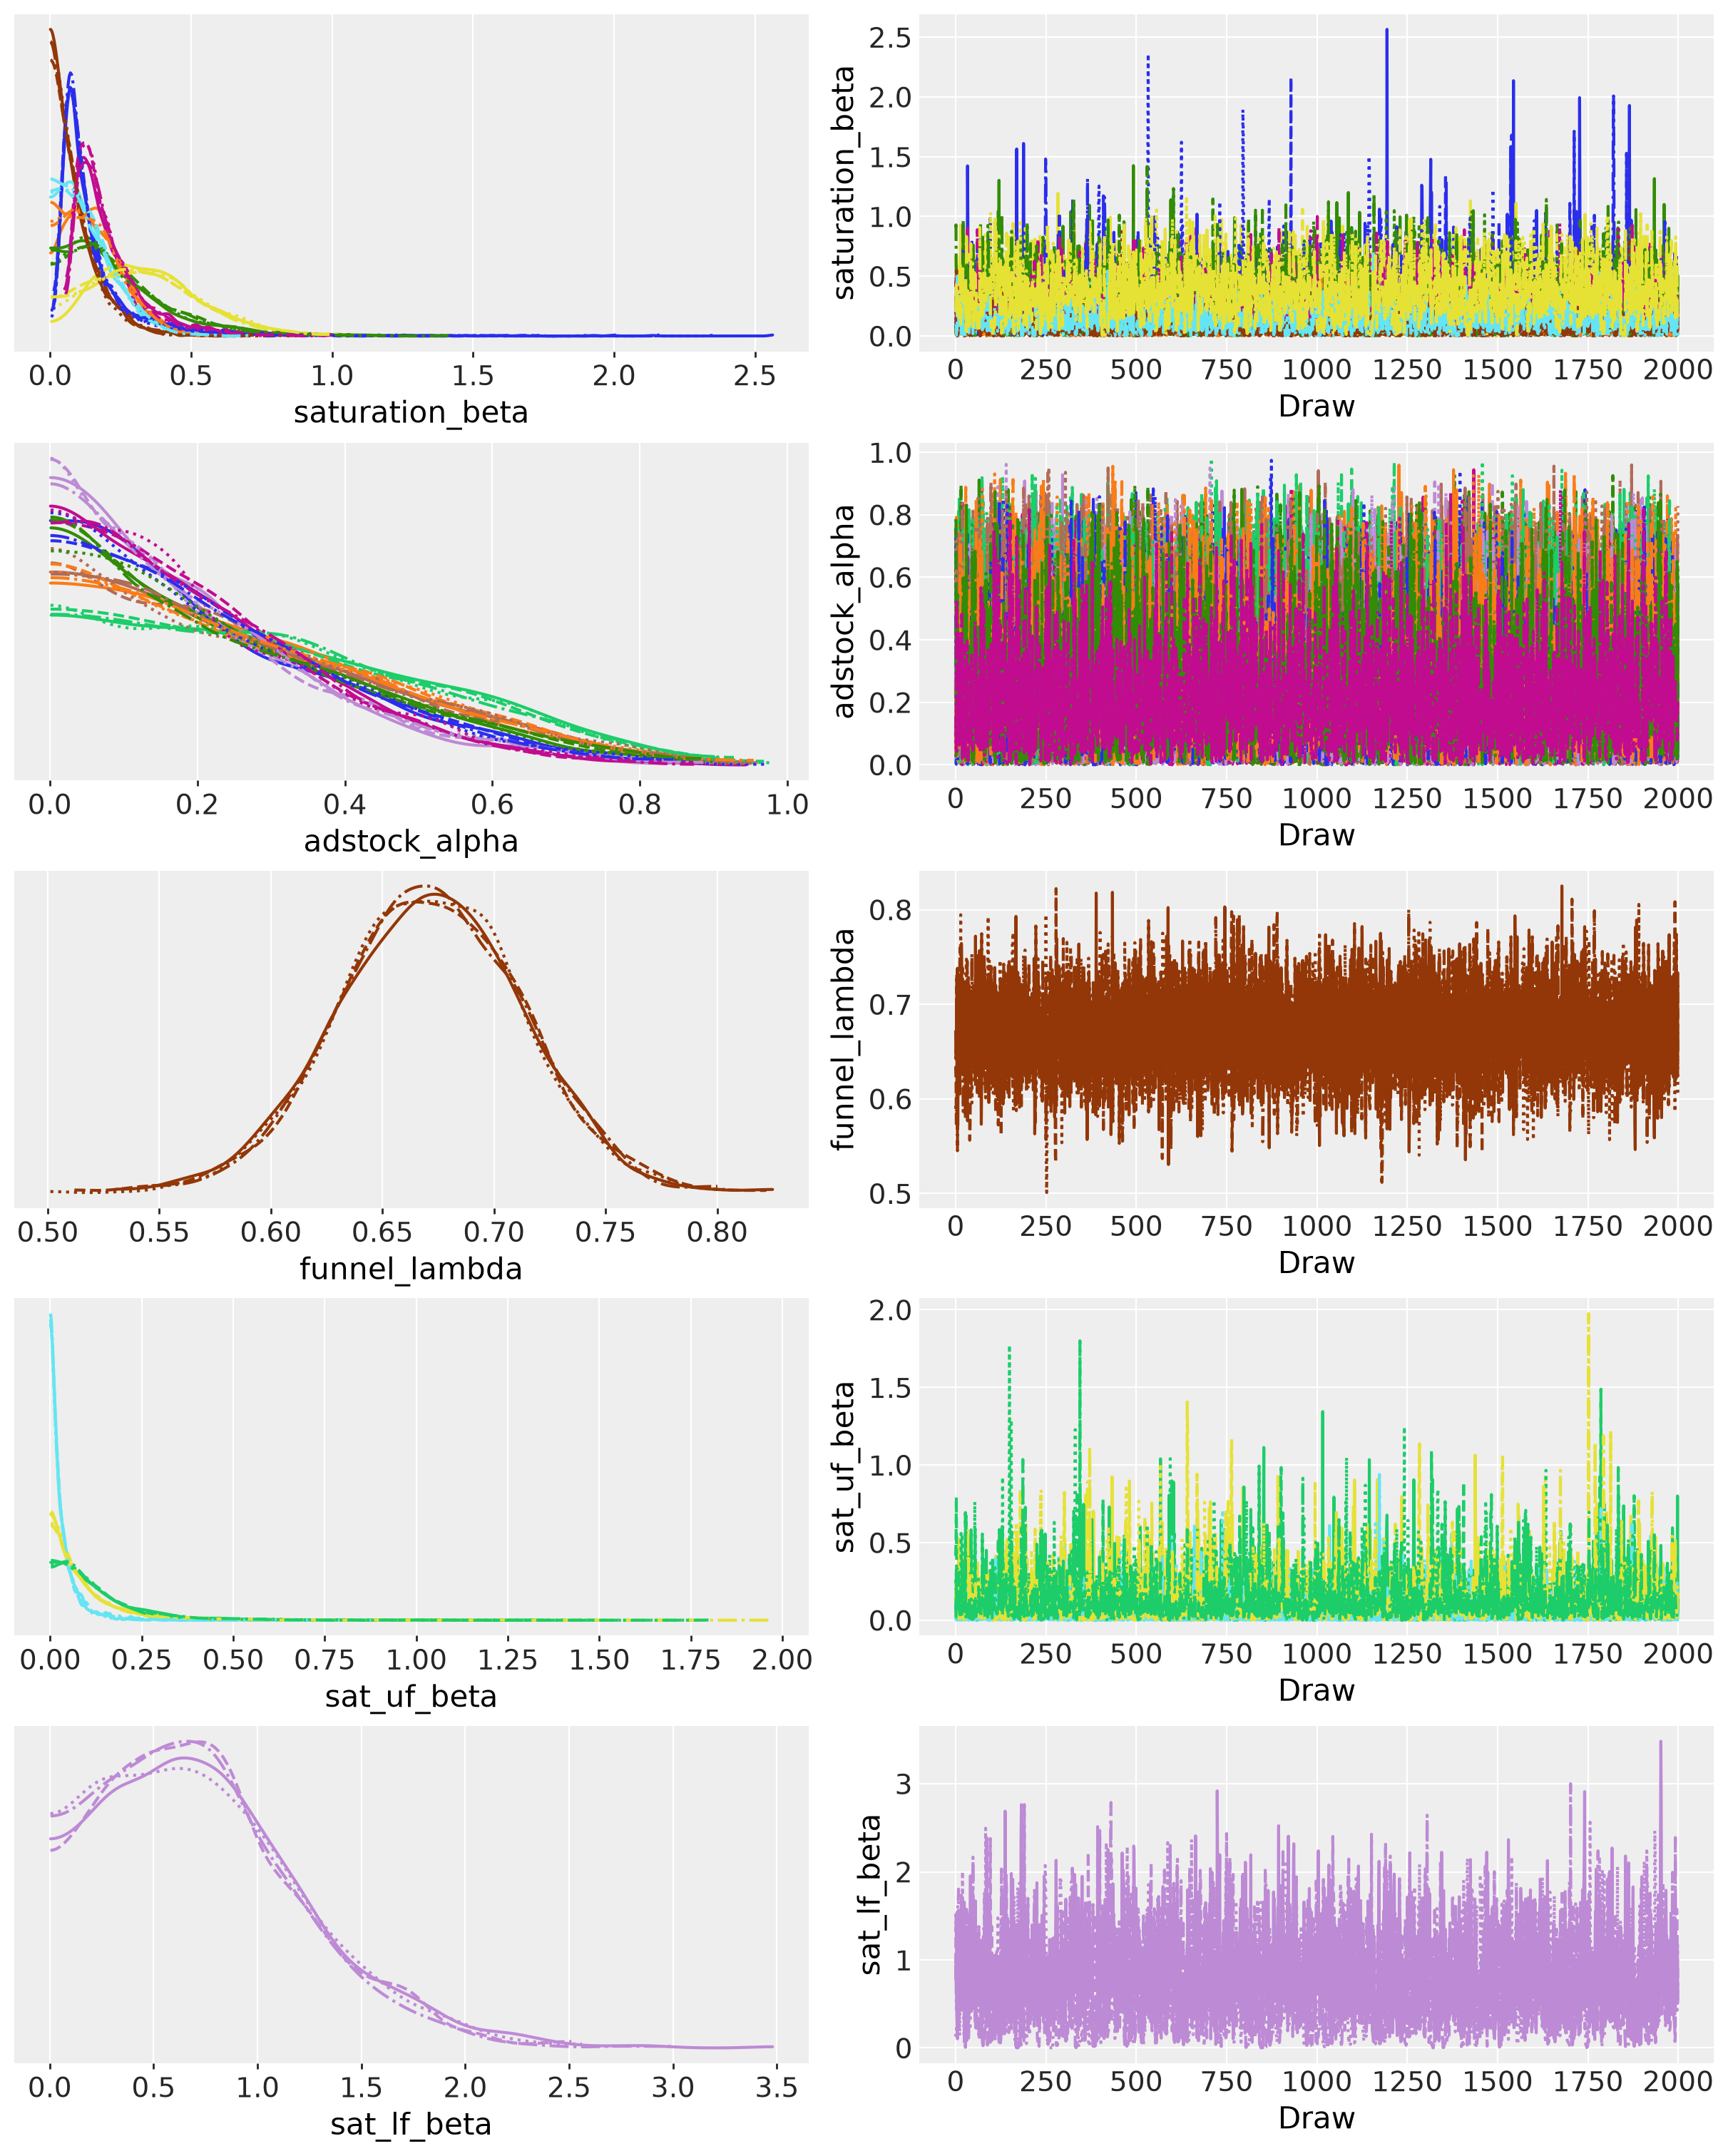

In [15]:
default_max_subplots = az.rcParams["plot.max_subplots"]
az.rcParams["plot.max_subplots"] = 100
azp.plot_trace_dist(
    mmm.fit_result,
    var_names=[
        "saturation_beta",
        "adstock_alpha",
        "funnel_lambda",
        "sat_uf_beta",
        "sat_lf_beta",
    ],
    figure_kwargs={"figsize": (12, 15)},
)
az.rcParams["plot.max_subplots"] = default_max_subplots

The traces mix well for the media and the funnel blocks. The funnel parameters and the noise scale deserve a closer look, because their meaning changed with the link; the table shows them for both models, so the comparison is computed, not quoted.

In [16]:
posterior = mmm.idata["posterior"]
mean_over_median = float(np.exp(posterior["y_sigma"] ** 2 / 2).mean())
print(f"mean over median factor exp(sigma^2 / 2): {mean_over_median:.3f}")

for name, model in models.items():
    draws = model.idata["posterior"]
    print(
        f"{name}: posterior correlation of the intercept with funnel_baseline "
        f"{float(xr.corr(draws['intercept_contribution'], draws['funnel_baseline'])):+.2f}, "
        f"with sat_lf_beta {float(xr.corr(draws['intercept_contribution'], draws['sat_lf_beta'])):+.2f}"
    )

pd.concat(
    {
        name: az.summary(
            model.idata,
            var_names=["funnel_lambda", "sat_lf_beta", "sat_lf_lam", "y_sigma"],
            kind="stats",
        )
        for name, model in models.items()
    },
    names=["model"],
)

mean over median factor exp(sigma^2 / 2): 1.042
identity: posterior correlation of the intercept with funnel_baseline -0.03, with sat_lf_beta -0.62
log: posterior correlation of the intercept with funnel_baseline -0.04, with sat_lf_beta -0.68


mean      sd hdi94_lb hdi94_ub
model                                                 
identity funnel_lambda  0.67   0.042     0.59     0.75
         sat_lf_beta    0.27     0.2    0.021     0.73
         sat_lf_lam      1.4    0.47     0.63      2.4
         y_sigma         0.1  0.0063     0.09     0.11
log      funnel_lambda  0.67   0.041     0.59     0.75
         sat_lf_beta    0.74    0.48    0.054      1.8
         sat_lf_lam      1.5    0.48      0.7      2.5
         y_sigma        0.29   0.015     0.26     0.32

How to read these rows?

- `funnel_lambda` is the same in both models (about $0.67$, with the same tight interval), because the impressions likelihood identifies it and does not see the link.
- `sat_lf_beta` is now a log-lift, where the identity row is a share of peak sales: the SEM path multiplies sales by up to $e^{\beta}$ at saturation. The pool sits low on the curve, so the realized factor is far smaller, and we read it in the shares below. `sat_lf_lam`, the curvature, is comparable across the rows and nearly the same.
- `y_sigma` is the noise scale on the log scale, about $0.29$, where the identity row is a share of peak sales: a one-sigma week is a factor $e^{\pm 0.29}$ away from the median, about a third up or a quarter down. It sets the width of every predictive band and the mean-over-median factor printed above, the factor the ROAS calibration applies.
- `funnel_baseline` no longer rides the intercept: the second iteration resolved that ridge with the tight intercept prior, and the printed correlation is near zero under both links. The correlation that remains is between the intercept and `sat_lf_beta`, the amplitude of the SEM path, and it is nearly the same under both links. A near-constant SEM path and the intercept are two shifts of one sum under the identity link and two factors on every week under the log link. The intercept prior keeps it sampleable: zero divergences and a satisfactory effective sample size.

**Versus the second iteration**: same sampler bar met, same funnel strength, and the same residual ridge.

## Posterior Predictive Checks

The model has three likelihoods, and we check the two with a time series. For the sales we also print the coverage of both models at the two band levels and the in-sample continuous ranked probability score (CRPS).

,identity,log
inside the 94% HDI,0.976,0.981
inside the 50% HDI,0.550,0.421
in-sample CRPS (M),17.506,16.468


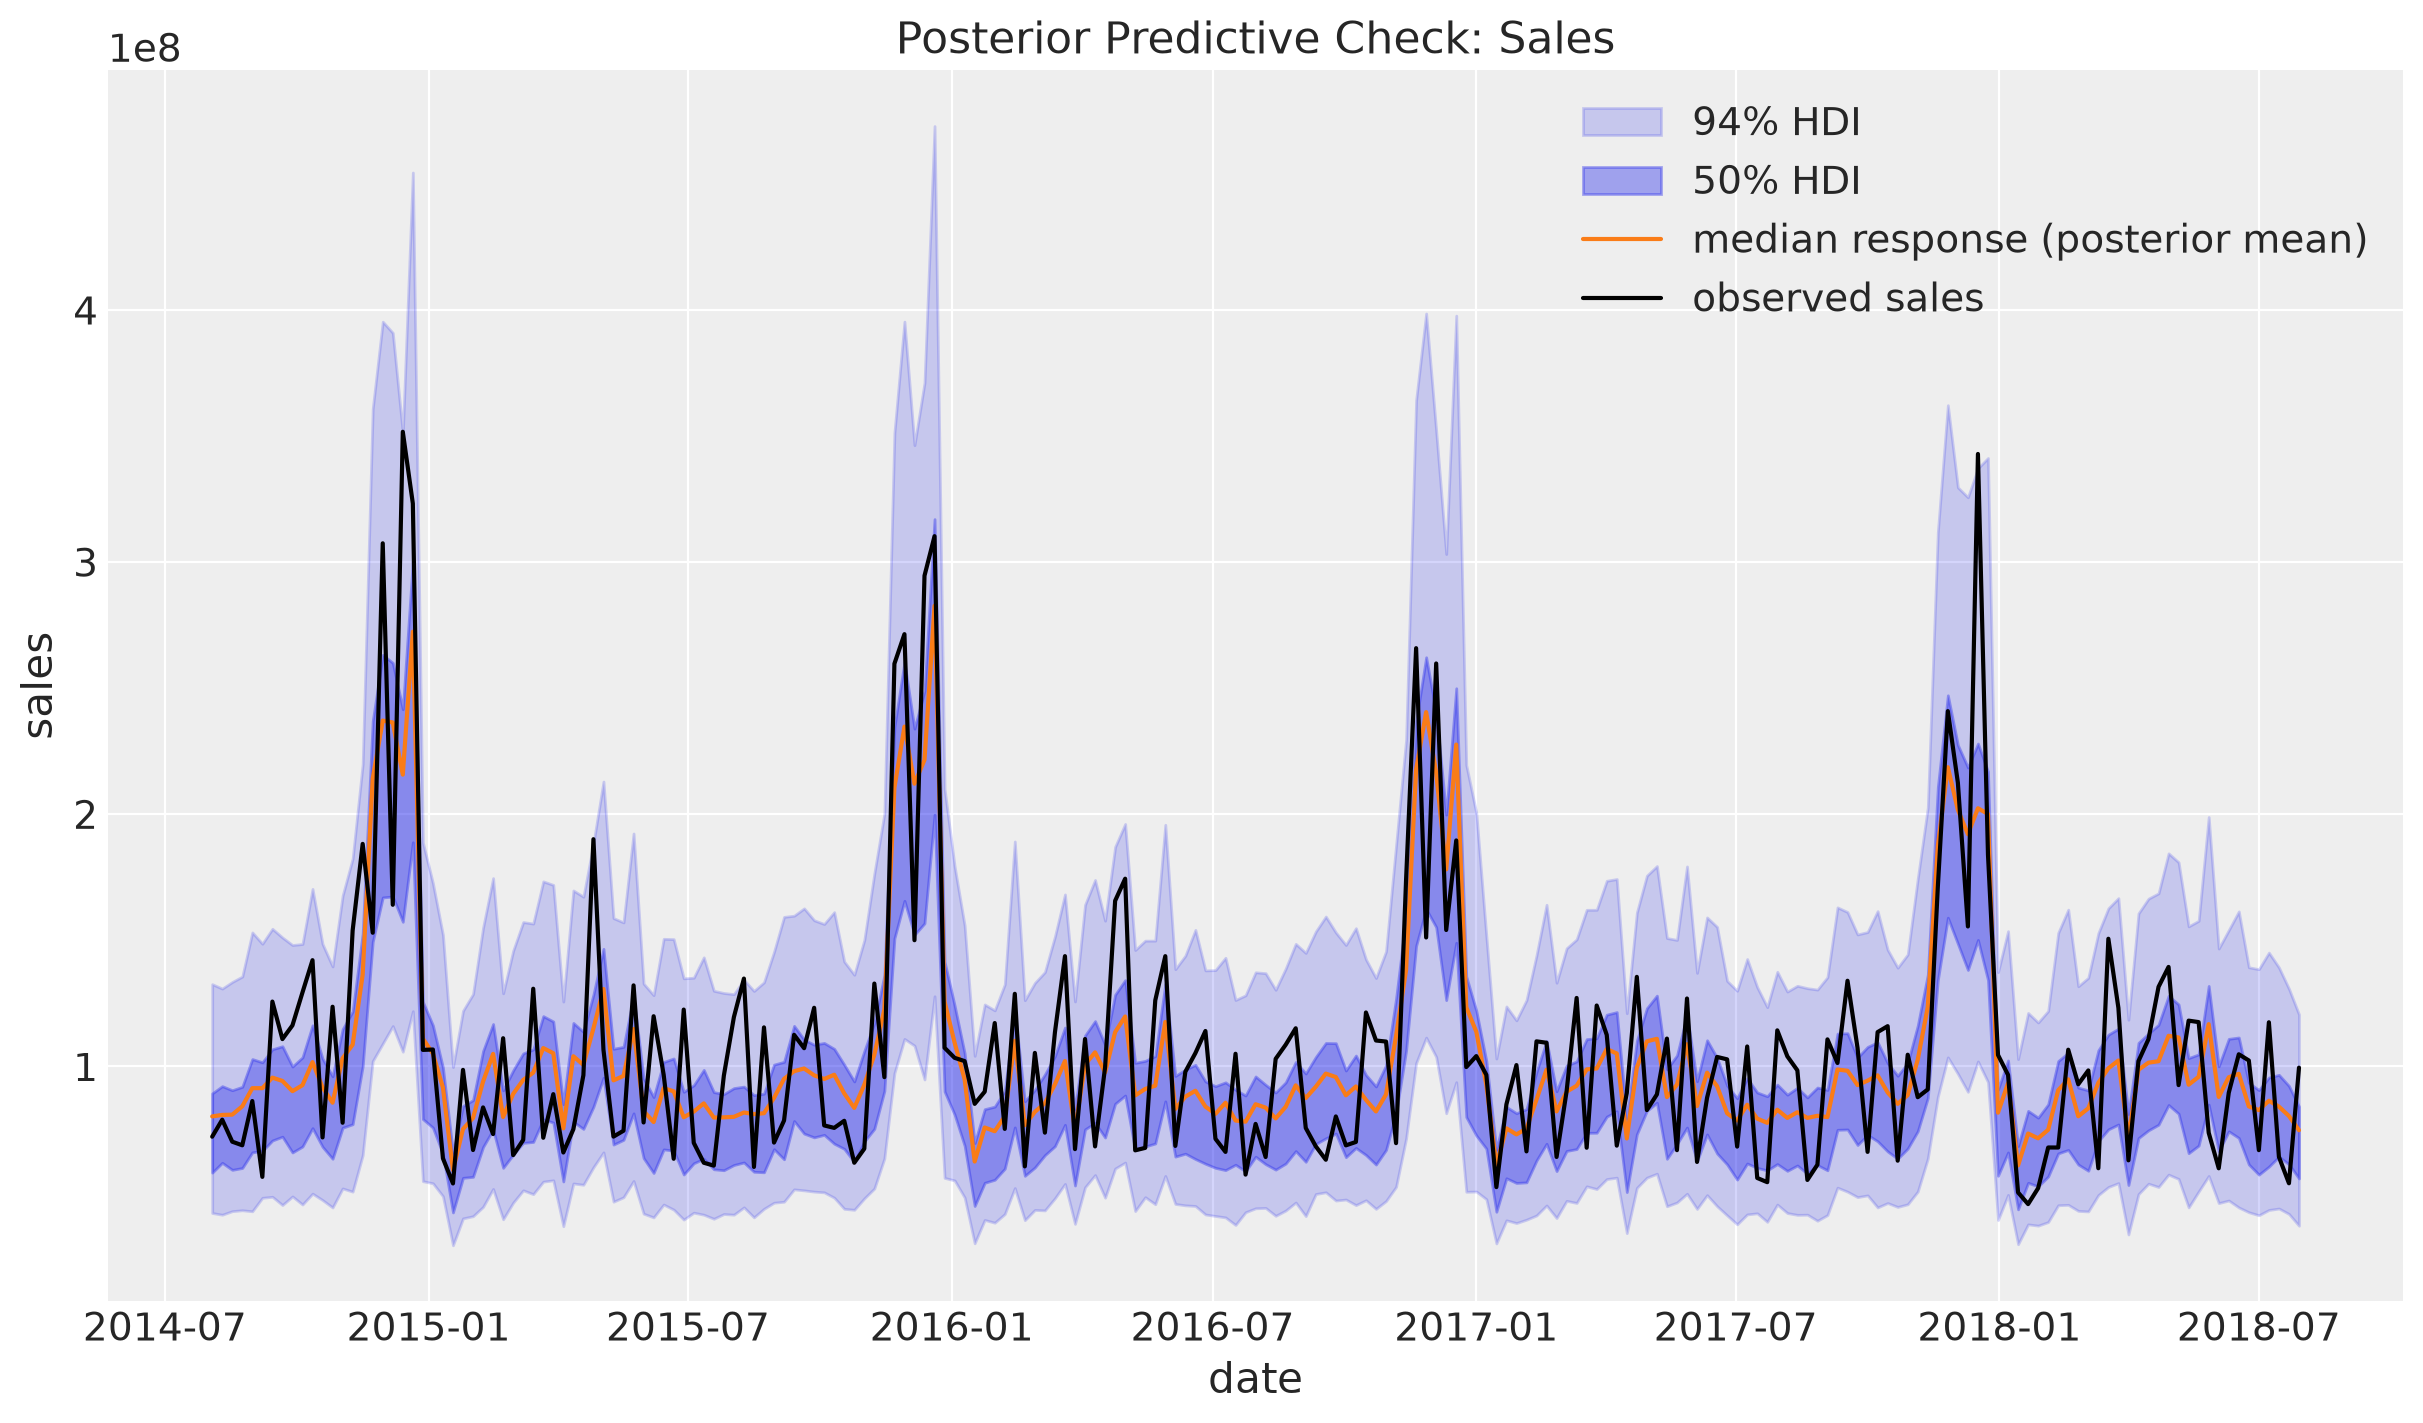

In [17]:
def coverage(pp: xr.DataArray, observed: np.ndarray, prob: float) -> float:
    """Share of observed values inside the HDI of a posterior predictive."""
    hdi = az.hdi(pp, prob=prob)
    lower = hdi.sel(ci_bound="lower").to_numpy()
    upper = hdi.sel(ci_bound="upper").to_numpy()
    return float(((observed >= lower) & (observed <= upper)).mean())


def in_sample_crps(pp: xr.DataArray, observed: np.ndarray) -> float:
    """CRPS of a (chain, draw, date) posterior predictive against the observed series."""
    samples = pp.stack(sample=("chain", "draw")).transpose("sample", "date")
    return float(crps(y_true=observed, y_pred=samples.to_numpy()))


pp_sales = {
    name: model.idata["posterior_predictive"]["y"]
    * float(model.idata["constant_data"]["target_scale"])
    for name, model in models.items()
}
observed_sales = y.to_numpy()

fit_summary = pd.DataFrame(
    {
        name: {
            "inside the 94% HDI": coverage(pp, observed_sales, HDI_PROB),
            "inside the 50% HDI": coverage(pp, observed_sales, 0.5),
            "in-sample CRPS (M)": in_sample_crps(pp, observed_sales) / 1e6,
        }
        for name, pp in pp_sales.items()
    }
)

fig, ax = plt.subplots()
for prob, alpha in [(HDI_PROB, 0.2), (0.5, 0.4)]:
    hdi = az.hdi(pp_sales["log"], prob=prob)
    ax.fill_between(
        dates,
        hdi.sel(ci_bound="lower"),
        hdi.sel(ci_bound="upper"),
        color="C0",
        alpha=alpha,
        label=f"{prob:.0%} HDI",
    )
ax.plot(
    dates,
    posterior["y_original_scale"].mean(("chain", "draw")),
    color="C1",
    label="median response (posterior mean)",
)
ax.plot(dates, y, color="black", label="observed sales")
ax.legend(loc="upper right")
ax.set(title="Posterior Predictive Check: Sales", xlabel="date", ylabel="sales")
fit_summary.round(3)

The band is proportional to the level: wide at the four holiday peaks and narrow in the quiet weeks, where the second iteration's band had one width throughout. The observed line stays inside it except for a few spikes. Both models cover slightly more than $94\%$ of the weeks at the wide level ($98\%$ for both); at the $50\%$ level the identity model covers $55\%$ of the weeks and the log model $42\%$. For the log model, under-coverage at the narrow level with over-coverage at the wide level is a shape mismatch, not a width problem: the residuals are less peaked in the center and lighter in the tails than the `LogNormal` predicts. The log model's in-sample CRPS is about $6\%$ lower. The two models describe the same data about equally well; where they differ is the shape of the noise, not its size.

The SEM impressions check is the second iteration's measurement model unchanged, so we print its coverage for both models rather than draw it again.

In [18]:
observed_impressions = X["sem_impressions"].to_numpy()
for name, model in models.items():
    pp_impressions = model.idata["posterior_predictive"][
        "funnel_sem_impressions_likelihood"
    ]
    print(
        f"{name}: observed impression weeks inside the 94% HDI "
        f"{coverage(pp_impressions, observed_impressions, HDI_PROB):.1%}, "
        f"inside the 50% HDI {coverage(pp_impressions, observed_impressions, 0.5):.1%}"
    )

identity: observed impression weeks inside the 94% HDI 98.1%, inside the 50% HDI 41.6%
log: observed impression weeks inside the 94% HDI 98.1%, inside the 50% HDI 43.5%


**Versus the second iteration**: a slightly lower in-sample CRPS, the same impressions coverage at the wide level and within two points of it at the narrow one, and proportional instead of constant sales bands.

## Media Deep Dive

We read the media in four steps: the contribution shares, the lift curves, the channel synergies, and the ROAS, with the reference model next to the log model throughout.

### Contribution Shares

Under the log link a channel's contribution is a counterfactual, and counterfactuals of different channels overlap, so a stacked decomposition needs a choice. We avoid the choice and report shares from explicit counterfactual passes instead, naming the counterfactual behind each row. Every row divides by the model's own full-spend response $Y_{\text{all}}$: the summed median for the log model, which sits below observed sales by about the mean-over-median factor (the ratio is printed with the passes), and the summed mean for the identity model.

The passes below run both models through the posterior with one or two spend lines set to zero, holding every other line as it ran. We reuse them in the synergies section. Only the noise-free response is read: $s \, e^{\mu}$ for the log model and $s \, \mu$ for the identity model, never the noisy posterior predictive, whose draws would masquerade as interactions.

In [19]:
PASS_VARS = ["mu", "funnel_effect_contribution", "funnel_mediator"]
spend_lines = [*channel_columns, "sem_spend"]
givers = [*upper_channels, "sem_spend"]


def scale_of(model: FunnelMMM) -> float:
    """Target scale of a fitted model."""
    return float(model.idata["constant_data"]["target_scale"])


def pass_var_names(model: FunnelMMM) -> list[str]:
    """Variables to read in a pass: under the log link the median response is a deterministic of mu."""
    if model.link == LinkFunction.LOG:
        return [*PASS_VARS, "y_original_scale"]
    return PASS_VARS  # under the identity link the mean response is mu times the scale


def response(model: FunnelMMM, ds: xr.Dataset) -> xr.DataArray:
    """Noise-free response on the sales scale from a posterior pass, for either link."""
    if model.link == LinkFunction.LOG:
        return ds["y_original_scale"]
    return ds["mu"] * scale_of(model)


def spend_without(members: tuple[str, ...]) -> pd.DataFrame:
    """Observed spend with the given lines set to zero."""
    frame = X.copy()
    for member in members:
        frame[member] = 0.0
    return frame


def run_passes(model: FunnelMMM) -> dict[tuple[str, ...], xr.Dataset]:
    """Posterior passes: all spend, no media, no direct channel, no giver, leave one out, leave two out."""
    keys = [
        (),
        tuple(spend_lines),
        tuple(channel_columns),
        tuple(givers),
        *[(line,) for line in spend_lines],
        *itertools.combinations(spend_lines, 2),
    ]
    return {
        key: model.sample_posterior_predictive(
            spend_without(key),
            var_names=pass_var_names(model),
            combined=False,
            extend_idata=False,
            progressbar=False,
            random_seed=seed,
        )
        for key in keys
    }

In [20]:
%%time
passes = {name: run_passes(model) for name, model in models.items()}

# total response per pass and draw, dims (chain, draw)
Y = {
    name: {
        key: response(models[name], ds).sum("date") for key, ds in model_passes.items()
    }
    for name, model_passes in passes.items()
}
print(f"{len(passes['log'])} passes per model")
print(
    f"log model: summed median response over observed sales "
    f"{float(Y['log'][()].mean()) / float(y.sum()):.3f}"
)

40 passes per model
log model: summed median response over observed sales 0.968
CPU times: user 37.5 s, sys: 801 ms, total: 38.3 s
Wall time: 38.6 s


The SEM path's contribution in sales is the counterfactual of the whole funnel term at full spend: $\sum_t s \, (e^{\mu_t} - e^{\mu_t - f_t})$ for the log model and $\sum_t s \, f_t$ for the identity model. The helper below computes the more general drop of the path when its term falls from $f_t$ to some $f^{-}_t$; with $f^{-}_t = 0$ it is the whole path.

In [21]:
def sem_path_drop(
    model: FunnelMMM, ds: xr.Dataset, f_without: xr.DataArray
) -> xr.DataArray:
    """Sales the SEM path loses when its term drops from the pass's value to `f_without`, per draw."""
    drop = ds["funnel_effect_contribution"] - f_without
    if model.link == LinkFunction.LOG:
        return (ds["y_original_scale"] * (1 - np.exp(-drop))).sum("date")
    return (scale_of(model) * drop).sum("date")


def share_table(name: str) -> pd.Series:
    """Posterior-mean shares of the full-spend response, one counterfactual per row."""
    model, Y_model = models[name], Y[name]
    all_spend = passes[name][()]
    y_all = Y_model[()]
    rows = {
        "no media (every spend line off)": Y_model[tuple(spend_lines)] / y_all,
        "media-driven (joint)": 1 - Y_model[tuple(spend_lines)] / y_all,
        "seven channels off (direct terms plus their pass-through)": 1
        - Y_model[tuple(channel_columns)] / y_all,
        "SEM path (funnel term off)": sem_path_drop(
            model, all_spend, xr.zeros_like(all_spend["funnel_effect_contribution"])
        )
        / y_all,
        "sum of leave-one-out shares": sum(
            1 - Y_model[(line,)] / y_all for line in spend_lines
        ),
    }
    return pd.Series({label: float(value.mean()) for label, value in rows.items()})


shares = pd.DataFrame({name: share_table(name) for name in models})
shares.round(3)

,identity,log
no media (every spend line off),0.621,0.691
media-driven (joint),0.379,0.309
seven channels off (direct terms plus their pass-through),0.308,0.256
SEM path (funnel term off),0.146,0.136
sum of leave-one-out shares,0.378,0.368


Three things to read in this table:

- **The SEM path is nearly the same size in both models**, about $15\%$ of the response under the identity link and $14\%$ under the log link. The mediator is identified by the impressions, and the conversion curve puts the pool at a similar place on both scales.
- **The leave-one-out shares do not add up to the joint share, in opposite directions.** In the identity model their sum falls short of the joint media share by about a thousandth: the pool is concave, so two givers together add a little less than separately, and the pool's term is tiny. In the log model the sum exceeds the joint share by about six points: each channel's counterfactual counts its share of every interaction it participates in. That gap is the interaction mass we quantify in the synergies section.
- **The media-driven share is lower under the log link**, $31\%$ against $38\%$. The fit cannot say which is right; both models reproduce the data about equally well. The ROAS section shows where that difference sits, channel by channel, and the prior sensitivity section whether the prior is behind it.

**Versus the second iteration**: its table divided by observed sales and had one row per component. Its `direct channels` row is the sum of the seven direct terms, while the seven-off row here also removes what `TV`, `Radio`, and `Newspaper` add to the pool; its `mediated SEM` row is the `SEM path` row here, floor included; and the `media-driven` row is new, the joint counterfactual, which excludes the no-media floor of the SEM path.

### Lift Curves

The log model gives every channel a reading the additive model has no equivalent of: the multiplicative lift at the observed weekly spend, $e^{m_{t,c}} - 1$. The scatter below shows it per channel, with the posterior-mean lift at saturation, $e^{\beta_c} - 1$, as a dashed ceiling.

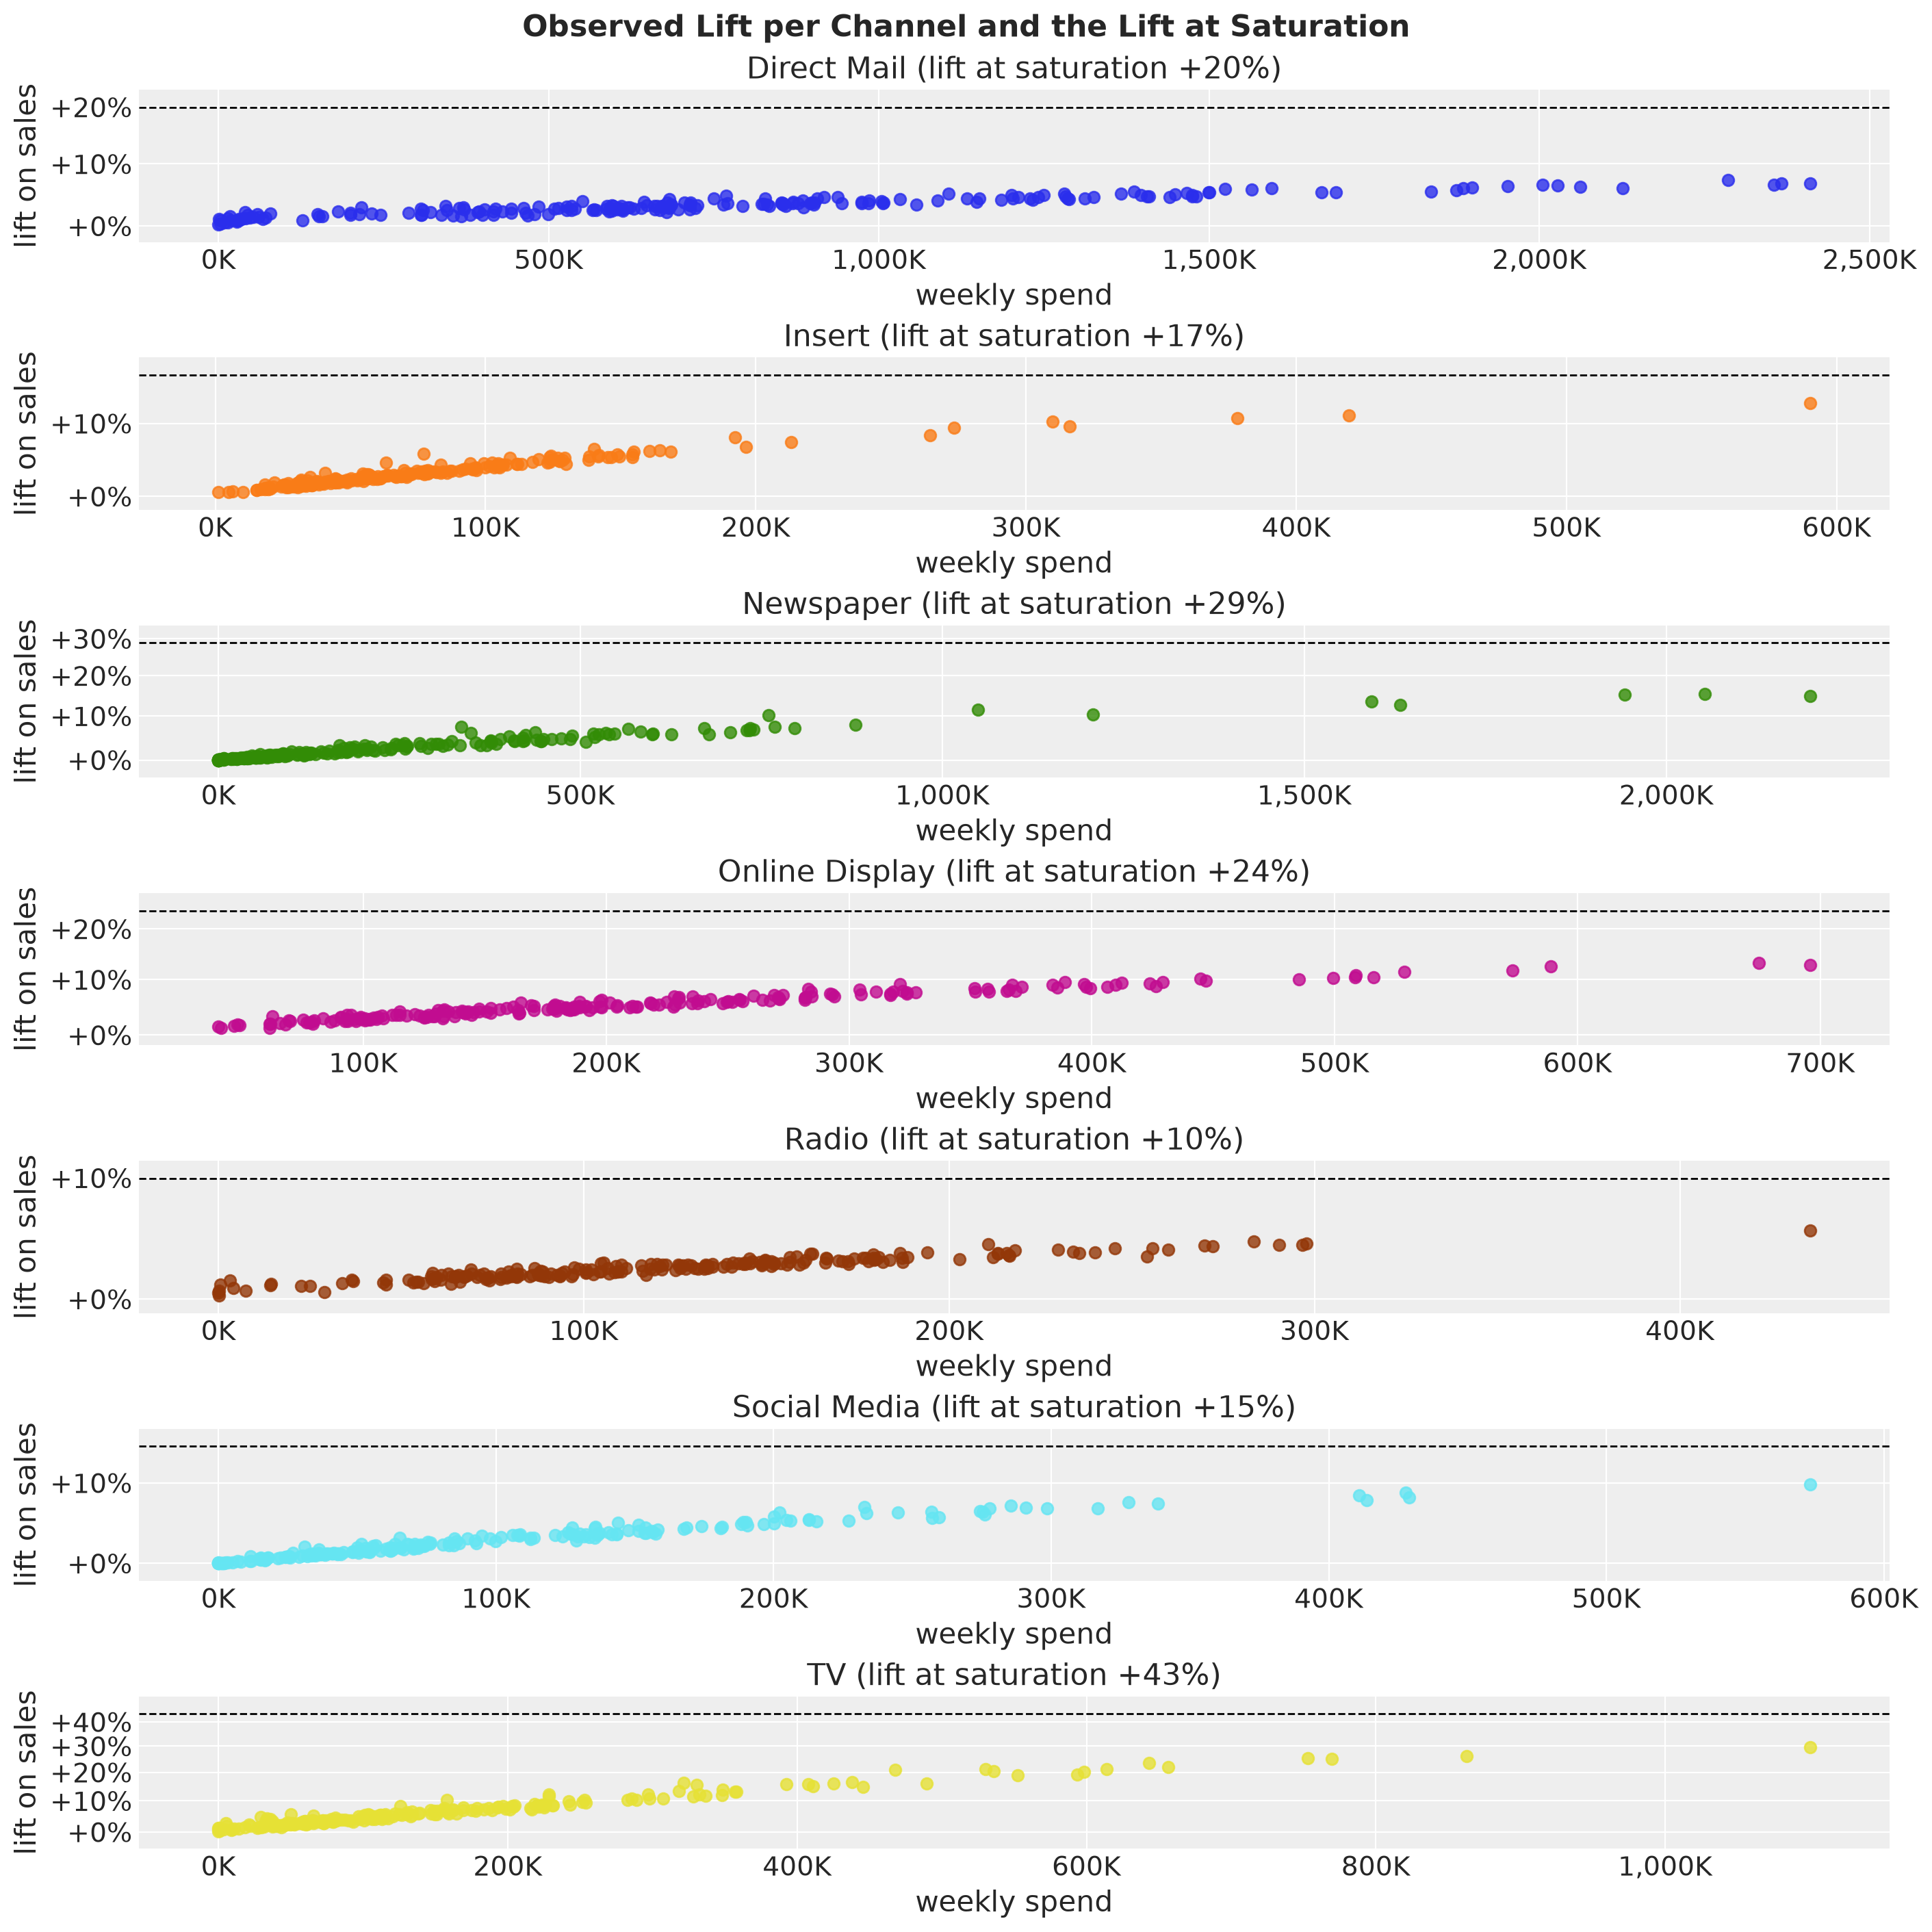

In [22]:
fig, axes = mmm.plot.transformation.saturation_scatterplot(
    original_scale=False, figsize=(14, 14)
)
lift_at_saturation = np.expm1(posterior["saturation_beta"]).mean(("chain", "draw"))

for ax in np.ravel(axes):
    channel = ax.get_title().replace("channel: ", "")
    ceiling = float(lift_at_saturation.sel(channel=channel))
    ax.axhline(np.log1p(ceiling), color="black", linestyle="--", linewidth=1)
    ax.margins(y=0.15)
    lift_ticks = np.log1p(np.arange(0, 0.5, 0.1))
    ax.set_yticks(lift_ticks[lift_ticks <= ax.get_ylim()[1]])
    ax.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda v, _: f"{np.expm1(v):+.0%}")
    )
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v / 1e3:,.0f}K"))
    ax.set(
        xlabel="weekly spend",
        ylabel="lift on sales",
        title=f"{channel} (lift at saturation {ceiling:+.0%})",
    )
fig.set_layout_engine("constrained")
fig.suptitle(
    "Observed Lift per Channel and the Lift at Saturation",
    fontsize=16,
    fontweight="bold",
);

Each point is a week: the channel's spend and the factor by which the model says it multiplied that week's sales. The dashed line is the ceiling the saturation curve allows. Read two things: the slope of the cloud, which is the marginal return, and the distance to the dashed line, which is the headroom. `Direct Mail` has the flattest cloud: its busiest weeks, at over $2M$, lift sales by under $10\%$. `TV` has the steepest cloud and the highest ceiling, with peak weeks near $30\%$ under a ceiling above $40\%$. No channel's typical week sits near its ceiling; only the single busiest weeks of `Insert`, `Social Media`, and `TV` reach two thirds to three quarters of it. This is the picture the budget section's marginal returns are computed from.

**Versus the second iteration**: no equivalent. Its `saturation_beta` is a share of peak sales, not a lift.

### Channel Synergies

The word *synergy* has two meanings in a budget meeting, and this model measures both.

- **Pass-through**: money spent on one channel shows up as sales of another. In our funnel, `TV`, `Radio`, and `Newspaper` add people to the demand pool, and the SEM path converts them. It has a direction, from the givers to the receiver, and the second iteration measured it.
- **Interaction**: one channel makes another more productive. [Naik and Raman (2003)](https://doi.org/10.1509/jmkr.40.4.375.19385) estimate it in an additive model as the coefficient of a product term. A multiplicative model carries it by construction, symmetric and positive for every pair of direct terms, and the second iteration could not measure it. This iteration can.

We measure the two separately, with the reference model next to the log model to show what the link adds.

#### Funnel Synergies

The rule of the second iteration: zero one giver, hold every other spend line as it ran, and read the receiver, the SEM path $f_t$. The givers are `TV`, `Radio`, `Newspaper`, and `sem_spend`; the floor no channel gives is the path that remains with all four off. We read the receiver on two scales:

- **SEM impressions**, $s_{\text{imp}} \, (M^{*}_t - M^{*,-g}_t)$: exact, additive across givers, and independent of the link, because the mediator is a sum of one term per giver (a saturated term per upper channel and a linear term for SEM spend).
- **The SEM path in sales**: the drop of the funnel term, converted at the response of the week. For the log model this is $\sum_t \hat y_t \, (1 - e^{-(f_t - f^{-g}_t)})$ with $\hat y_t$ the full-spend median response, the rule the incrementality module applies; for the identity model it is $\sum_t s \, (f_t - f^{-g}_t)$. The floor row is the path at full spend minus the joint drop of the four givers, $\sum_t \hat y_t \, (e^{-(f_t - f^{-\text{givers}}_t)} - e^{-f_t})$ for the log model and $\sum_t s \, f^{-\text{givers}}_t$ for the identity model: what remains of the path without any giver.

Shares divide by the path at full spend. On the sales scale they need not sum to one, because the pool converts through one concave curve.

In [23]:
impressions_scale = float(X["sem_impressions"].max())
sources = [*givers, "no media (floor)"]


def impressions_lost(name: str, members: tuple[str, ...]) -> xr.DataArray:
    """SEM impressions the receiver loses without the given givers, per draw."""
    mediator_all = passes[name][()]["funnel_mediator"]
    mediator_without = passes[name][members]["funnel_mediator"]
    return (impressions_scale * (mediator_all - mediator_without)).sum("date")


def receiver_shares(name: str) -> xr.Dataset:
    """Share of the SEM path by giver and by the floor, per draw, on both scales."""
    model, model_passes = models[name], passes[name]
    all_spend = model_passes[()]
    path_total = sem_path_drop(
        model, all_spend, xr.zeros_like(all_spend["funnel_effect_contribution"])
    )
    impressions_total = (impressions_scale * all_spend["funnel_mediator"]).sum("date")

    sales, impressions = [], []
    for giver in givers:
        without = model_passes[(giver,)]
        sales.append(
            sem_path_drop(model, all_spend, without["funnel_effect_contribution"])
            / path_total
        )
        impressions.append(impressions_lost(name, (giver,)) / impressions_total)
    without_givers = model_passes[tuple(givers)]
    sales.append(
        1
        - sem_path_drop(model, all_spend, without_givers["funnel_effect_contribution"])
        / path_total
    )
    impressions.append(1 - impressions_lost(name, tuple(givers)) / impressions_total)
    source_dim = pd.Index(sources, name="source")
    return xr.Dataset(
        {
            "SEM impressions": xr.concat(impressions, dim=source_dim),
            "SEM path in sales": xr.concat(sales, dim=source_dim),
        }
    )


receiver_share = xr.concat(
    [receiver_shares(name) for name in models], dim=pd.Index(list(models), name="model")
)

A small helper draws a forest with the two models side by side (thin bar $94\%$ HDI, thick bar $50\%$ HDI, dot the posterior mean), which we reuse below.

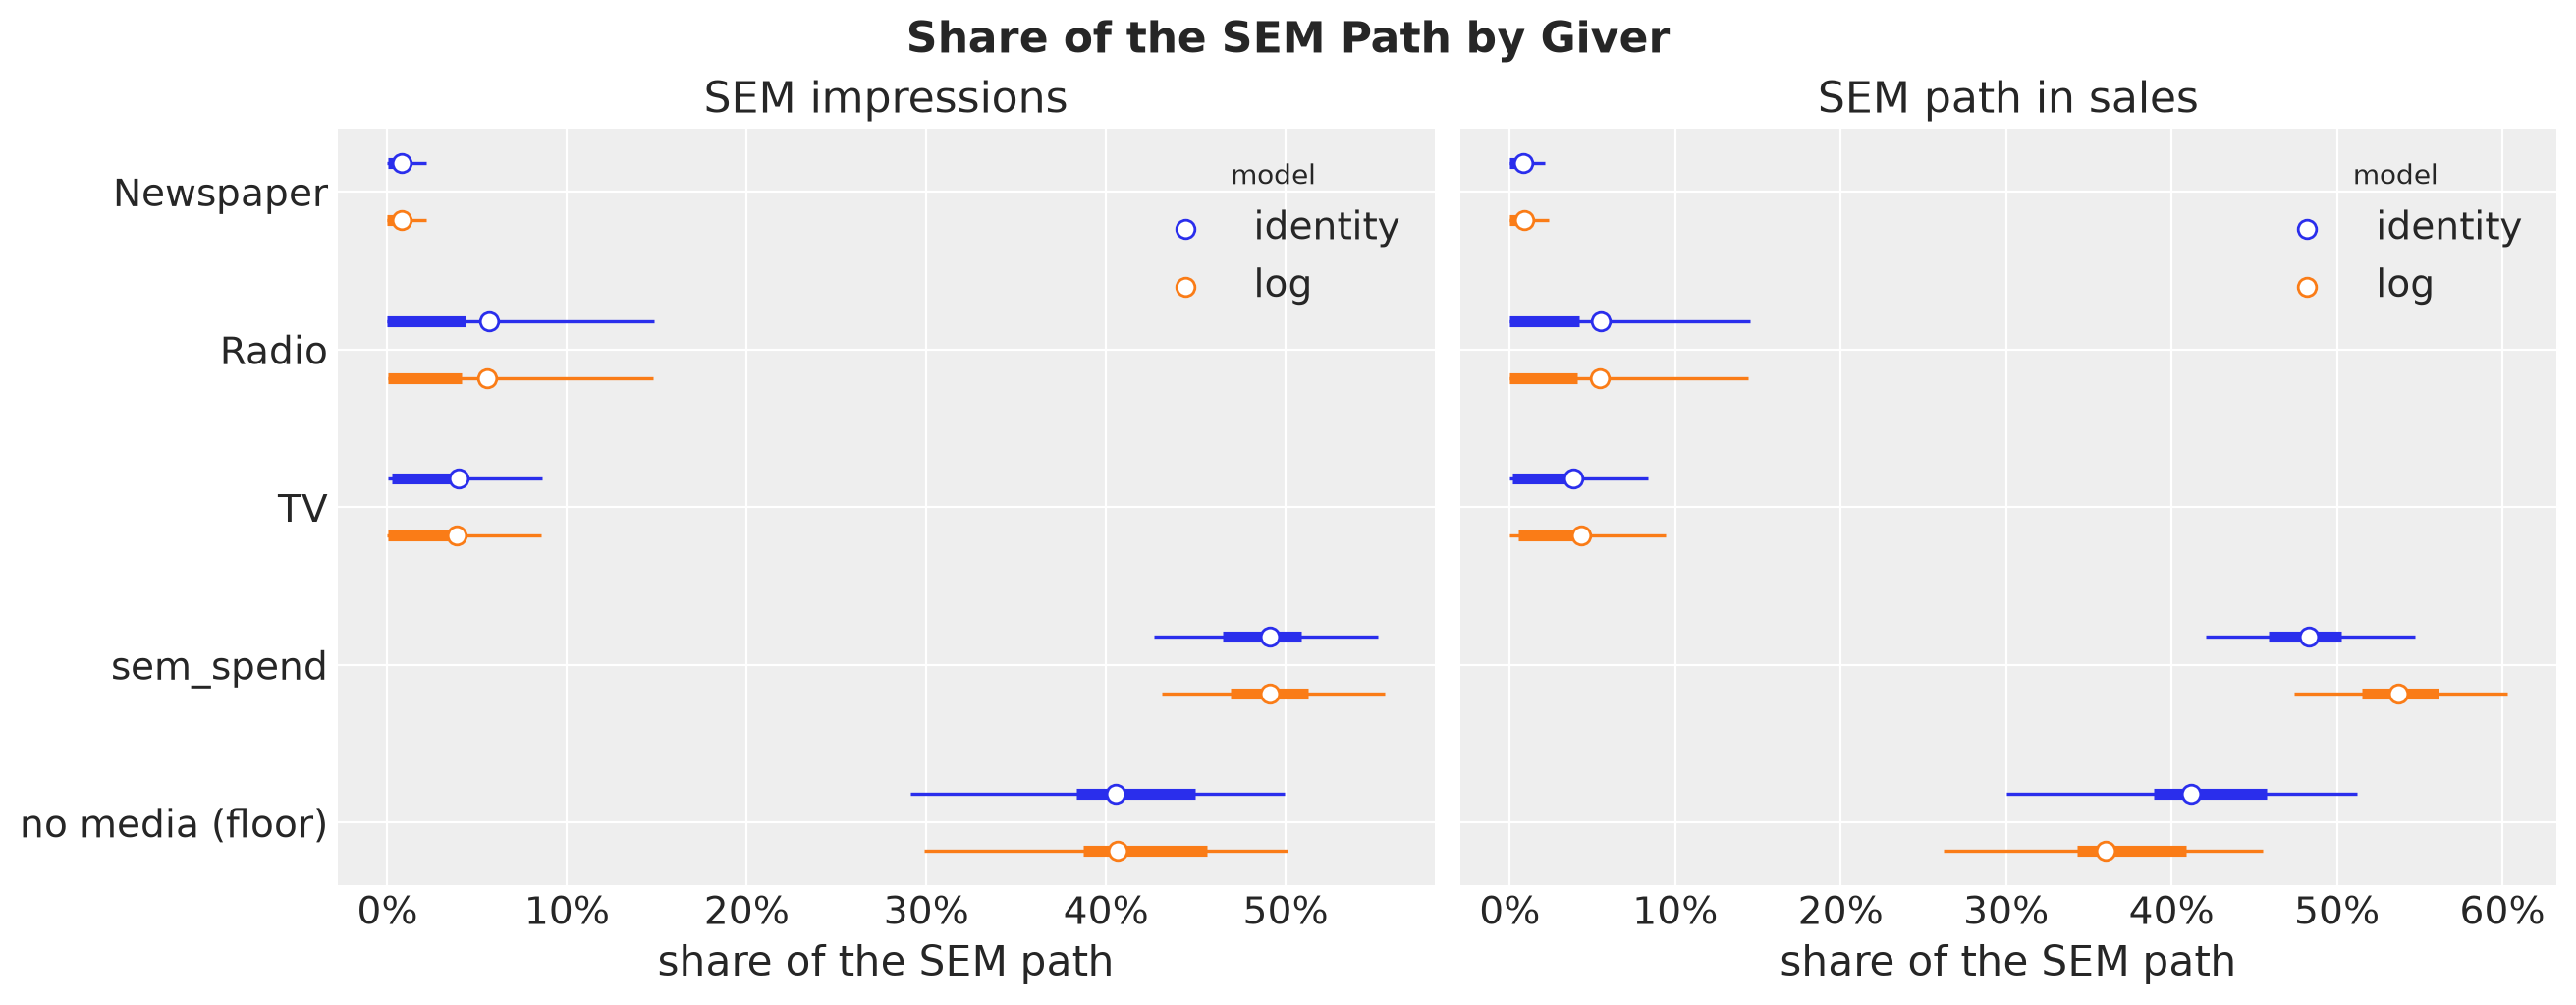

In [24]:
def forest_by_model(
    da: xr.DataArray,
    row_dim: str,
    ax: plt.Axes,
    xlabel: str,
    title: str | None = None,
    percent: bool = True,
    legend_loc: str = "best",
) -> plt.Axes:
    """Forest of a (model, row, chain, draw) array, one color and a small offset per model."""
    rows = list(da[row_dim].values)
    model_names = list(da["model"].values)
    positions = np.arange(len(rows))[::-1]
    offsets = np.linspace(0.18, -0.18, len(model_names))
    for name, offset, color in zip(model_names, offsets, ["C0", "C1"], strict=True):
        sub = da.sel(model=name)
        hdi_wide = az.hdi(sub, prob=HDI_PROB)
        hdi_narrow = az.hdi(sub, prob=0.5)
        ax.hlines(
            positions + offset,
            hdi_wide.sel(ci_bound="lower"),
            hdi_wide.sel(ci_bound="upper"),
            color=color,
            linewidth=1.2,
        )
        ax.hlines(
            positions + offset,
            hdi_narrow.sel(ci_bound="lower"),
            hdi_narrow.sel(ci_bound="upper"),
            color=color,
            linewidth=4,
        )
        ax.scatter(
            sub.mean(("chain", "draw")),
            positions + offset,
            color="white",
            edgecolor=color,
            zorder=3,
            s=45,
            label=name,
        )
    ax.set_yticks(positions)
    ax.set_yticklabels(rows)
    if percent:
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    if legend_loc == "outside":
        ax.legend(title="model", loc="upper left", bbox_to_anchor=(1.01, 1.0))
    else:
        ax.legend(title="model", loc=legend_loc)
    ax.set(title=title, xlabel=xlabel)
    return ax


fig, axes = plt.subplots(
    nrows=1, ncols=2, figsize=(13, 5), sharey=True, layout="constrained"
)
for ax, scale in zip(axes, ["SEM impressions", "SEM path in sales"], strict=True):
    forest_by_model(
        receiver_share[scale],
        "source",
        ax=ax,
        xlabel="share of the SEM path",
        title=scale,
    )
fig.suptitle("Share of the SEM Path by Giver", fontsize=16, fontweight="bold");

The table carries the numbers behind both panels, with the exchange rate into search demand (SEM impressions per dollar of each giver over the $209$ weeks) next to them.

In [25]:
def summary_table(da: xr.DataArray) -> pd.DataFrame:
    """Posterior mean and 94% HDI over the remaining dims, as a DataFrame."""
    hdi = az.hdi(da, prob=HDI_PROB)
    return xr.Dataset(
        {
            "mean": da.mean(("chain", "draw")),
            "hdi_low": hdi.sel(ci_bound="lower", drop=True),
            "hdi_high": hdi.sel(ci_bound="upper", drop=True),
        }
    ).to_dataframe()


spend_totals = xr.DataArray(
    [float(X[giver].sum()) for giver in givers],
    dims="source",
    coords={"source": givers},
)
impressions_per_dollar = xr.concat(
    [
        xr.concat(
            [impressions_lost(name, (giver,)) for giver in givers],
            dim=pd.Index(givers, name="source"),
        )
        / spend_totals
        for name in models
    ],
    dim=pd.Index(list(models), name="model"),
)

pass_through = pd.concat(
    {
        "share of SEM impressions": summary_table(receiver_share["SEM impressions"]),
        "share of the SEM path in sales": summary_table(
            receiver_share["SEM path in sales"]
        ),
        "impressions per dollar": summary_table(impressions_per_dollar),
    },
    axis=1,
)
pass_through.round(3)

share of SEM impressions                   \
                                              mean hdi_low hdi_high   
source           model                                                
Newspaper        identity                    0.008   0.000    0.022   
                 log                         0.008   0.000    0.021   
Radio            identity                    0.056   0.000    0.148   
                 log                         0.055   0.000    0.148   
TV               identity                    0.039   0.000    0.086   
                 log                         0.039   0.000    0.086   
sem_spend        identity                    0.491   0.427    0.551   
                 log                         0.491   0.431    0.555   
no media (floor) identity                    0.405   0.291    0.499   
                 log                         0.407   0.299    0.501   

                          share of the SEM path in sales                   \
                                                    mean hdi_low hdi_high   
source           model                                                      
Newspaper        identity                          0.008   0.000    0.021   
                 log                               0.009   0.000    0.024   
Radio            identity                          0.055   0.000    0.146   
                 log                               0.055   0.000    0.144   
TV               identity                          0.038   0.000    0.083   
                 log                               0.043   0.000    0.094   
sem_spend        identity                          0.483   0.421    0.547   
                 log                               0.537   0.474    0.603   
no media (floor) identity                          0.412   0.300    0.512   
                 log                               0.360   0.262    0.455   

                          impressions per dollar                   
                                            mean hdi_low hdi_high  
source           model                                             
Newspaper        identity                  0.007   0.000    0.018  
                 log                       0.007   0.000    0.018  
Radio            identity                  0.099   0.000    0.261  
                 log                       0.098   0.000    0.260  
TV               identity                  0.051   0.000    0.110  
                 log                       0.049   0.000    0.110  
sem_spend        identity                  0.169   0.149    0.189  
                 log                       0.169   0.150    0.189  
no media (floor) identity                    NaN     NaN      NaN  
                 log                         NaN     NaN      NaN

Here is how to read the pass-through:

- **The impressions scale does not depend on the link.** Row by row, the two models give the same shares and the same exchange rates: `sem_spend` holds about half of the SEM path, the no-media floor about $40\%$, `Radio` and `TV` a few percent each with intervals that reach zero, and `Newspaper` almost nothing. The mediator equation is identical in both models and the impressions identify it.
- **On the sales scale the means move by a few points**, inside the intervals: the `sem_spend` row up and the floor row down under the log link. The log model values a unit of the path at the week's level, and SEM bids hardest in the peak weeks, so the same drop of the term is worth more sales when SEM is the giver. This reading is a mechanism consistent with the direction, not a quantity we isolate.

**Versus the second iteration**: its pass-through numbers are reproduced by the `identity` rows, and the `log` rows agree with them.

**Business Value**: the brand team's claim on the search line, and the search team's exchange rate, do not depend on the link.

#### Interaction Synergies

The pass-through has a direction. The interaction has none: it is the sales that two channels produce together and neither produces alone. We measure it with the inclusion-exclusion of two leave-one-out counterfactuals and one leave-two-out counterfactual, the rest as run:

$$I_{ij} = Y_{\text{all}} - Y_{-i} - Y_{-j} + Y_{-ij}.$$

For two direct terms in the log model this is $\sum_t \hat y^{-ij}_t \, (e^{m_{t,i}} - 1)(e^{m_{t,j}} - 1)$, positive in every posterior draw. In the identity model it is exactly zero. Pairs that share the demand pool also carry the pool's concave term. In the identity model that term is the whole interaction, and it is negative. In the log model it dents the product term, so whether the pair's interaction stays positive is a finding, not a property of the form.

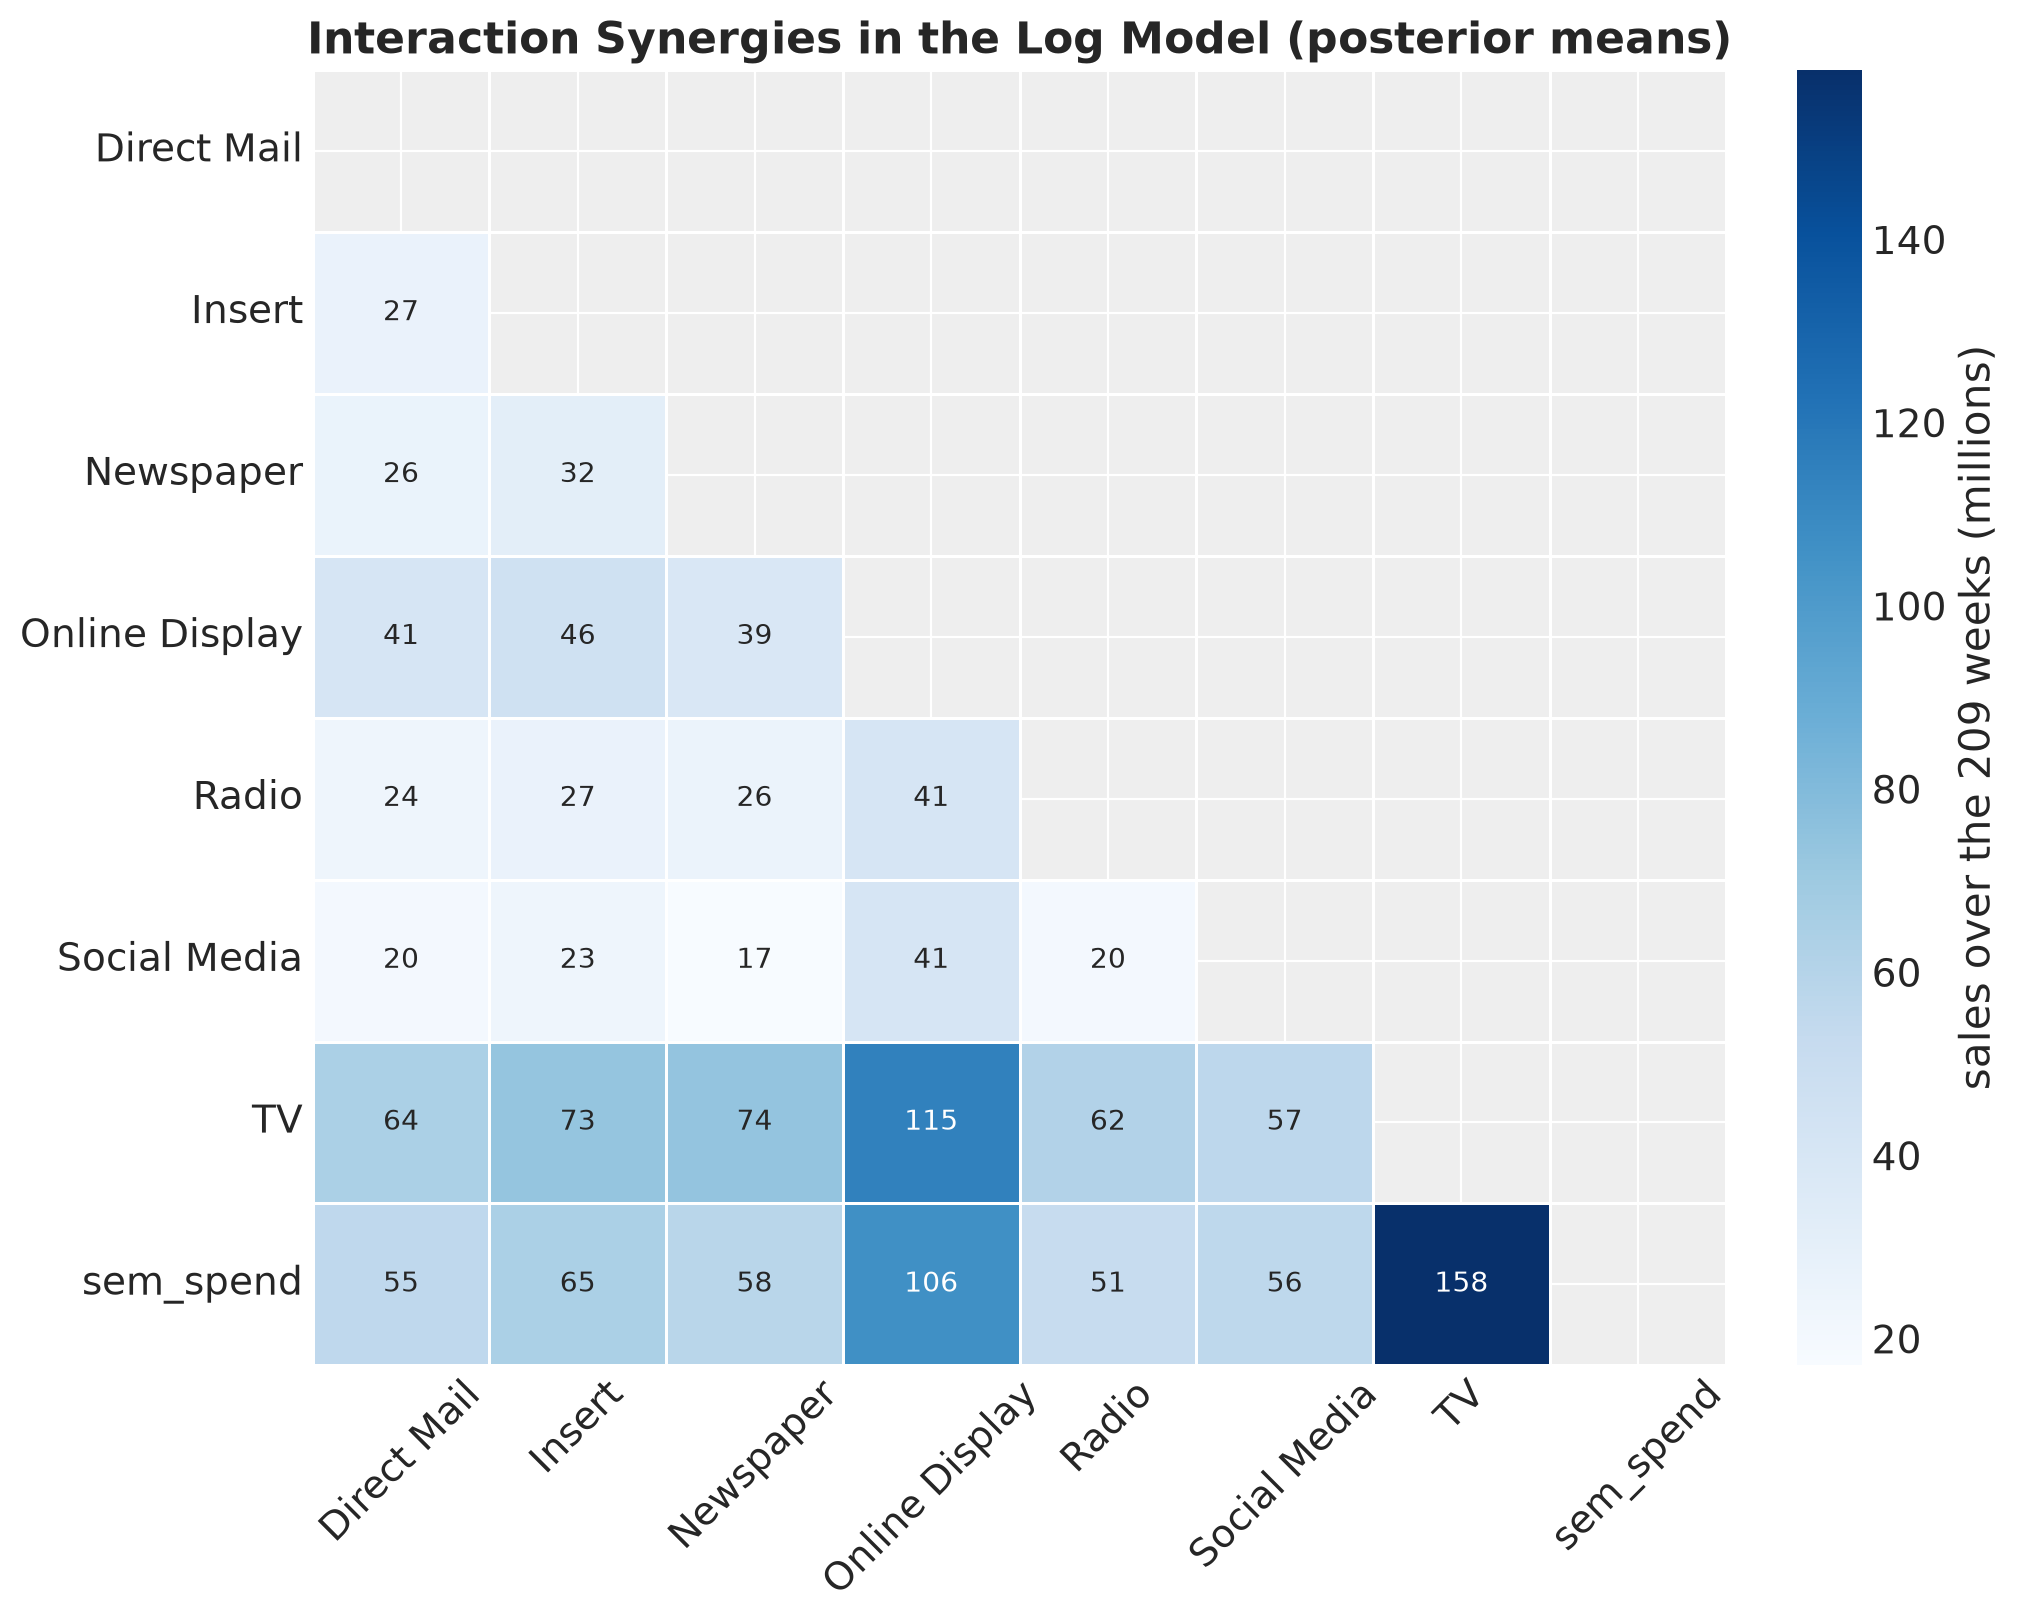

In [26]:
def pair_key(first: str, second: str) -> tuple[str, str]:
    """Return the leave-two-out key of a pair, in the order the passes use."""
    return tuple(sorted((first, second), key=spend_lines.index))


def interaction(name: str, first: str, second: str) -> xr.DataArray:
    """Pairwise interaction of two spend lines, per draw."""
    Y_model = Y[name]
    return (
        Y_model[()]
        - Y_model[(first,)]
        - Y_model[(second,)]
        + Y_model[pair_key(first, second)]
    )


interaction_matrix = pd.DataFrame(index=spend_lines, columns=spend_lines, dtype=float)
for first, second in itertools.combinations(spend_lines, 2):
    value = float(interaction("log", first, second).mean()) / 1e6
    interaction_matrix.loc[first, second] = value
    interaction_matrix.loc[second, first] = value

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    interaction_matrix,
    mask=np.triu(np.ones_like(interaction_matrix, dtype=bool)),
    annot=True,
    fmt=".0f",
    cmap="Blues",
    cbar_kws={"label": "sales over the 209 weeks (millions)"},
    linewidths=0.5,
    ax=ax,
)
ax.set(xlabel="", ylabel="")
ax.tick_params(axis="x", rotation=45)
ax.set_title(
    "Interaction Synergies in the Log Model (posterior means)",
    fontsize=16,
    fontweight="bold",
);

Every cell is positive: for pairs of direct terms by the functional form, for the six pool pairs as a finding (the probability of a positive interaction is printed for each of them below the next figure). The largest cells sit where the three largest lifts meet: `TV` with `sem_spend`, `TV` with `Online Display`, and `Online Display` with `sem_spend`, each above $100$ million over the four years.

The heatmap gives dollars; the forest below gives the interaction as a share of the pair's joint lift, $I_{ij} / (Y_{\text{all}} - Y_{-ij})$, with its uncertainty and with the reference model next to it, for three pairs that stand for three cases:

- `Online Display` and `Direct Mail`: two calibrated direct lines, pure interaction. The identity value is zero by construction.
- `TV` and `Radio`: two channels at the same level of the funnel. Both feed the pool, so the pair carries the product interaction plus a small shared-pool term.
- `TV` and `sem_spend`: across the funnel. The pass-through itself sits in the main effects, not in $I_{ij}$; what the pair adds is the product of the `TV` term with the SEM path, and the pool's dent at its largest.

P(interaction > 0) for Newspaper x Radio in the log model: 100.0%
P(interaction > 0) for Newspaper x TV in the log model: 100.0%
P(interaction > 0) for Newspaper x sem_spend in the log model: 99.6%
P(interaction > 0) for Radio x TV in the log model: 100.0%
P(interaction > 0) for Radio x sem_spend in the log model: 97.4%
P(interaction > 0) for TV x sem_spend in the log model: 99.6%
posterior-mean interaction share over all 28 pairs: 1.0% (Newspaper x Social Media) to 4.2% (TV x sem_spend)
sum of the 28 pairwise interactions over the response: 0.066; gap between the sum of leave-one-out shares and the joint media share: 0.059


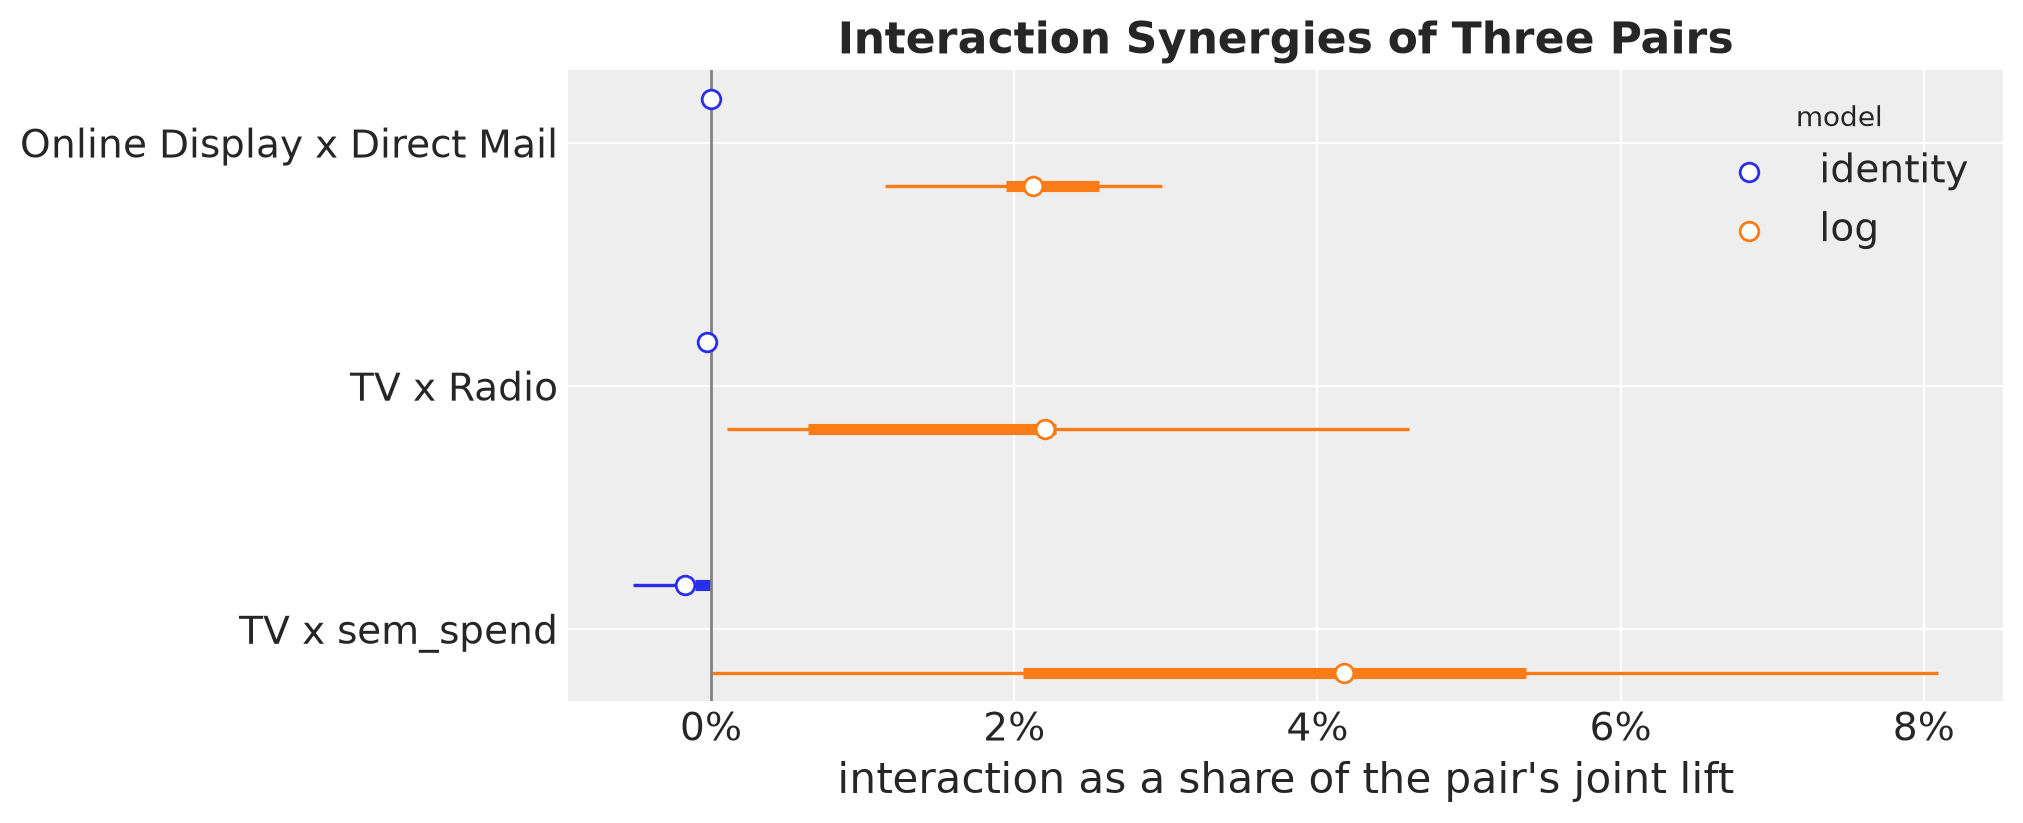

In [27]:
highlighted_pairs = {
    "Online Display x Direct Mail": ("Online Display", "Direct Mail"),
    "TV x Radio": ("TV", "Radio"),
    "TV x sem_spend": ("TV", "sem_spend"),
}


def interaction_share(name: str, first: str, second: str) -> xr.DataArray:
    """Interaction of a pair as a share of the pair's joint lift, per draw."""
    joint_lift = Y[name][()] - Y[name][pair_key(first, second)]
    return interaction(name, first, second) / joint_lift


pair_share = xr.concat(
    [
        xr.concat(
            [interaction_share(name, *pair) for pair in highlighted_pairs.values()],
            dim=pd.Index(list(highlighted_pairs), name="pair"),
        )
        for name in models
    ],
    dim=pd.Index(list(models), name="model"),
)

for first, second in itertools.combinations(givers, 2):
    # pool pairs: the sign is a finding, not the form's
    positive = float((interaction("log", first, second) > 0).mean())
    print(f"P(interaction > 0) for {first} x {second} in the log model: {positive:.1%}")

all_pair_shares = pd.Series(
    {
        f"{first} x {second}": float(interaction_share("log", first, second).mean())
        for first, second in itertools.combinations(spend_lines, 2)
    }
)
print(
    f"posterior-mean interaction share over all 28 pairs: "
    f"{all_pair_shares.min():.1%} ({all_pair_shares.idxmin()}) to "
    f"{all_pair_shares.max():.1%} ({all_pair_shares.idxmax()})"
)

# inclusion-exclusion: the leave-one-out gap equals the sum of pairwise interactions
# minus the third- and higher-order terms, so the pairs account for it to second order
pairwise_total = sum(
    interaction("log", first, second)
    for first, second in itertools.combinations(spend_lines, 2)
)
print(
    f"sum of the 28 pairwise interactions over the response: "
    f"{float((pairwise_total / Y['log'][()]).mean()):.3f}; gap between the sum of "
    f"leave-one-out shares and the joint media share: "
    f"{shares.loc['sum of leave-one-out shares', 'log'] - shares.loc['media-driven (joint)', 'log']:.3f}"
)

fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
forest_by_model(
    pair_share, "pair", ax=ax, xlabel="interaction as a share of the pair's joint lift"
)
ax.axvline(0, color="gray", linewidth=1)
ax.set_title("Interaction Synergies of Three Pairs", fontsize=16, fontweight="bold");

The interaction is present in every draw and second order. In the log model its posterior mean is between about $1\%$ and $4\%$ of a pair's joint lift for every one of the $28$ pairs (the range is printed above), because the per-channel lifts are small and the interaction is their product: $(e^{m_i} - 1)(e^{m_j} - 1) \approx m_i m_j$. For the six pool pairs the probability of a positive interaction is printed above: the product interaction outweighs the pool's dent in nearly every draw. Across all eight lines the pairwise interactions account, to second order, for the gap between the sum of leave-one-out shares and the joint media share of the shares table: the two numbers printed above differ by the third- and higher-order terms, which enter with the opposite sign.

**Versus the second iteration**: it could not pose the question. Its refit answers it with a zero for the direct pair, and a small negative number for the two pool pairs: without the product interaction, two givers together earn slightly less than separately, because they share one concave pool. The multiplicative model turns both into a small positive number.

**Business Value**: at this size the budget section can treat the direct lines as nearly independent. The synergy that moves money in this model is the funnel pass-through, not the multiplicative interaction.

```{warning}
**Critical Assessment**: the sign and the symmetry of the interaction are the link's, not the data's. The data decide only its size, through the per-channel lifts. A test that varies two channels at once, in a factorial design, is the experiment that could tell a real interaction from the functional form, and we recommend one in the next steps.
```

### Return on Ad Spend (ROAS)

{meth}`~pymc_marketing.mmm.incrementality.Incrementality.contribution_over_spend` runs the spend counterfactual per channel on every posterior draw, through both paths, and on the response scale for either link. For the log model we ask for the mean scale, the experiments' scale, and keep the median-scale version for the two places that need it: the calibration check, which ties it to the registered increment, and the marginal table of the budget section, whose other column is on the optimizer's median scale. For the identity model we take the default, the latent-mean change $s \, m_{t,c}$, the second iteration's ROAS; its `TruncatedNormal` likelihood has a mean that is not $\mu$, so the library refuses `central_tendency="mean"` there, and the calibration constrains the same latent change.

In [28]:
roas = {
    "identity": mmm_ii.incrementality.contribution_over_spend(
        frequency="all_time"
    ).rename("roas"),
    "log": mmm.incrementality.contribution_over_spend(
        frequency="all_time", central_tendency="mean"
    ).rename("roas"),
}
roas_log_median = mmm.incrementality.contribution_over_spend(
    frequency="all_time"
).rename("roas")
roas["log"].dims

('chain', 'draw', 'channel')

The forest compares the two posteriors channel by channel: the identity model's level change per dollar and the log model's on the mean scale, both the expected sales a dollar adds.

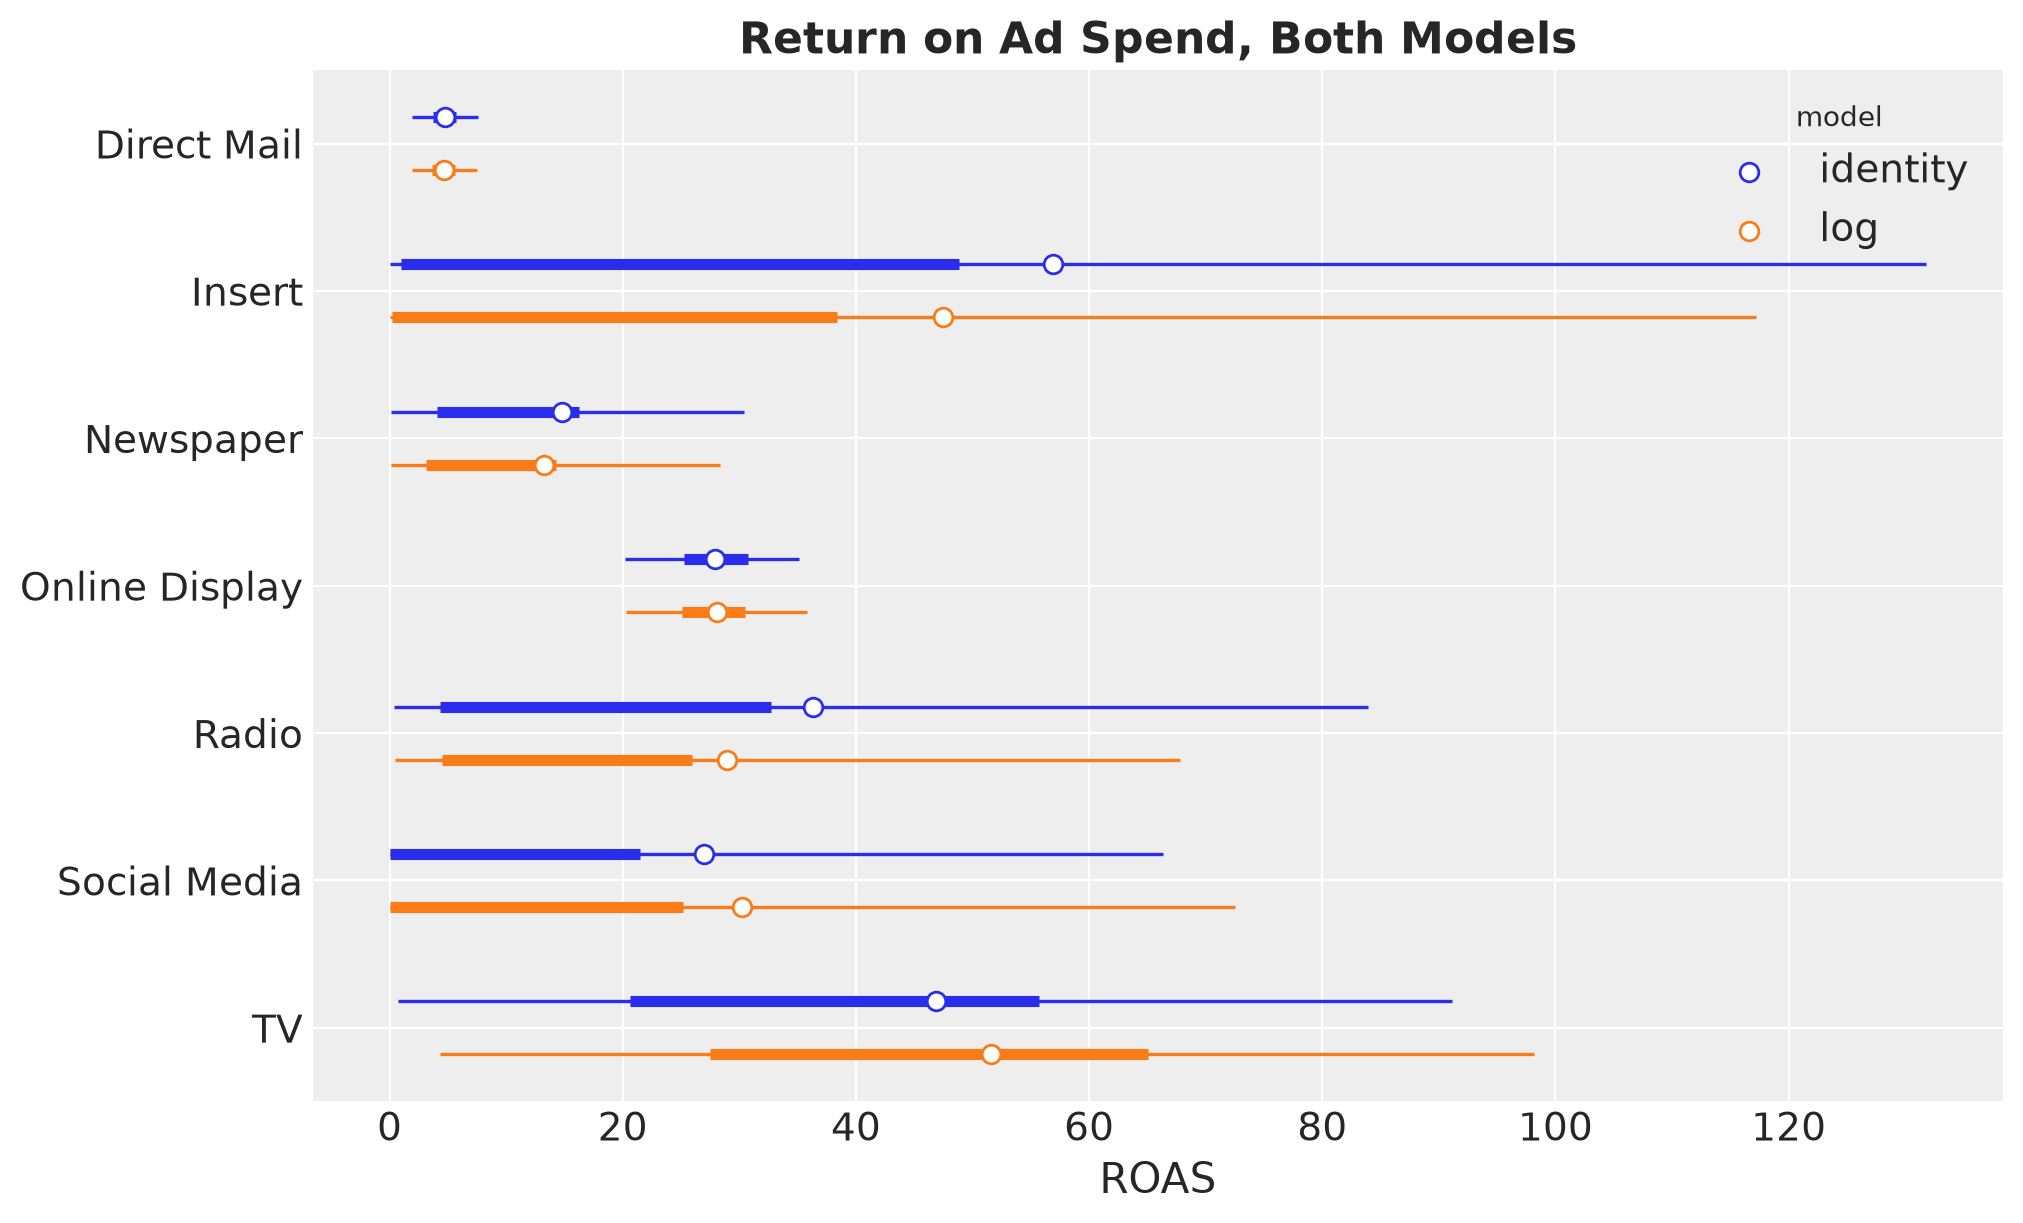

In [29]:
roas_by_model = xr.concat(
    [roas[name] for name in models], dim=pd.Index(list(models), name="model")
)

fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
forest_by_model(roas_by_model, "channel", ax=ax, xlabel="ROAS", percent=False)
ax.set_title("Return on Ad Spend, Both Models", fontsize=16, fontweight="bold");

In [30]:
roas_summary = {name: summary_table(roas[name]) for name in models}
roas_comparison = pd.concat(roas_summary, axis=1)
roas_comparison[("comparison", "mean shift (log minus identity)")] = (
    roas_summary["log"]["mean"] - roas_summary["identity"]["mean"]
)
roas_comparison[("comparison", "HDI width ratio (log over identity)")] = (
    roas_summary["log"]["hdi_high"] - roas_summary["log"]["hdi_low"]
) / (roas_summary["identity"]["hdi_high"] - roas_summary["identity"]["hdi_low"])

for name in models:
    ranking = roas_summary[name]["mean"].sort_values(ascending=False).index
    print(f"{name} ranking by posterior mean: {' > '.join(ranking)}")

roas_comparison.round(2)

identity ranking by posterior mean: Insert > TV > Radio > Online Display > Social Media > Newspaper > Direct Mail
log ranking by posterior mean: TV > Insert > Social Media > Radio > Online Display > Newspaper > Direct Mail


identity                     log                   \
                   mean hdi_low hdi_high   mean hdi_low hdi_high   
channel                                                            
Direct Mail        4.72    1.93     7.55   4.68    1.90     7.49   
Insert            56.86    0.01   131.82  47.44    0.03   117.22   
Newspaper         14.81    0.15    30.43  13.23    0.12    28.35   
Online Display    27.89   20.23    35.16  28.11   20.26    35.77   
Radio             36.31    0.35    83.94  28.90    0.49    67.77   
Social Media      26.94    0.00    66.34  30.22    0.00    72.48   
TV                46.89    0.76    91.13  51.59    4.35    98.17   

                                    comparison  \
               mean shift (log minus identity)   
channel                                          
Direct Mail                              -0.04   
Insert                                   -9.42   
Newspaper                                -1.58   
Online Display                            0.22   
Radio                                    -7.41   
Social Media                              3.28   
TV                                        4.70   

                                                    
               HDI width ratio (log over identity)  
channel                                             
Direct Mail                                   0.99  
Insert                                        0.89  
Newspaper                                     0.93  
Online Display                                1.04  
Radio                                         0.80  
Social Media                                  1.09  
TV                                            1.04

The `identity` columns reproduce the ROAS table of {ref}`mmm_case_study2` up to sampling noise. Against them, the log model moves no channel out of its interval, and the two calibrated channels sit at the same values. The five uncalibrated ones shift by up to about nine ROAS points, `Insert` and `Radio` down by a sixth and a fifth of their means, `TV` and `Social Media` up by a tenth, inside intervals that span tens of points, with width ratios between about $0.8$ and $1.1$. The rankings printed above show the reorderings those shifts cause: `TV` and `Insert` swap at the top, and `Social Media` moves up past `Online Display` and `Radio`. Weighted by spend, the three downward shifts (`Insert`, `Radio`, `Newspaper`) outweigh the two upward ones; that net is one source of the lower media-driven share in the shares table.

Before the calibration check, the comparison the prior table promised. We refit the log model once more with the second iteration's prior width kept as it was, `HalfNormal(share)`, and put its posterior means next to the two columns above.

In [31]:
mmm_narrow = build_calibrated(make_mmm(X, y, link="log", comparable_priors=False), X, y)
mmm_narrow.fit(
    X=X,
    y=y,
    target_accept=0.95,
    chains=4,
    cores=4,
    draws=2_000,
    tune=2_000,
    nuts_sampler="nutpie",
    random_seed=rng,
    progressbar=False,
)
roas_narrow = mmm_narrow.incrementality.contribution_over_spend(
    frequency="all_time", central_tendency="mean"
)
print(
    f"narrow-prior log model: {int(mmm_narrow.idata['sample_stats']['diverging'].sum())} "
    f"divergences, max r_hat {max_r_hat(mmm_narrow):.4f}"
)

pd.DataFrame(
    {
        "identity": roas_summary["identity"]["mean"],
        "log, comparable prior": roas_summary["log"]["mean"],
        "log, HalfNormal(share) prior": roas_narrow.mean(("chain", "draw")).to_pandas(),
    }
).round(1)

Output()

narrow-prior log model: 0 divergences, max r_hat 1.0038


,identity,"log, comparable prior","log, HalfNormal(share) prior"
channel,,,
Direct Mail,4.7,4.7,4.7
Insert,56.9,47.4,14.0
Newspaper,14.8,13.2,10.3
Online Display,27.9,28.1,27.6
Radio,36.3,28.9,22.2
Social Media,26.9,30.2,11.7
TV,46.9,51.6,24.0


With the prior width copied over as a number, the five uncalibrated ROAS fall, by half to seven tenths for `TV`, `Social Media`, and `Insert` and by about a quarter for `Newspaper` and `Radio`, while the two calibrated ones stay put. Nothing in the data asks for that: the difference is the prior's dollar scale. This is why the `saturation_beta` row of the prior table carries the factor, and it is a warning for any switch of link: a prior copied across scales is a different prior.

The next table is the calibration check. For each calibrated channel it puts the experiment next to the posterior of both models, and it asserts the two equalities the calibration section promised, draw by draw: the registered increment summed over the weeks and divided by the spend is the median-scale ROAS the incrementality module reports, and the mean-scale ROAS the table shows is that number times $e^{\sigma^2 / 2}$, the quantity the calibration pins to the experiment.

In [32]:
spend_by_channel = xr.DataArray(
    X[channel_columns].sum().to_numpy(),
    dims="channel",
    coords={"channel": channel_columns},
)
increment_roas = (
    posterior["channel_incremental_contribution"].sum("date") / spend_by_channel
)
xr.testing.assert_allclose(
    roas_log_median.sel(channel=calibrated_channels),
    increment_roas.sel(channel=calibrated_channels),
    rtol=1e-6,
)
mean_over_median_ratio = roas["log"] / roas_log_median
xr.testing.assert_allclose(
    mean_over_median_ratio,
    np.exp(posterior["y_sigma"] ** 2 / 2)
    .broadcast_like(mean_over_median_ratio)
    .transpose(*mean_over_median_ratio.dims),
    rtol=1e-6,
)

calibration_check = pd.DataFrame(
    {
        "experiment value": {
            c: roas_experiments[c]["roas"] for c in calibrated_channels
        },
        "experiment 95% range": {
            c: f"{roas_experiments[c]['roas'] - 1.96 * roas_experiments[c]['sigma']:.0f} to "
            f"{roas_experiments[c]['roas'] + 1.96 * roas_experiments[c]['sigma']:.0f}"
            for c in calibrated_channels
        },
        **{
            f"{name} posterior": {
                c: f"{row['mean']:.1f} ({row['hdi_low']:.1f} to {row['hdi_high']:.1f})"
                for c, row in roas_summary[name].loc[calibrated_channels].iterrows()
            }
            for name in models
        },
    }
)
print(
    "for the two calibrated channels the registered increment is the median-scale "
    f"ROAS on every draw, and the mean-scale ROAS is {float(mean_over_median_ratio.mean()):.3f} times it"
)
calibration_check

for the two calibrated channels the registered increment is the median-scale ROAS on every draw, and the mean-scale ROAS is 1.042 times it


,experiment value,experiment 95% range,identity posterior,log posterior
Online Display,28.0,20 to 36,27.9 (20.2 to 35.2),28.1 (20.3 to 35.8)
Direct Mail,5.0,2 to 8,4.7 (1.9 to 7.6),4.7 (1.9 to 7.5)


Both calibrated posteriors sit near the center of their experiment range under both links, with the same precision. The calibration survives the link, and the scale factor is the one the diagnostics printed.

**Versus the second iteration**: the calibrated ROAS do not depend on the link. The uncalibrated means move by up to a fifth (`Insert` and `Radio` down, `TV` and `Social Media` up) inside intervals that do not separate the two links; on those five lines the link is one more source of specification uncertainty, next to the prior scale the prior sensitivity section measures.

**Business Value**: report the calibrated ROAS as numbers, and the uncalibrated ones as ranges across specifications; the prior sensitivity section shows how much of those ranges is the prior's.

## Time-Slice Cross-Validation

Does the specification hold up as the training window grows? We use the second iteration's fold design: a first training window of $157$ weeks, four folds that each forecast the next quarter, and the window growing by a quarter per fold. Both links go through the same builder and the same sampler settings, so the forecast scores are like for like; `target_accept` is $0.95$ for both, above the second iteration's $0.9$, because the log folds sit closer to the divergence boundary than the full fits (this run has one divergent transition in the $8{,}000$ draws of the log folds, printed below the run, which does not move a forecast score). As before, everything data-derived (spend shares, scaling constants, the calibration spend table) is computed inside the builder from the fold's own training window. The scores and plots below use the full posterior predictive on the sales scale, noise included, as the in-sample CRPS did.

In [33]:
class CalibratedFunnelMMMBuilder:
    """Fold-level factory for the time-slice cross-validator, for either link."""

    def __init__(self, link: str):
        self.link = link

    def build_model(self, X: pd.DataFrame, y: pd.Series) -> FunnelMMM:
        """Build a fresh, ROAS-calibrated funnel model from a training fold."""
        return build_calibrated(make_mmm(X, y, link=self.link), X, y)


cv_sampler_config = {
    "tune": 1_000,
    "draws": 500,
    "chains": 4,
    "nuts_sampler": "nutpie",
    "target_accept": 0.95,
    "random_seed": seed,
    "progressbar": False,
}


def run_cv(link: str) -> tuple[TimeSliceCrossValidator, xr.DataTree]:
    """Run the four quarterly folds for a link and return the validator with its results."""
    cv = TimeSliceCrossValidator(
        n_init=157, forecast_horizon=13, date_column=date_column, step_size=13
    )
    cv.plot_suite = "new"
    n_splits = cv.get_n_splits(X, y)
    if n_splits != 4:
        raise RuntimeError(f"expected 4 folds, got {n_splits}")
    results = cv.run(
        X,
        y,
        mmm=CalibratedFunnelMMMBuilder(link),
        sampler_config=cv_sampler_config,
        model_names=[f"Fold {i}" for i in range(n_splits)],
    )
    return cv, results

In [34]:
%%time
cv = {link: run_cv(link) for link in models}

for link, (_, results) in cv.items():
    n_divergences_cv = int(
        results["sample_stats"].to_dataset()["diverging"].sum().item()
    )
    print(f"{link}: {n_divergences_cv} divergences across the four folds")
    if n_divergences_cv != 0:
        warnings.warn(
            f"{link}: {n_divergences_cv} divergences in the folds", stacklevel=1
        )

0it [00:00, ?it/s]

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

identity: 0 divergences across the four folds
log: 1 divergences across the four folds
CPU times: user 3min 48s, sys: 1.7 s, total: 3min 50s
Wall time: 1min 36s


<timed exec>:9: UserWarning: log: 1 divergences in the folds


### Out-of-Sample Predictions per Fold

Each panel shows one fold of the log model: the $94\%$ HDI of the posterior predictive over the training window, the same band over the held-out quarter, and the observed sales.

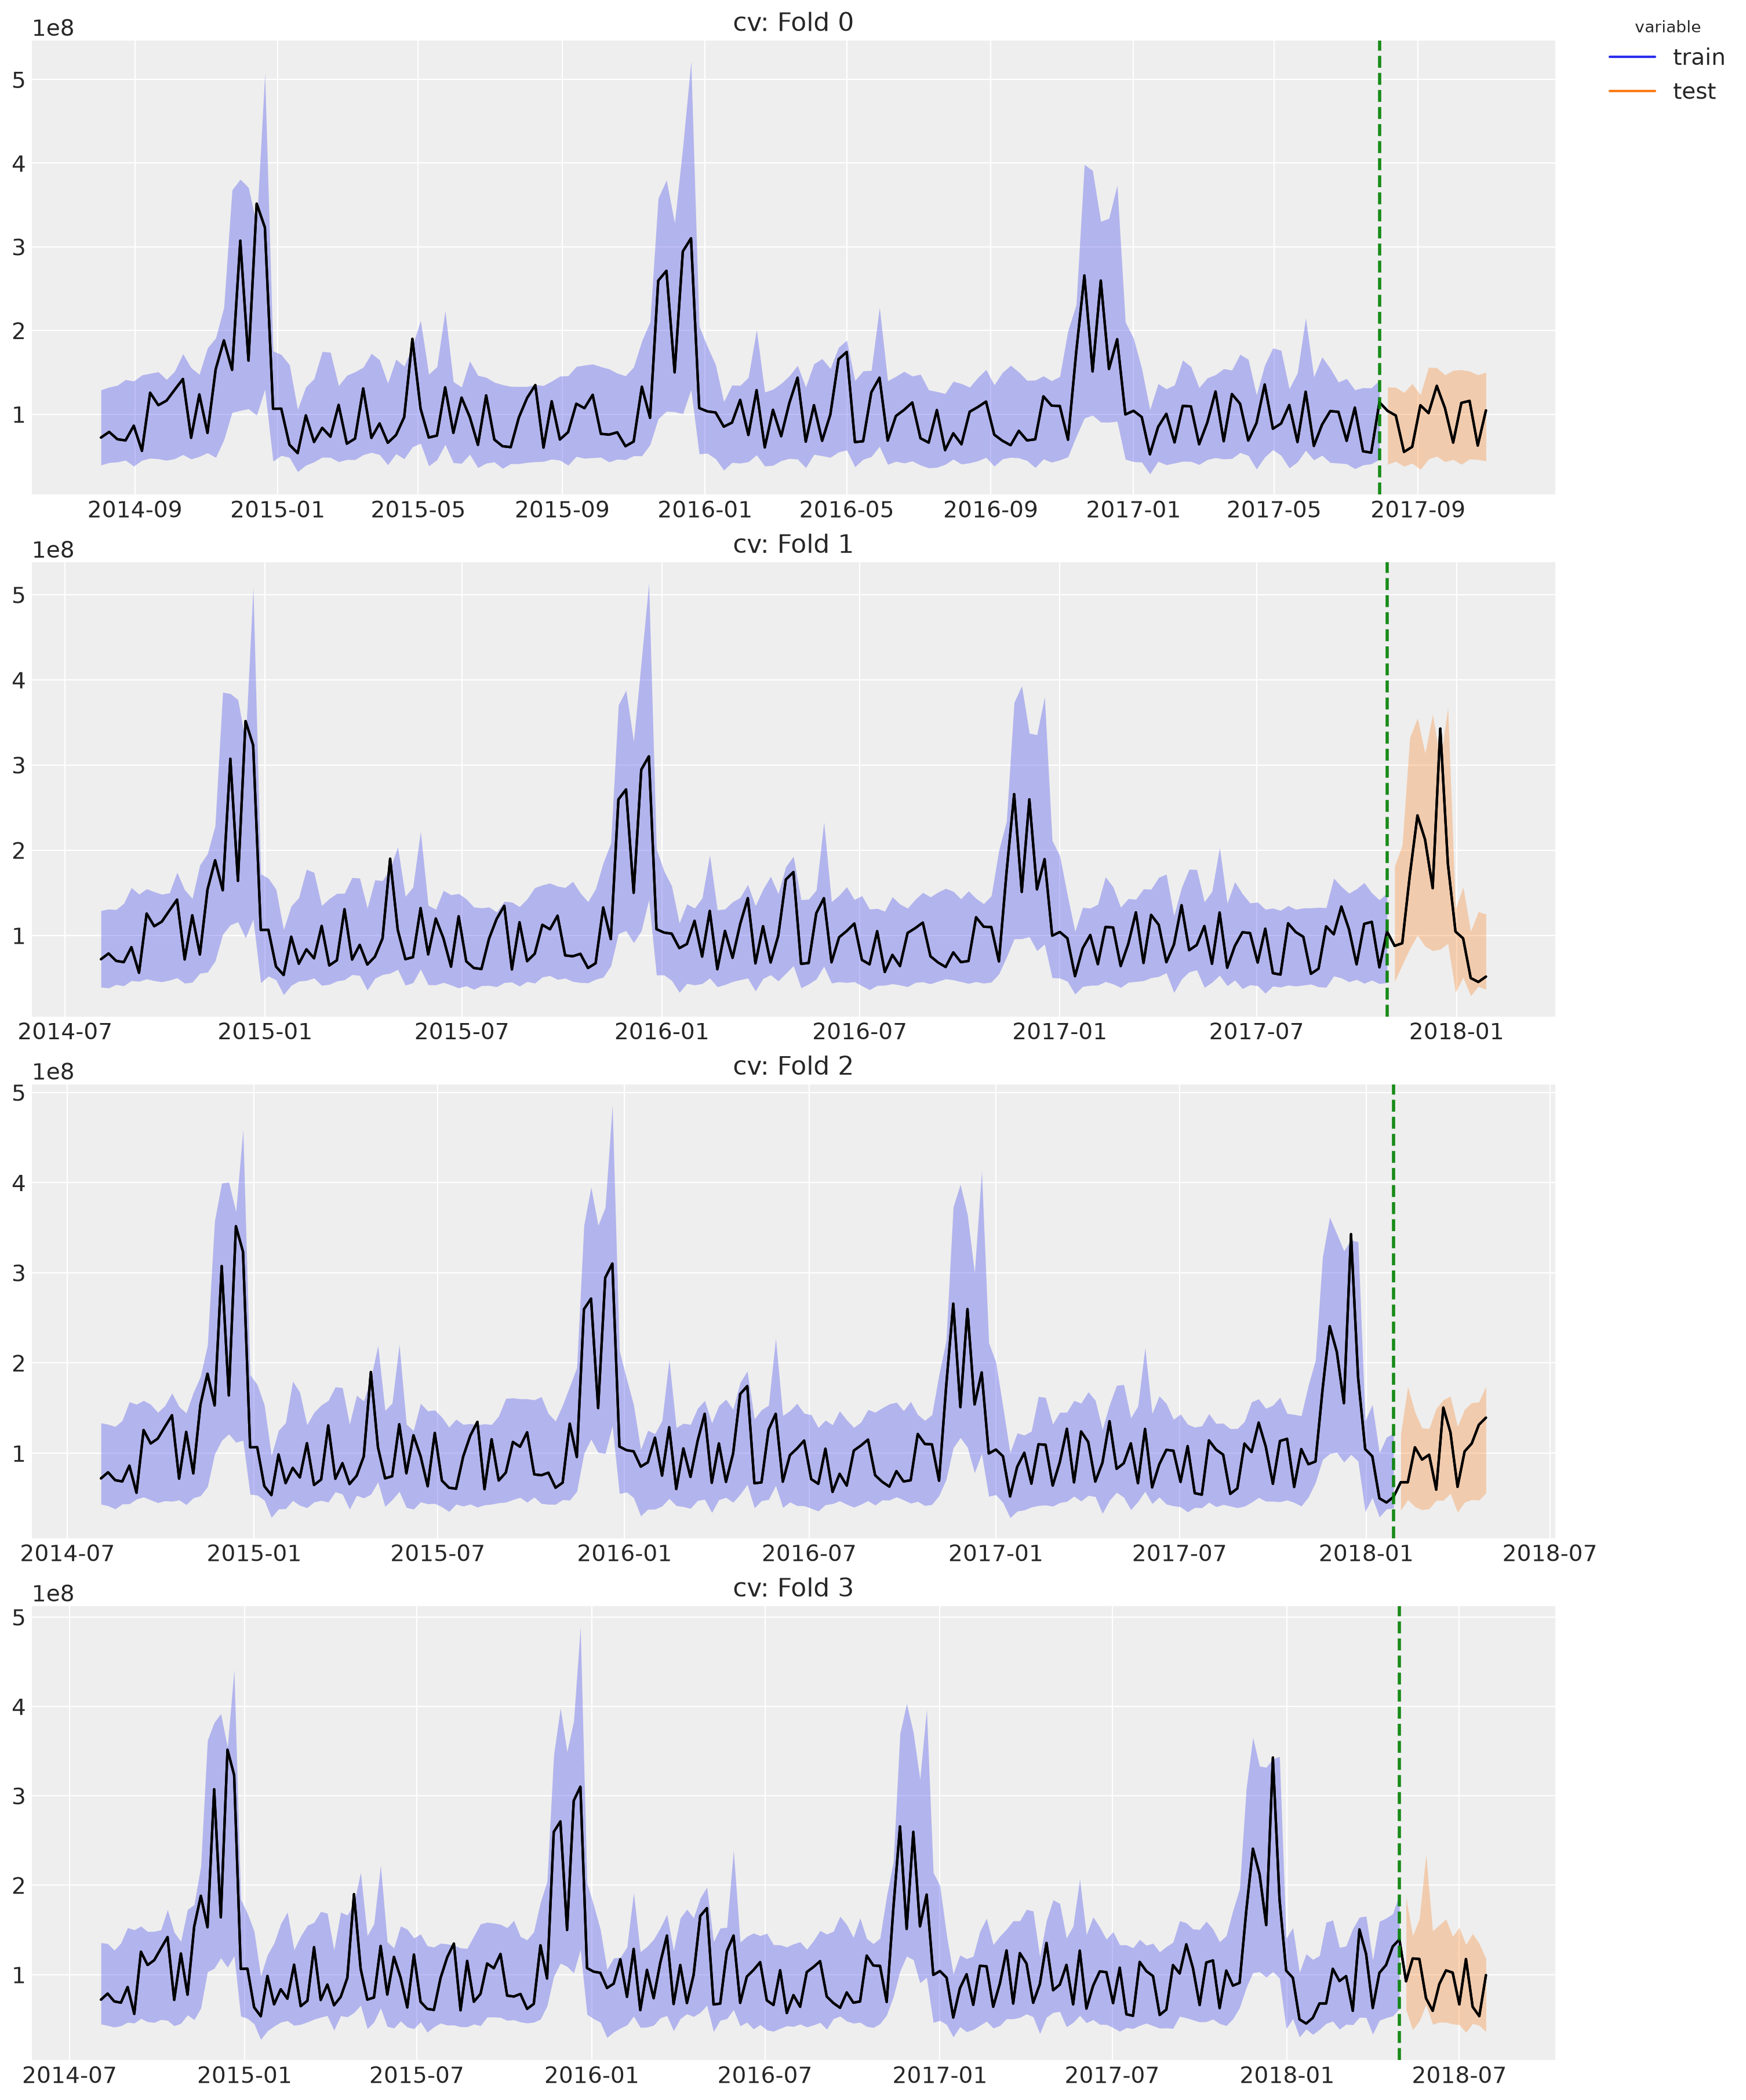

In [35]:
cv_log, cv_results_log = cv["log"]
cv_log.plot.predictions(hdi_prob=HDI_PROB, figsize=(15, 18));

The forecast bands cover the observed sales in all four held-out quarters. Fold 1, whose test window holds the 2017 holiday peak, is again the hardest, and the proportional band widens with the peak instead of keeping the training width.

### Parameter Stability

Stable posteriors across folds mean the conclusions are not an artifact of one period. The saturation betas of the log model, fold by fold:

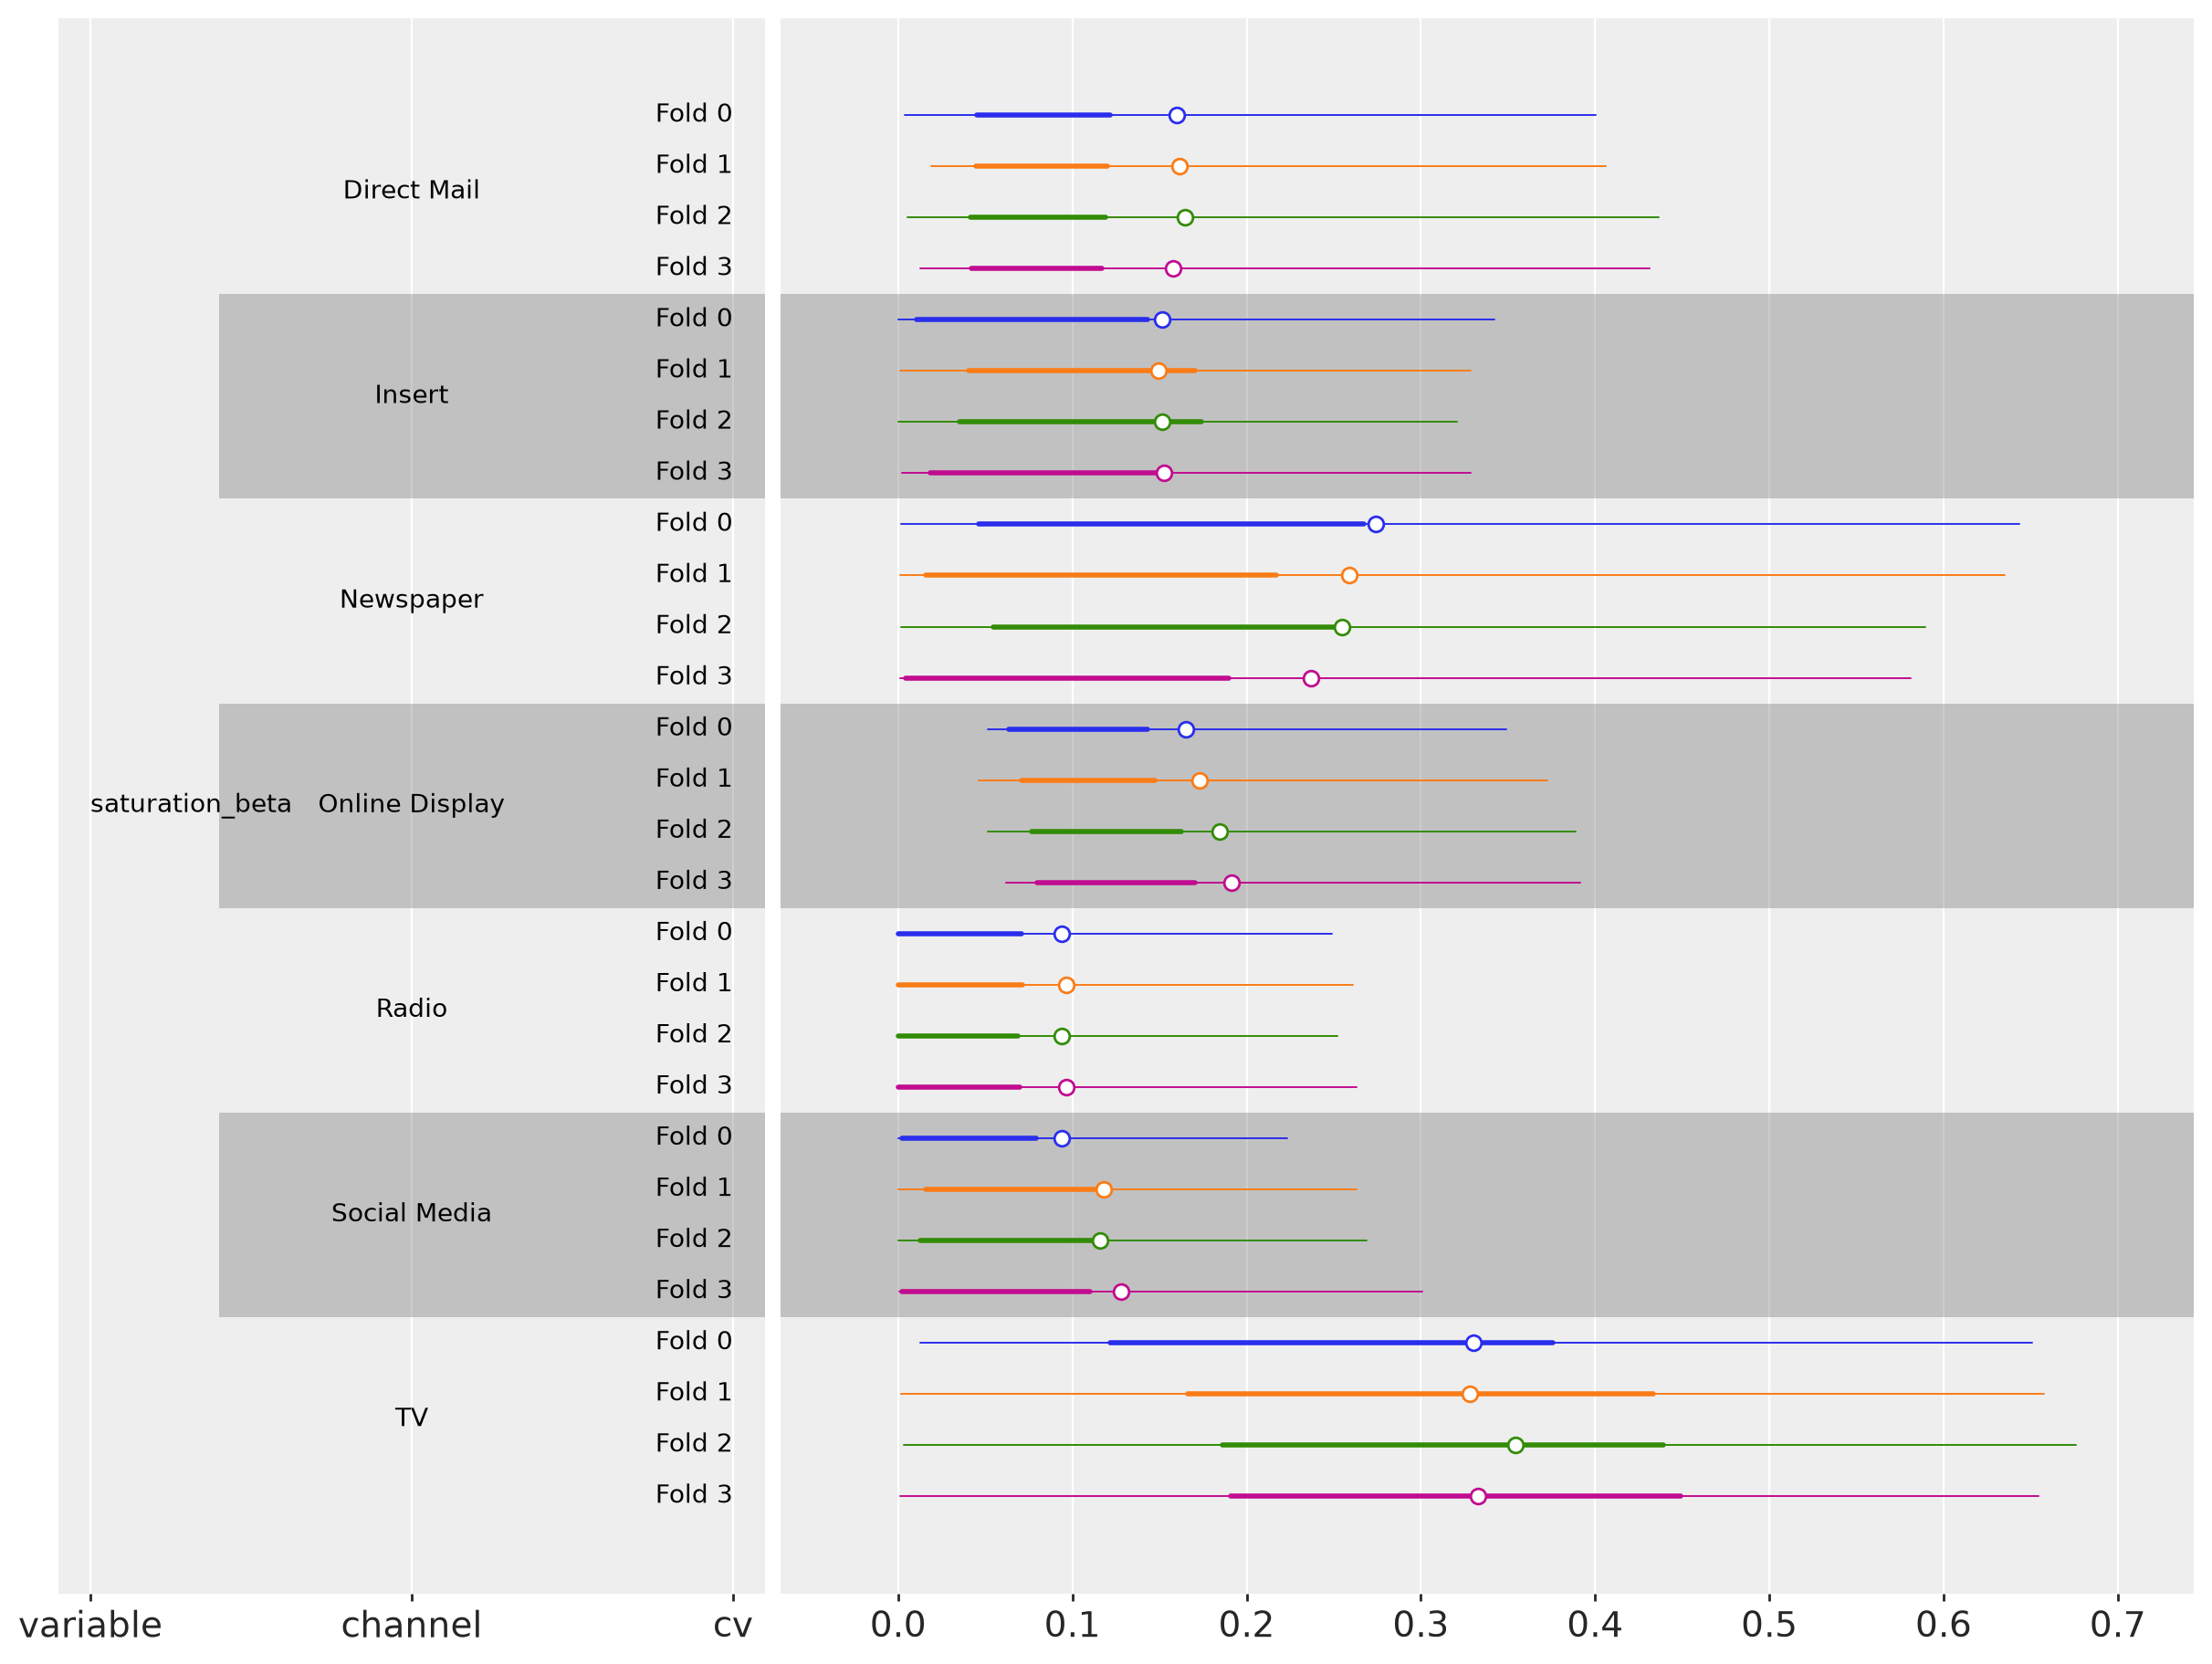

In [36]:
cv_log.plot.param_stability(
    var_names=["saturation_beta"],
    figsize=(12, 9),
    figure_kwargs={"layout": "constrained"},
);

The seven posteriors overlap from fold to fold: the means move by less than the width of any one fold's $50\%$ interval, `Newspaper` and `TV` carry the widest intervals, and the two visible drifts, `Online Display` up and `Newspaper` down as the window grows, stay well inside them. Nothing here depends on which quarter is held out.

The funnel strength is the parameter the SEM analysis relies on. The forest below shows it per fold for both links, which is the one figure that says the funnel is link-free.

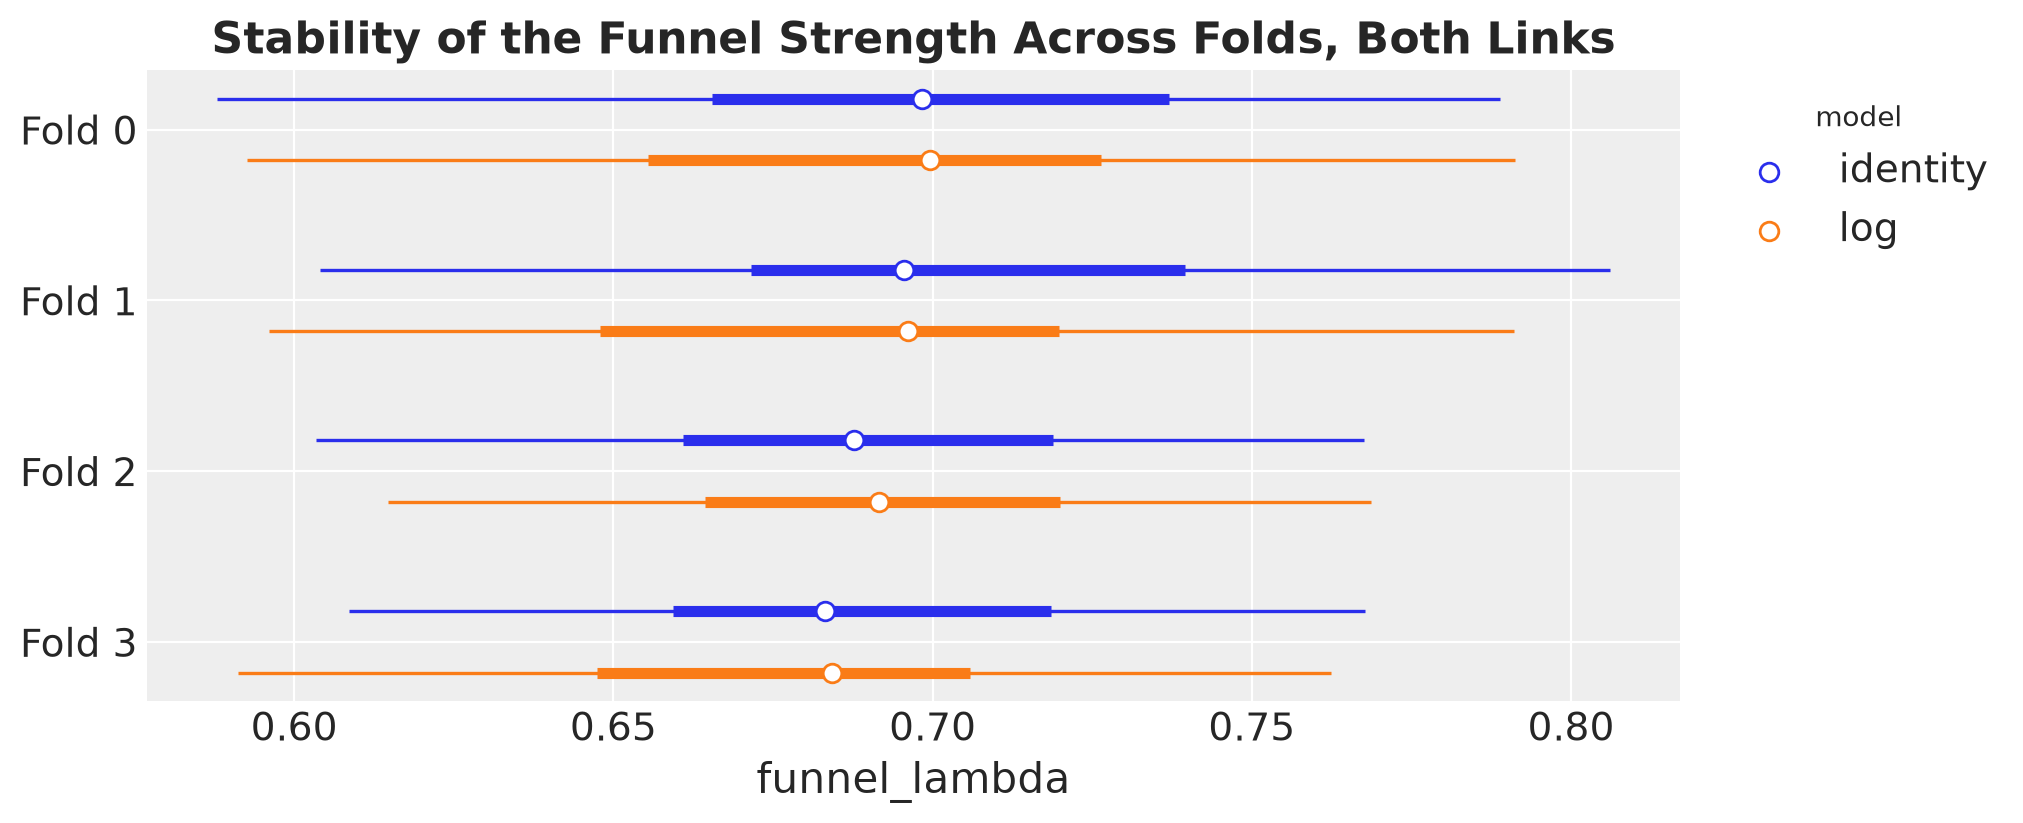

In [37]:
funnel_lambda_folds = xr.concat(
    [results["posterior"].to_dataset()["funnel_lambda"] for _, results in cv.values()],
    dim=pd.Index(list(cv), name="model"),
)

fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
forest_by_model(
    funnel_lambda_folds,
    "cv",
    ax=ax,
    xlabel="funnel_lambda",
    percent=False,
    legend_loc="outside",
)
ax.set_title(
    "Stability of the Funnel Strength Across Folds, Both Links",
    fontsize=16,
    fontweight="bold",
);

### Forecast Quality

The CRPS scores the whole forecast distribution against the observed value, lower is better, per fold and split, for both links.

In [38]:
crps_table = (
    pd.concat(
        {link: validator.summary.crps() for link, (validator, _) in cv.items()},
        names=["model"],
    )
    .reset_index(level="model")
    .pivot(index=["split", "cv"], columns="model", values="mean_crps")
    .loc[["train", "test"]]
)
crps_table["log over identity"] = crps_table["log"] / crps_table["identity"]
crps_table.round(3)

model             identity           log  log over identity
split cv                                                   
train Fold 0  1.744803e+07  1.646886e+07              0.944
      Fold 1  1.718414e+07  1.633610e+07              0.951
      Fold 2  1.798899e+07  1.674543e+07              0.931
      Fold 3  1.767850e+07  1.656851e+07              0.937
test  Fold 0  1.529745e+07  1.462383e+07              0.956
      Fold 1  2.914904e+07  2.570479e+07              0.882
      Fold 2  1.503035e+07  1.497213e+07              0.996
      Fold 3  1.774368e+07  1.667394e+07              0.940

The training scores are flat across folds for both links, and no train-test gap opens as the window grows, which is the overfitting signature this check exists to catch. The last column is the ratio of the log model's score to the identity model's: it is below one in every fold and split, by $5$ to $7\%$ on the training windows, and on the held-out quarters by one to six percent in three folds, within what a $13$-week score can resolve, and by about $12\%$ on the holiday fold, where the proportional band pays off.

**Versus the second iteration**: the `identity` rows are its cross-validation refit, and the funnel strength is stable and link-free fold by fold. The log model's held-out scores are lower in every fold, materially so only on the holiday quarter.

**Business Value**: the forecast check the stakeholders accepted last time passes for both links, and the log model passes the hardest quarter better.

## Prior Sensitivity of the ROAS

How much of each ROAS number is the data's, and how much is the prior's? Power-scaling sensitivity ([Kallioinen et al., 2024](https://link.springer.com/article/10.1007/s11222-023-10366-5)) answers this without refitting: it raises a prior or a likelihood term to a power $\alpha$ close to one, reweights the posterior draws by importance sampling, and measures how far the posterior of a target moves. A prior sensitivity above $0.05$ is flagged; a target that moves with both the prior and the likelihood (both above $0.05$) is called a potential prior-data conflict, and one that moves with the prior but not the likelihood a strong prior with a weak likelihood. See {ref}`mmm_prior_sensitivity` for the method on a simpler model.

Our targets are the seven ROAS numbers, on the mean scale as the experiments measure them. We scale the priors in blocks (the three media parameters one at a time, each block scaling all seven channels of that parameter together, then the funnel block, the baseline, the controls, the seasonality) and, in a second pass, the three evidence sources one at a time: the sales, the SEM impressions, and the two experiments. The experiments are data, not a business prior, so they belong to the likelihood and we can ask how much of a ROAS they carry. Under the log link the experiment term constrains the mean-scale ratio, so it also reads `y_sigma` through the factor $e^{\sigma^2 / 2}$; with a posterior standard deviation of $0.015$ on `y_sigma`, that pull is negligible next to the sales likelihood's.

Two cautions before the numbers. Power-scaling is a local diagnostic, a few percent of a prior's scale around the fitted model; a low value says the posterior is flat there, not that the ROAS would survive a prior of a different scale, which the narrow-prior refit of the ROAS section shows it need not. And the importance weights are Pareto-smoothed, but their diagnostic is not exposed by the summary, so the resampled quantities carry an unchecked importance-sampling error.

In [39]:
with mmm.model:
    pm.compute_log_likelihood(mmm.idata, progressbar=False)
    pm.stats.compute_log_prior(mmm.idata, progressbar=False)

# the ROAS of every draw, aligned with the log densities
mmm.idata["posterior"]["ROAS"] = roas["log"]
print("likelihood terms:", list(mmm.idata["log_likelihood"].data_vars))

prior_blocks = {
    "saturation_beta": ["saturation_beta"],
    "saturation_lam": ["saturation_lam"],
    "adstock_alpha": ["adstock_alpha"],
    "funnel": [
        "funnel_baseline",
        "funnel_lambda",
        "funnel_sigma_s",
        "adstock_uf_alpha",
        "sat_uf_lam",
        "sat_uf_beta",
        "adstock_lf_alpha",
        "sat_lf_lam",
        "sat_lf_beta",
    ],
    "baseline": ["intercept_contribution", "y_sigma"],
    "controls": ["gamma_control"],
    "seasonality": ["gamma_fourier"],
}
evidence = {
    "sales": ["y"],
    "SEM impressions": ["funnel_sem_impressions_likelihood"],
    "ROAS experiments": ["roas_calibration"],
}
all_evidence = [name for names in evidence.values() for name in names]


def roas_prior_sensitivity(idata: xr.DataTree) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Prior sensitivity of the ROAS per block, and the row-level diagnoses."""
    columns, details = {}, []
    for block, names in prior_blocks.items():
        summary = az.psense_summary(
            idata,
            var_names=["ROAS"],
            prior_var_names=names,
            likelihood_var_names=all_evidence,
        )
        columns[block] = summary["prior"]
        details.append(summary.assign(block=block))
    matrix = pd.DataFrame(columns)
    matrix.index = matrix.index.str.replace(r"ROAS\[(.*)\]", r"\1", regex=True)
    return matrix, pd.concat(details)


def roas_evidence_sensitivity(idata: xr.DataTree) -> pd.DataFrame:
    """Likelihood sensitivity of the ROAS with one evidence source scaled at a time."""
    columns = {}
    for source, names in evidence.items():
        summary = az.psense_summary(
            idata,
            var_names=["ROAS"],
            prior_var_names=["saturation_beta"],  # required by the API; unused here
            likelihood_var_names=names,
        )
        columns[source] = summary["likelihood"]
    table = pd.DataFrame(columns)
    table.index = table.index.str.replace(r"ROAS\[(.*)\]", r"\1", regex=True)
    return table

likelihood terms: ['roas_calibration', 'y', 'funnel_sem_impressions_likelihood']


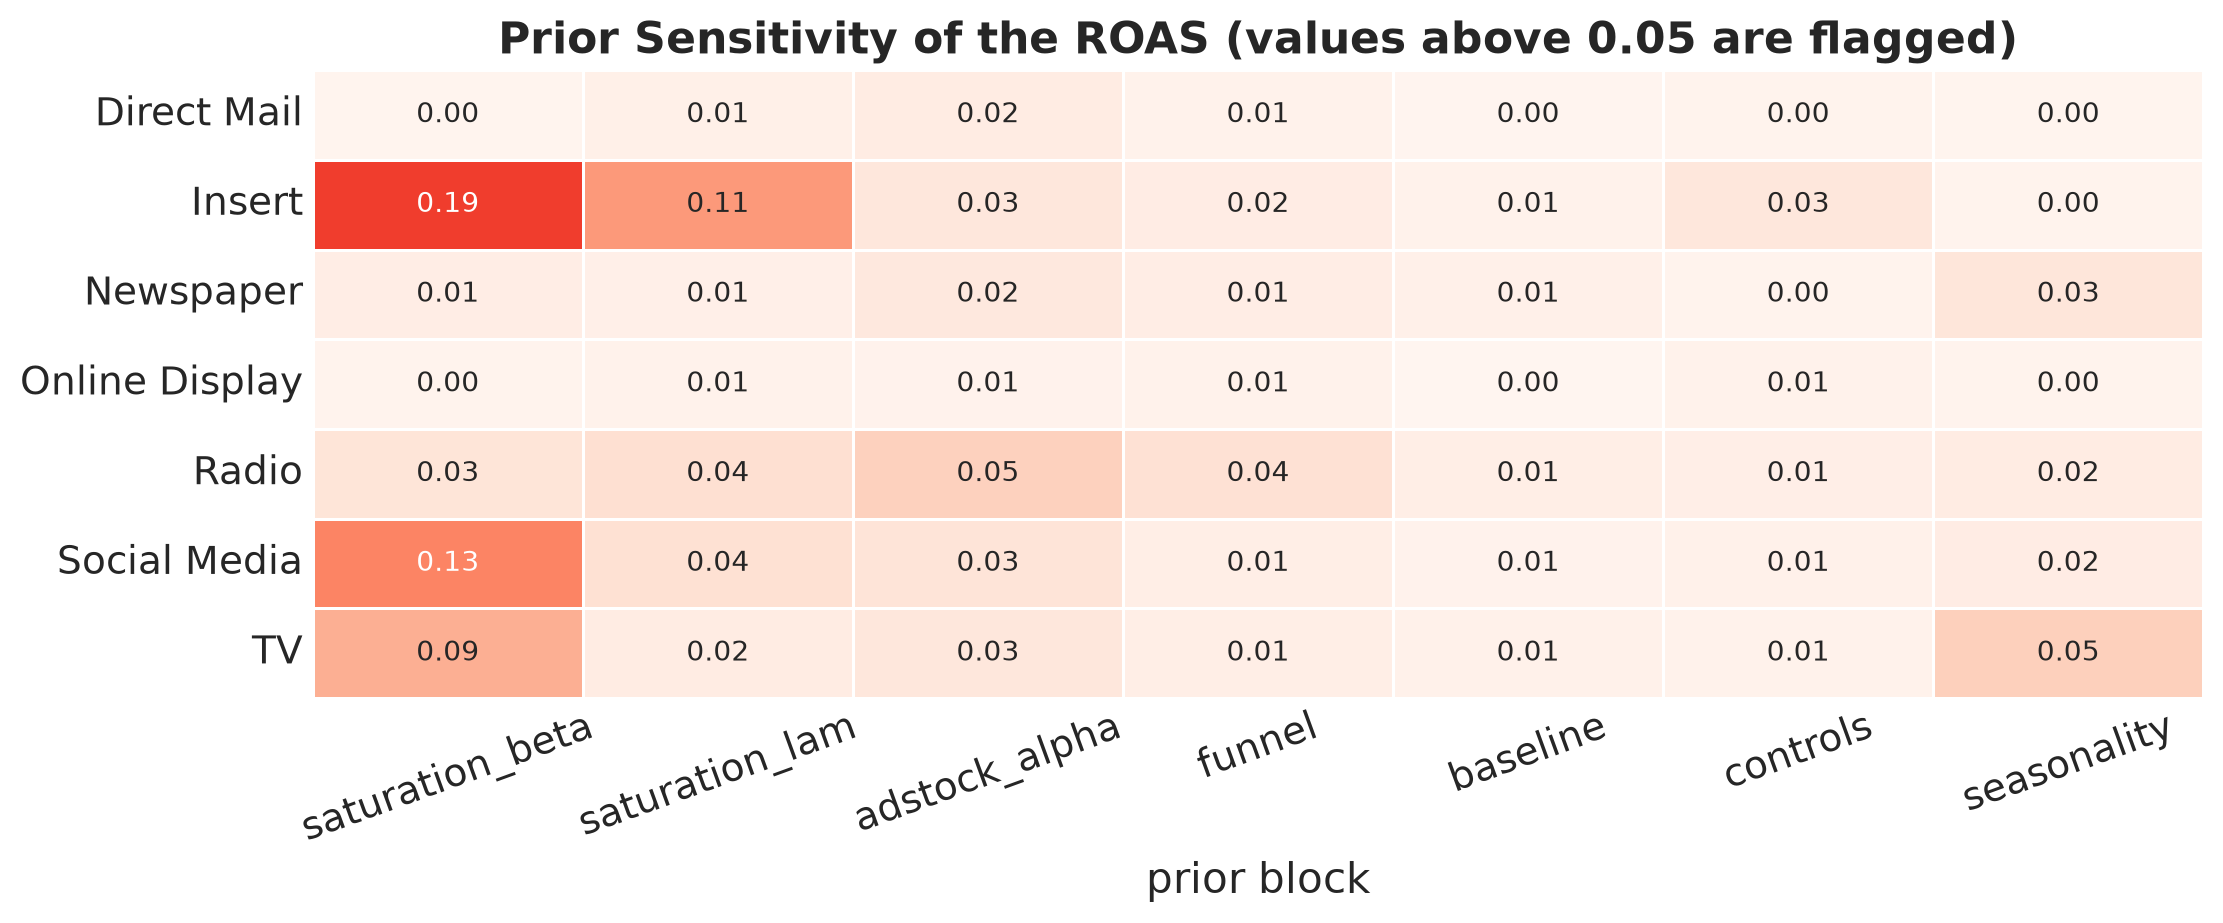

In [40]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    prior_sensitivity, prior_details = roas_prior_sensitivity(mmm.idata)
    evidence_sensitivity = roas_evidence_sensitivity(mmm.idata)

fig, ax = plt.subplots(figsize=(11, 4.5), layout="constrained")
sns.heatmap(
    prior_sensitivity,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    vmin=0,
    vmax=0.3,
    cbar=False,
    linewidths=0.5,
    ax=ax,
)
ax.set(xlabel="prior block", ylabel="")
ax.tick_params(axis="x", rotation=20)
ax.set_title(
    "Prior Sensitivity of the ROAS (values above 0.05 are flagged)",
    fontsize=16,
    fontweight="bold",
);

The two calibrated channels are insensitive to every block, and so is `Newspaper`; `Radio` touches the threshold in one cell (`adstock_alpha`, $0.05$). The flagged cells sit in the two saturation columns: `Insert` on both `saturation_beta` and `saturation_lam`, `Social Media` and `TV` on `saturation_beta`, with `TV` also at the threshold on the seasonality block. The funnel, baseline, and control priors stay below the threshold for every channel, the baseline block included, so the experiment term's weak read of `y_sigma` leaves no trace. The row-level diagnosis below names each flag of the `saturation_beta` column.

In [41]:
prior_details.query("block == 'saturation_beta'")[["prior", "likelihood", "diagnosis"]]

,prior,likelihood,diagnosis
ROAS[Direct Mail],0.003,0.108,✓
ROAS[Insert],0.186,0.140,potential prior-data conflict
ROAS[Newspaper],0.015,0.189,✓
ROAS[Online Display],0.004,0.097,✓
ROAS[Radio],0.030,0.262,✓
ROAS[Social Media],0.126,0.111,potential prior-data conflict
ROAS[TV],0.086,0.082,potential prior-data conflict


The summary calls a flag a conflict when the likelihood also moves the ROAS. The figure below shows what that looks like: it scales the `saturation_beta` block and the full likelihood for three channels, a calibrated one and two of the flagged ones, and plots the posterior mean of the ROAS against $\alpha$. The dashed lines are the fitted mean plus or minus two Monte Carlo standard errors, not a posterior interval.

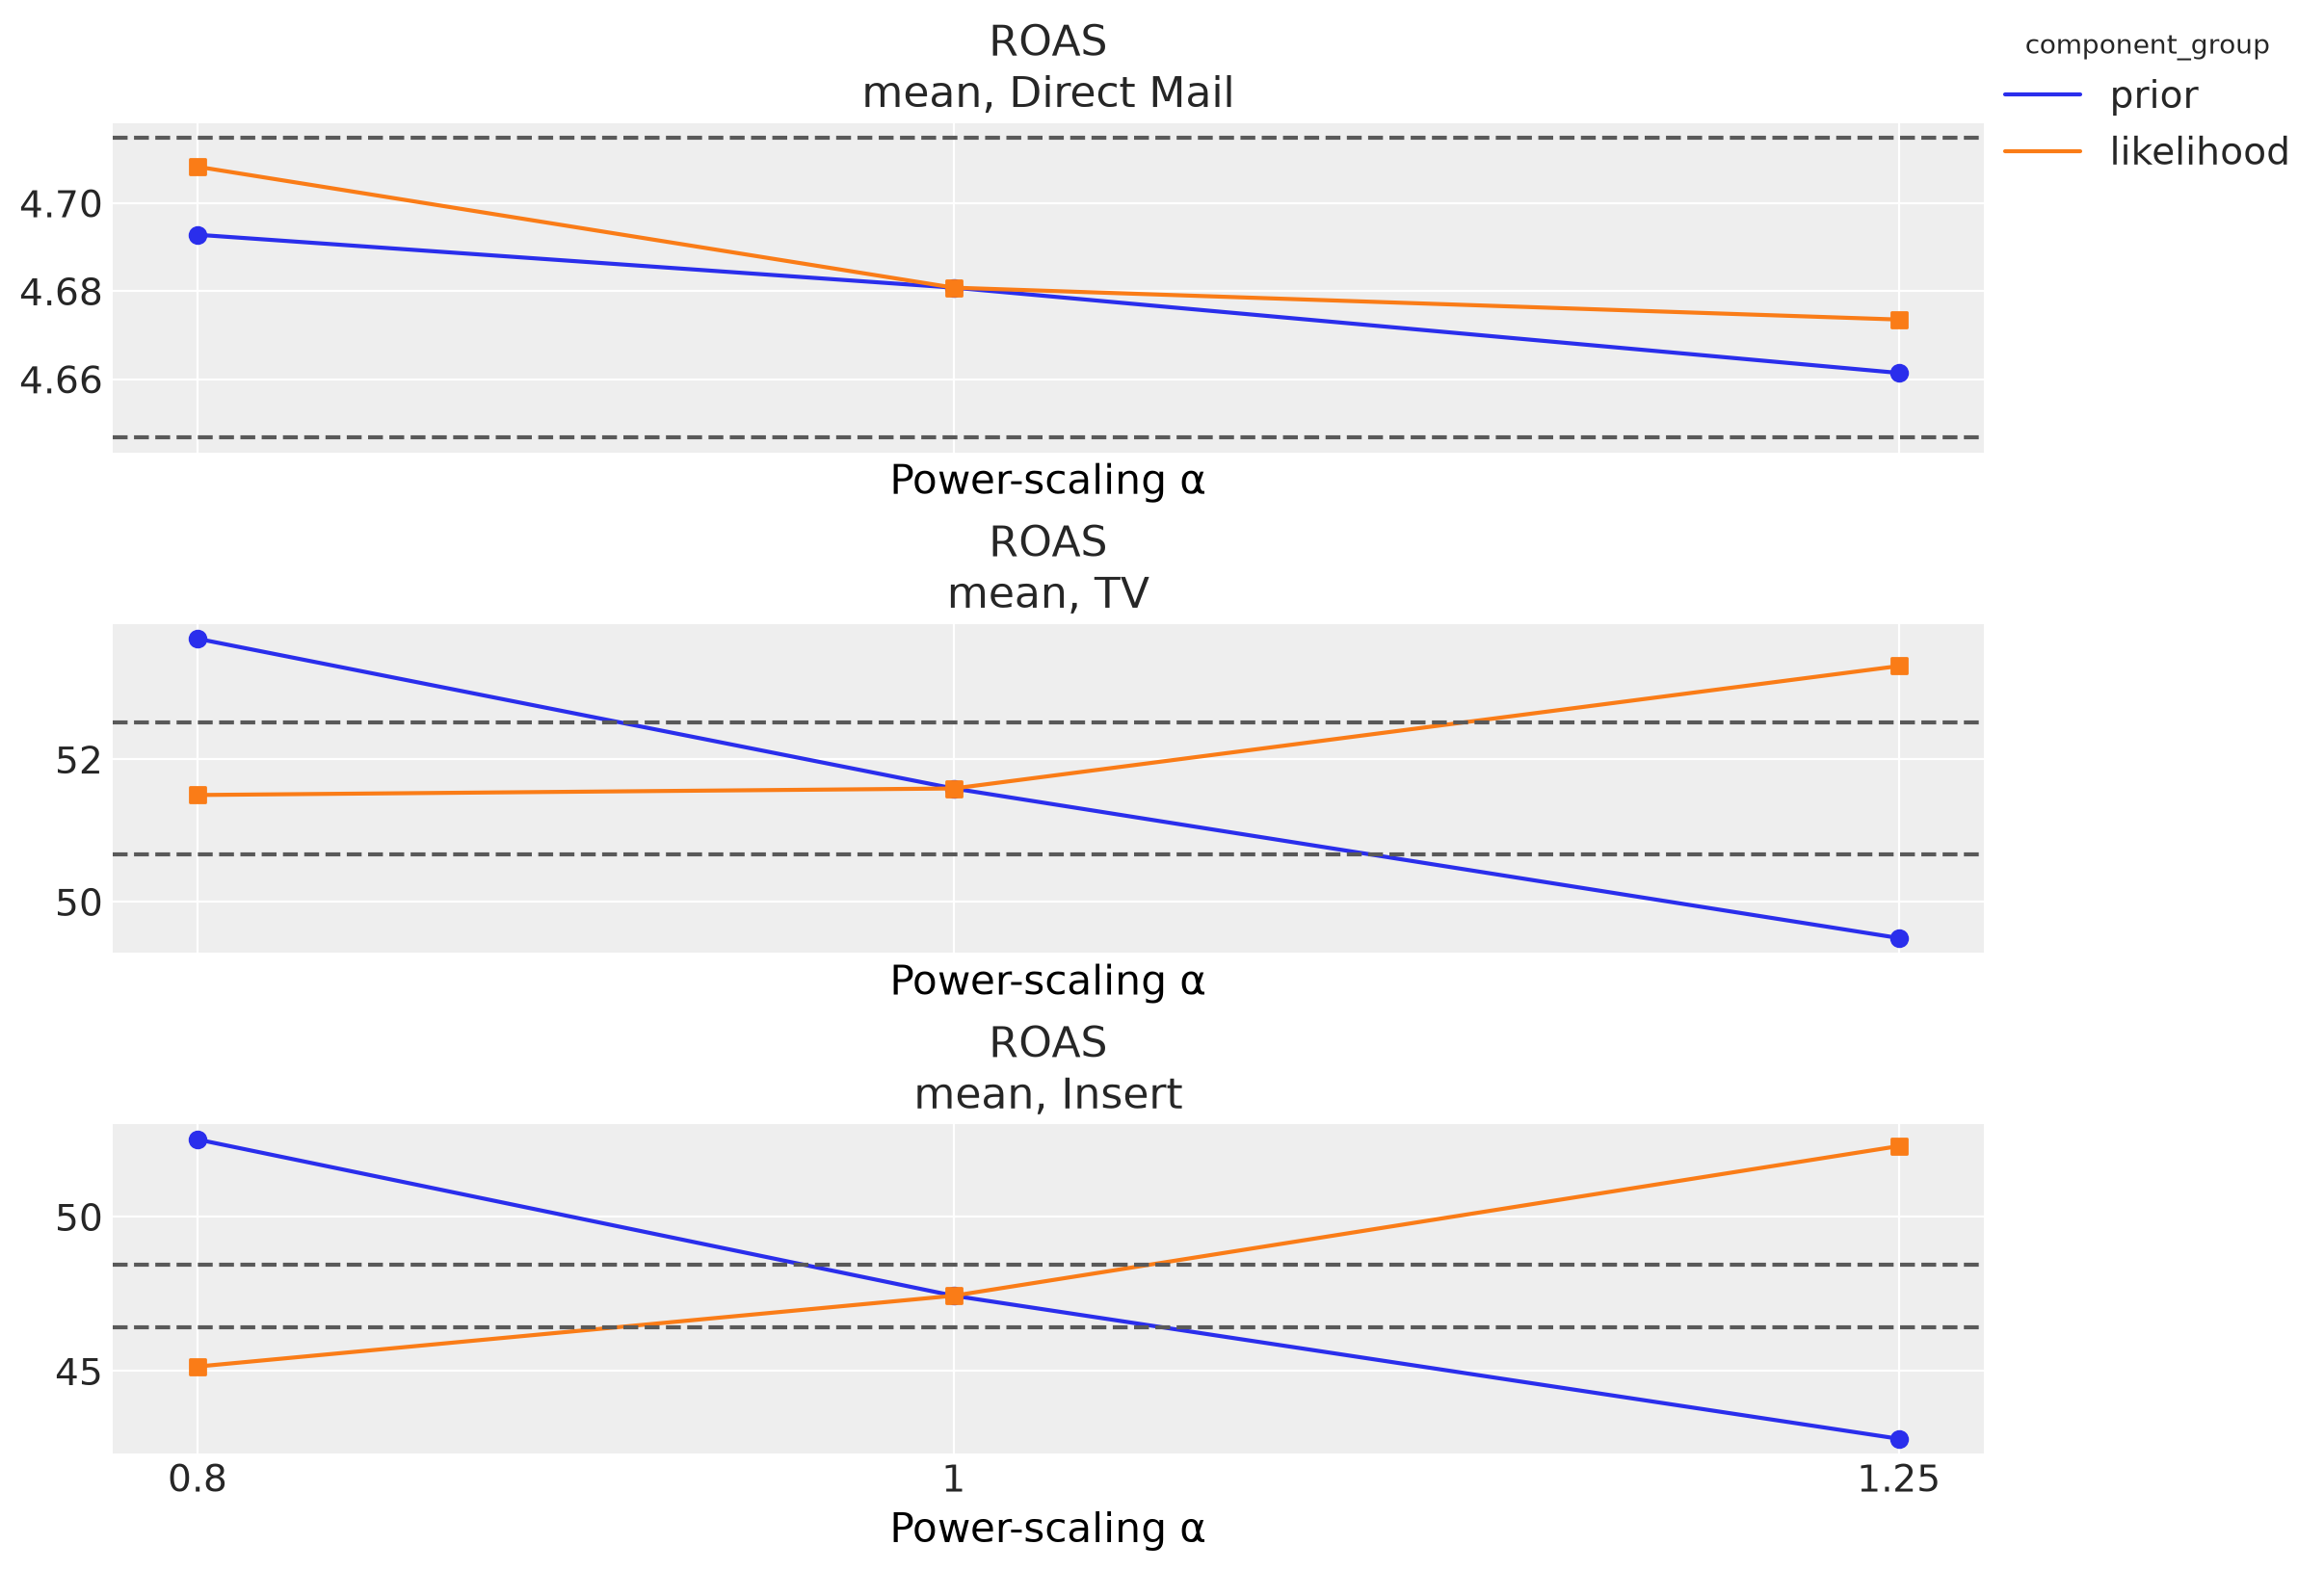

In [42]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    az.plot_psense_quantities(
        mmm.idata,
        var_names=["ROAS"],
        prior_var_names=prior_blocks["saturation_beta"],
        likelihood_var_names=all_evidence,
        coords={"channel": ["Direct Mail", "TV", "Insert"]},
        quantities=["mean"],
    )

For `Direct Mail` both lines stay within the Monte Carlo error of the fitted mean: the experiment pins its ROAS and neither the prior nor the sales move it. For `TV` and `Insert` the two lines cross in opposite directions: strengthening the spend-share prior pulls the ROAS down, strengthening the likelihood pulls it up. That is the prior-data conflict the summary flags, and it says the spend-share prior still shrinks those two lines.

Which evidence carries each ROAS? The table scales one likelihood term at a time.

In [43]:
spend_share = (X[channel_columns].sum() / X[channel_columns].sum().sum()).rename(
    "spend share"
)
evidence_sensitivity.join(spend_share).round(3)

,sales,SEM impressions,ROAS experiments,spend share
Direct Mail,0.050,0.010,0.091,0.446
Insert,0.145,0.009,0.022,0.047
Newspaper,0.177,0.009,0.010,0.150
Online Display,0.021,0.008,0.085,0.127
Radio,0.245,0.017,0.007,0.072
Social Media,0.111,0.009,0.009,0.060
TV,0.080,0.007,0.005,0.099


Three readings:

- **The calibrated channels rest on the experiments.** `Direct Mail` and `Online Display` respond to the experiment term (about $0.09$) and less to the sales (at most $0.05$).
- **The upper funnel channels rest on the sales.** `Radio` and `Newspaper` respond to the sales likelihood most of all (about $0.25$ and $0.18$), and `Radio` is the channel the SEM impressions move most, through its mediated share, though below the threshold. `TV` responds to the sales (about $0.08$) and to its `saturation_beta` prior ($0.09$), both above the threshold, which is why the summary flags it as a conflict.
- **The small direct lines rest partly on the prior.** `Insert` and `Social Media`, the two smallest spend shares, are the lines where the `saturation_beta` prior is flagged most; `Social Media` is moved only by the sales, and mildly ($0.11$).

**Versus the second iteration**: it had no such diagnostic. Its wide uncalibrated intervals were the symptom; this is the cause, channel by channel.

**Business Value**: the next experiments should go to `TV` and `Radio`, not because they are the most prior-sensitive lines but because they are the upper funnel lines. One test that also logs SEM impressions pins their direct ROAS and tests the pass-through of the synergies section at once (the second iteration's next step 2); for `TV` it also settles the flag above. `Insert` and `Social Media` are small lines ($5\%$ and $6\%$ of spend) whose ROAS a stakeholder should read as partly the prior's until an experiment says otherwise.

```{warning}
**Critical Assessment**: low sensitivity is not correctness. A ROAS can be insensitive to every prior and still be wrong if the data are confounded, as the retrospective check of {ref}`mmm_prior_sensitivity` shows. The diagnostic tells us where the data are silent, not where they are right.
```

## Budget Optimization

We plan the same quarter as the second iteration, the $13$ weeks after the last observation, with the same three choices: the weekly pot and the starting plan are the last $52$ weeks of spend, SEM joins the pot as a spend variable, and the objective is the full response `total_response_original_scale`, which prices the mediated path. See {ref}`mmm_case_study2` for the reasoning behind each choice and for the guardrails, a $\pm 50\%$ box around the historical weekly spend of each channel plus a band of the same width on SEM.

```{note}
Under the log link the response to a plan scales with the baseline of the planning window, and the window's two holiday dummies (Labor Day and Columbus Day) are zero-filled by the optimizer, as there is no argument yet to pass planned controls ([#3125](https://github.com/pymc-labs/pymc-marketing/issues/3125)). To first order, for a flat plan, the baseline factors out of the objective: it scales the level of the response, not the split. So we compare the two models on the split and on the marginal returns, and we read the absolute gains as levels that depend on the window. The two holiday factors are printed below; they nearly cancel.
```

In [44]:
pot_columns = [*channel_columns, "sem_spend"]
weekly_hist = X[pot_columns].tail(52).mean()
media_hist = weekly_hist[channel_columns]
sem_hist = float(weekly_hist["sem_spend"])
total_weekly_budget = float(weekly_hist.sum())
media_pot = float(media_hist.sum())

start_date, end_date = "2018-08-05", "2018-10-28"  # 13 weeks after the last observation
n_plan_weeks = 13
percentage_change = 0.5


def media_box_bounds(pct: float) -> xr.DataArray:
    """Per-channel weekly bounds: a plus or minus pct box around the historical plan."""
    return xr.DataArray(
        np.stack(
            [(1 - pct) * media_hist.to_numpy(), (1 + pct) * media_hist.to_numpy()],
            axis=1,
        ),
        dims=["channel", "bound"],
        coords={"channel": channel_columns, "bound": ["lower", "upper"]},
    )


def sem_band_constraints(pct: float) -> list:
    """Build the budget-sum constraint plus a plus or minus pct band on the SEM weekly level."""
    sem_lo = (1 - pct) * sem_hist
    sem_hi = (1 + pct) * sem_hist
    return [
        build_default_sum_constraint("default"),
        Constraint(
            key="sem_lower",
            constraint_type="ineq",
            constraint_fun=lambda budgets, total, opt, lo=sem_lo: (
                opt.optimization_variables.variable_slice("sem_spend").sum() - lo
            ),
        ),
        Constraint(
            key="sem_upper",
            constraint_type="ineq",
            constraint_fun=lambda budgets, total, opt, hi=sem_hi: (
                hi - opt.optimization_variables.variable_slice("sem_spend").sum()
            ),
        ),
    ]


x0 = {
    "channel_data": xr.DataArray(
        media_hist.to_numpy(), dims=["channel"], coords={"channel": channel_columns}
    ),
    "sem_spend": xr.DataArray(sem_hist),
}

window_months = X[date_column].dt.month.isin([8, 9, 10])
window_holidays = [
    col for col in control_columns if X.loc[window_months, col].sum() > 0
]
holiday_factors = np.exp(posterior["gamma_control"].sel(control=window_holidays)).mean(
    ("chain", "draw")
)
window_level = float(
    posterior["y_original_scale"]
    .mean(("chain", "draw"))[window_months.to_numpy()]
    .mean()
    / posterior["y_original_scale"].mean()
)
print(
    f"weekly budget pot: {total_weekly_budget:,.0f} (media {media_pot:,.0f} + SEM {sem_hist:,.0f})"
)
holiday_summary = ", ".join(
    f"{holiday.replace('hldy_', '')} {float(factor):.2f}"
    for holiday, factor in zip(window_holidays, holiday_factors, strict=True)
)
print(f"holiday factors in the window: {holiday_summary}")
print(
    f"fitted level of August to October weeks over the all-time level: {window_level:.2f}"
)

weekly budget pot: 2,086,890 (media 1,364,471 + SEM 722,419)
holiday factors in the window: Columbus Day 1.06, Labor Day 0.93
fitted level of August to October weeks over the all-time level: 0.85


Both models get the same optimizer: the funnel objective, the SEM lever, and the C linker (`Mode(linker="cvm")`), which the second iteration found necessary to compile the gradient of the chained adstock. The reach check of the second iteration confirms that the decision vector reaches the mediated path, so the objective prices it.

In [45]:
CVM = {"mode": Mode(linker="cvm")}


def funnel_optimizer(model: FunnelMMM) -> BudgetOptimizer:
    """Funnel-aware optimizer for the planning window, with SEM as a spend variable."""
    return model.budget_optimizer(
        start_date=start_date,
        end_date=end_date,
        response_variable="total_response_original_scale",
        spend_vars=["sem_spend"],
        constraints=sem_band_constraints(percentage_change),
        compile_kwargs=CVM,
    )


def solve(optimizer: BudgetOptimizer, pct: float = percentage_change):
    """Allocate the weekly pot within a plus or minus pct box, from the historical plan."""
    objective_at_x0 = optimizer.evaluate_plan(x0).objective
    return optimizer.allocate_budget(
        total_budget=total_weekly_budget,
        budget_bounds=media_box_bounds(pct),
        x0=x0,
        minimize_kwargs={
            "method": "SLSQP",
            "options": {"ftol": 1e-9 * abs(objective_at_x0), "maxiter": 2_000},
        },
        return_if_fail=True,
    )


optimizers = {name: funnel_optimizer(model) for name, model in models.items()}

mediated_response = optimizers["log"].extract_response_distribution(
    "funnel_effect_contribution"
)
if optimizers["log"].optimization_variables.flat not in set(
    ancestors([mediated_response])
):
    raise RuntimeError("the decision vector does not reach the mediated path")

results = {name: solve(optimizer) for name, optimizer in optimizers.items()}
for name, result in results.items():
    sem_allocation = float(result.spend_var_allocations["sem_spend"].sum())
    np.testing.assert_allclose(
        float(result.budgets.sum()) + sem_allocation, total_weekly_budget, rtol=1e-6
    )
    print(
        f"{name}: {result.scipy_result.message} after {result.scipy_result.nit} iterations, "
        f"media {float(result.budgets.sum()):,.0f} + SEM {sem_allocation:,.0f}"
    )

identity: Optimization terminated successfully after 29 iterations, media 1,480,238 + SEM 606,652
log: Optimization terminated successfully after 32 iterations, media 1,480,238 + SEM 606,652


### Marginal Returns

The gradient of the objective at the historical plan gives every spend line its marginal return. Divided by the $13$ plan weeks it is a per-dollar marginal, comparable with the average ROAS, and it is the number the reallocation runs on. The objective is on the median scale, so for the log model we divide by the median-scale average ROAS kept earlier, which puts both sides of the ratio on one scale.

In [46]:
def marginal_per_dollar(name: str) -> pd.Series:
    """Marginal response per dollar at the historical plan, media lines and SEM."""
    gradient = optimizers[name].evaluate_plan(x0).utility_gradient
    return (
        pd.concat(
            [
                gradient["channel_data"].to_series(),
                pd.Series({"sem_spend": float(gradient["sem_spend"])}),
            ]
        ).loc[pot_columns]
        / n_plan_weeks
    )


average_roas = {
    "identity": roas_summary["identity"]["mean"],
    "log": roas_log_median.mean(("chain", "draw")).to_pandas(),
}
marginal = pd.DataFrame({name: marginal_per_dollar(name) for name in models})
for name in models:
    marginal[f"{name} over average ROAS"] = marginal[name] / average_roas[name].reindex(
        marginal.index
    )
marginal.round(2).fillna("")

,identity,log,identity over average ROAS,log over average ROAS
Direct Mail,4.71,3.79,1.0,0.84
Insert,59.70,37.72,1.05,0.83
Newspaper,15.93,10.37,1.08,0.82
Online Display,23.55,18.67,0.84,0.69
Radio,33.69,21.92,0.93,0.79
Social Media,23.52,20.58,0.87,0.71
TV,48.67,39.56,1.04,0.8
sem_spend,12.03,9.73,,


Two things to read here. First, the ranking: both models put SEM above `Direct Mail` only, and below every other media line at the margin, which is why both will trim it once `Direct Mail` reaches its floor. Second, the level: under the log link every marginal sits below its average ROAS, at $0.7$ to $0.85$ of it against $0.8$ to $1.1$ under the identity link. To first order this is the window's season: August to October runs at $85\%$ of the all-time level in the fitted history (printed above), and the log model's response to a dollar scales with that level; the all-time ROAS, by contrast, is weighted towards the holiday peaks.

### The Plans

largest difference between the two plans: 0 per week


,historical (52w avg),identity plan,log plan,log vs historical,log position in band
Direct Mail,566468.87,283234.45,283234.44,-0.50,floor
Insert,49378.59,74067.88,74067.88,0.50,ceiling
Newspaper,32623.57,48935.36,48935.36,0.50,ceiling
Online Display,281533.89,422300.83,422300.83,0.50,ceiling
Radio,121968.93,182953.39,182953.39,0.50,ceiling
Social Media,175997.19,263995.79,263995.79,0.50,ceiling
TV,136499.97,204749.95,204749.96,0.50,ceiling
sem_spend,722418.76,606652.13,606652.11,-0.16,interior


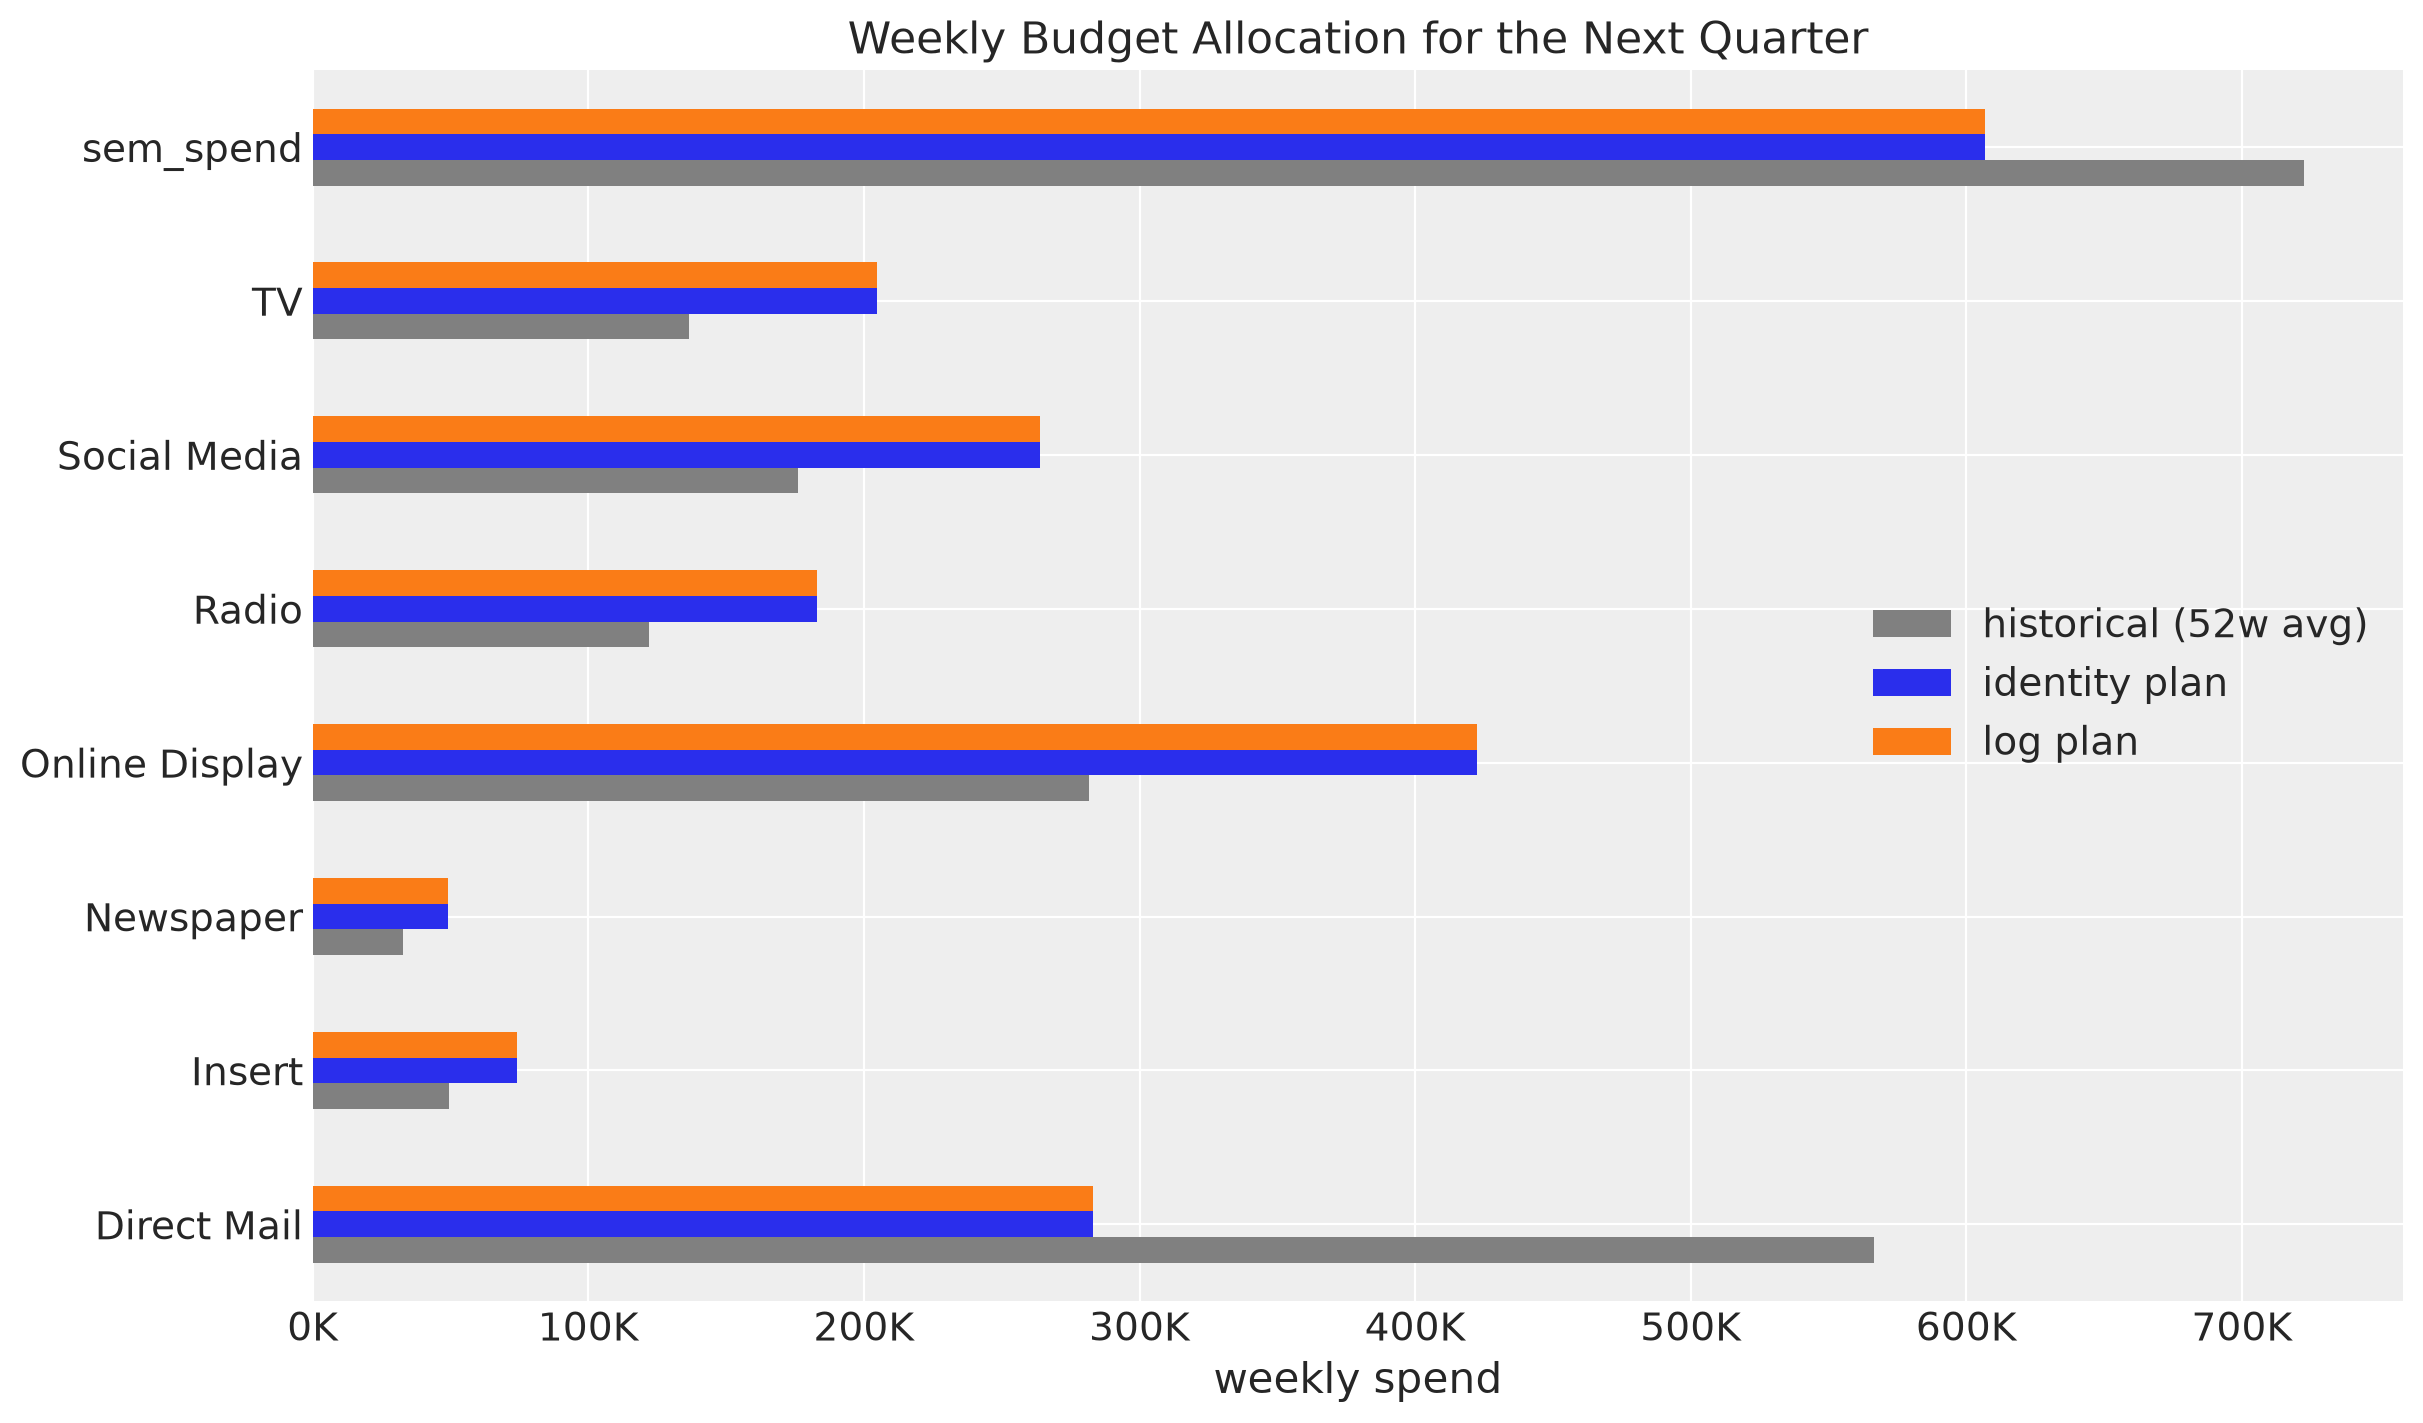

In [47]:
def allocation(result) -> pd.Series:
    """Weekly plan as a Series over the pot columns."""
    return pd.concat(
        [
            result.budgets.to_series(),
            pd.Series(
                {"sem_spend": float(result.spend_var_allocations["sem_spend"].sum())}
            ),
        ]
    ).loc[pot_columns]


def position_in_band(plan: pd.Series, pct: float) -> pd.Series:
    """Floor, ceiling, or interior, per spend line, for a plus or minus pct box."""
    reference = weekly_hist.reindex(plan.index)
    lower, upper = (1 - pct) * reference, (1 + pct) * reference
    return pd.Series(
        np.where(
            np.isclose(plan, lower, rtol=1e-4, atol=1e-2),
            "floor",
            np.where(
                np.isclose(plan, upper, rtol=1e-4, atol=1e-2), "ceiling", "interior"
            ),
        ),
        index=plan.index,
    )


allocation_df = pd.DataFrame(
    {
        "historical (52w avg)": weekly_hist,
        **{f"{name} plan": allocation(r) for name, r in results.items()},
    }
)
allocation_df["log vs historical"] = (
    allocation_df["log plan"] / allocation_df["historical (52w avg)"] - 1
)
allocation_df["log position in band"] = position_in_band(
    allocation_df["log plan"], percentage_change
)
largest_gap = float(
    (allocation_df["log plan"] - allocation_df["identity plan"]).abs().max()
)
print(f"largest difference between the two plans: {largest_gap:,.0f} per week")

fig, ax = plt.subplots(figsize=(12, 7))
allocation_df[["historical (52w avg)", "identity plan", "log plan"]].plot.barh(
    color=["gray", "C0", "C1"], ax=ax
)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v / 1e3:,.0f}K"))
ax.set(title="Weekly Budget Allocation for the Next Quarter", xlabel="weekly spend")
allocation_df.round(2)

The two models choose the same plan to the dollar: `Direct Mail` at its floor, the other six media lines at their ceilings, and SEM trimmed by $16\%$ to fund them, the corner of the second iteration. The flat-plan argument predicts this: the split follows the response curves, and the two models learned similar curves from the same data.

### Expected Response and Guardrail Sensitivity

Each model prices the plan on its own scale. We report the expected gain of the plan over the historical plan under each model's objective, and then re-solve the log model under tighter and looser boxes to see which conclusions are the response surface's and which are the box's.

In [48]:
def report_distribution(da: xr.DataArray, label: str, fmt: str = ",.0f") -> None:
    """Print the mean, the 94% HDI and P(> 0) of a scalar-per-sample quantity."""
    hdi = az.hdi(da, prob=HDI_PROB, dim=["sample"])
    low, high = float(hdi.sel(ci_bound="lower")), float(hdi.sel(ci_bound="upper"))
    print(
        f"{label}: {float(da.mean()):{fmt}} (94% HDI [{low:{fmt}}, {high:{fmt}}]), "
        f"P(> 0) = {float((da > 0).mean()):.1%}"
    )


for name, optimizer in optimizers.items():
    plan = {
        "channel_data": results[name].budgets,
        "sem_spend": results[name].spend_var_allocations["sem_spend"],
    }
    gain = optimizer.evaluate_response_distribution(
        plan, "total_response_original_scale"
    ) - optimizer.evaluate_response_distribution(x0, "total_response_original_scale")
    report_distribution(
        gain, f"{name}: expected gain of the plan over the historical plan"
    )

identity: expected gain of the plan over the historical plan: 116,243,107 (94% HDI [43,546,404, 190,035,186]), P(> 0) = 100.0%


log: expected gain of the plan over the historical plan: 90,755,668 (94% HDI [29,452,613, 154,970,050]), P(> 0) = 100.0%


In [49]:
sensitivity_rows = []
for pct in [0.2, 0.5, 1.0]:
    if pct == percentage_change:
        box_result = results["log"]
    else:
        optimizers["log"].set_constraints(sem_band_constraints(pct))
        box_result = solve(optimizers["log"], pct)
    box_plan = allocation(box_result)
    at_bound = position_in_band(box_plan[channel_columns], pct) != "interior"
    sensitivity_rows.append(
        {
            "guardrail": f"+/-{pct:.0%}",
            "Direct Mail": float(box_plan["Direct Mail"]),
            "SEM": float(box_plan["sem_spend"]),
            "SEM vs historical": float(box_plan["sem_spend"]) / sem_hist - 1,
            "media cells at a bound": int(at_bound.sum()),
            "solver success": bool(box_result.scipy_result.success),
        }
    )
pd.DataFrame(sensitivity_rows).round(2)

,guardrail,Direct Mail,SEM,SEM vs historical,media cells at a bound,solver success
0,+/-20%,453175.10,676112.11,-0.06,7,True
1,+/-50%,283234.44,606652.11,-0.16,7,True
2,+/-100%,0.00,490885.49,-0.32,7,True


The gain is a level: it depends on the window's baseline and on the zero-filled holidays, and the two models state it on different scales, so only the sign and the probability are comparable across them. The corner survives every box, and SEM is the residual the box leaves after the ceilings are funded, as in the second iteration; the size of the trim is the box's.

Which cells of this plan rest on firm ground? The `Direct Mail` floor and the `Online Display` ceiling rest on calibrated, prior-insensitive ROAS. The `Insert`, `Social Media`, and `TV` ceilings rest on the three ROAS numbers the sensitivity section flagged as partly the prior's, `TV` the least. The `Newspaper` and `Radio` ceilings rest on the sales data alone, with ROAS intervals that reach zero. The SEM trim rests on the pass-through, which is link-free, and on the conversion curve, which sits on the intercept ridge.

**Versus the second iteration**: same corner, same SEM trim; each model prices the gain on its own scale, and both put it above zero with certainty.

**Business Value**: the plan the second iteration approved stands under the multiplicative specification; fund it and score the realized quarter against both models' response distributions.

## Conclusion

This third iteration changed one argument of the second iteration's model, `link="log"`, re-expressed the priors on the log scale, and kept everything else: the funnel, the two experiments, the fold design, and the planning window. It then asked what the multiplicative form adds, and what the priors still decide.

### Key Findings

- **The fit holds under the log link.** Zero divergences, an in-sample CRPS $6\%$ below the identity model's, and sales bands that are proportional to the level, wide at the holiday peaks and narrow in the quiet weeks. The held-out CRPS is lower in every fold, materially so only on the holiday quarter (about $12\%$).
- **The funnel is link-free.** `funnel_lambda` is the second iteration's number in every fold, and the pass-through shares and exchange rates into search demand on the impressions scale are its numbers row by row.
- **The interaction synergy exists and is second order.** Every pair of spend lines interacts positively in the log model, by construction for the direct pairs and as a finding for the pool pairs, and the size is a few percent of a pair's joint lift (posterior means between about $1\%$ and $4\%$), because the per-channel lifts are small. Across all lines it is, to second order, the six-point gap between the sum of leave-one-out shares and the joint media share. The pass-through, not the product interaction, is the synergy that moves money.
- **The calibrated ROAS do not depend on the link.** On the scale an experiment measures, the two calibrated channels sit at their experiment centers under both links with the same precision. The uncalibrated means move by up to a fifth (`Insert` and `Radio` down, `TV` and `Social Media` up) inside intervals that do not separate the two links. Copying the identity-link prior width over as a number cuts three of them by half or more, which the narrow-prior refit shows.
- **The priors still decide part of the uncalibrated ROAS.** The experiments carry `Direct Mail` and `Online Display`; the sales carry `Radio` and `Newspaper`; the `saturation_beta` prior is flagged on `Insert`, `Social Media`, and, more mildly, `TV`.
- **The plan is the second iteration's corner.** `Direct Mail` at its floor, six ceilings, SEM trimmed to fund them, under every box we tested, with a gain above zero in every draw under both models.

### Model Limitations

- The sign and the symmetry of the interaction are the link's assumption; the data decide only its size.
- On the uncalibrated lines the prior's scale decides as much as the link does, and power-scaling is a local check that cannot see a prior of a different scale.
- The planning window has no planned controls, so the absolute gain is a level that depends on the zero-filled holidays and the window's baseline.
- The floor's dollar value and the SEM path's share in sales sit on the intercept ridge, now between the intercept and `sat_lf_beta`.
- One measurement series anchors the mediator, and the direction of the pass-through is assumed by the DAG, as in the second iteration.

### Recommendations

1. Run the next experiments on `TV` and `Radio`, and log SEM impressions in the treated regions: one test pins their direct ROAS and tests the pass-through.
2. Report the calibrated ROAS as numbers, the same under both links on the experiment's scale, and the uncalibrated ones as ranges across specifications, naming `Insert`, `Social Media`, and `TV` as the lines that still lean on the prior.
3. Fund the plan for one quarter with the $50\%$ guardrails, and score the realized quarter against both models' response distributions.

## Next Steps

This iteration closes the multiplicative half of the second iteration's next step 4. The rest carries forward:

1. **Price the induced SEM spend** (second iteration, step 1): demand created by upper funnel media pulls SEM spend along with it, and neither iteration nets it out.
2. **Use real experiments** (step 2): replace the imagined ranges, and extend the calibration to an upper funnel channel with the whole-model spend counterfactual as the target, since the experiment measures the direct plus the mediated effect.
3. **Score the plan** (step 3): after the quarter, score the realized $13$ weeks against both response distributions and roll the cross-validation forward one fold.
4. **Test the interaction directly**: a factorial test that varies two channels at once is the experiment that can tell a real interaction from the functional form.
5. **Planned controls and spend timing**: pass the window's holidays to the optimizer once [#3125](https://github.com/pymc-labs/pymc-marketing/issues/3125) lands, and let the log model choose when to spend within the quarter, since under the log link the baseline of each week scales the return of that week's spend.
6. **Library items**: the funnel data plumbing ([#2945](https://github.com/pymc-labs/pymc-marketing/issues/2945)), which would remove the one workaround this notebook still carries, the `FunnelMMM` subclass.
7. **Operationalize** (step 5): track the iterations with MLflow, starting from the YAML registry of the second iteration's appendix.

In [50]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor,nutpie

Last updated: Fri, 09 Oct 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.15.0

pymc_marketing: 1.1.0
pytensor      : 3.3.2
nutpie        : 0.16.11

arviz         : 1.2.0
arviz_plots   : 1.2.0
logging       : 0.5.1.2
matplotlib    : 3.11.1
numpy         : 2.4.6
pandas        : 3.0.5
pydantic      : 2.13.4
pymc          : 6.3.2
pymc_extras   : 0.15.1
pymc_marketing: 1.1.0
pytensor      : 3.3.2
seaborn       : 0.13.2
xarray        : 2026.4.0

Watermark: 2.6.0

